# Projet 2 — Prédiction de la Courbe des Taux Américaine par Machine Learning
## *Yield Curve Prediction Using Machine Learning*

---

| Champ | Détail |
|---|---|
| **Cours** | Intelligence Artificielle en Finance |
| **Enseignants** | Nicolas De Roux & Mohamed EL FAKIR |
| **Dataset** | US Treasury Yield Curve — FRED (Federal Reserve Economic Data) |
| **Période** | 1990–2024 (fréquence journalière → mensuelle) |
| **Objectif** | Prédire les facteurs de la courbe des taux (niveau, pente, courbure) par ML |
| **Langage** | Python 3.10 — Google Colab|

---

> *"Ce projet vise à prédire l'évolution de la courbe des taux américaine à partir de ses composantes structurelles — niveau, pente et courbure — en comparant des approches classiques d'économétrie, des méthodes d'ensemble (Random Forest, Gradient Boosting) et des réseaux de neurones récurrents (LSTM), dans un cadre de validation temporelle rigoureuse."*


## 1. Introduction et Motivation Économique

### 1.1 La Courbe des Taux : Baromètre Macrofinancier

La **courbe des taux** (*yield curve*) représente la relation entre le rendement des obligations souveraines et leur échéance résiduelle. Elle constitue l'un des instruments les plus informatifs en macroéconomie et en finance de marché, car elle synthétise simultanément :

- **Les anticipations de politique monétaire** : le niveau général des taux reflète les anticipations concernant la trajectoire future des taux directeurs de la Réserve Fédérale.
- **Les primes de risque de terme** (*term premium*) : les investisseurs exigent une compensation pour détenir des obligations à longue échéance, soumises au risque de taux.
- **Le cycle économique** : une **courbe inversée** (taux courts > taux longs) a historiquement précédé chaque récession américaine depuis 1960, ce qui en fait un indicateur avancé de premier plan.
- **Les anticipations d'inflation** : les taux longs intègrent les prévisions d'inflation à long terme, selon la théorie des anticipations rationnelles.

### 1.2 Décomposition Factorielle — Modèle de Nelson-Siegel (1987)

Le modèle de **Nelson et Siegel (1987)** constitue la référence académique pour paramétrer la courbe des taux en un petit nombre de facteurs latents économiquement interprétables :

$$y(\tau) = L + S \cdot \frac{1 - e^{-\lambda\tau}}{\lambda\tau} + C \cdot \left(\frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right)$$

| Facteur | Proxy empirique | Interprétation économique |
|---|---|---|
| **$L$ — Niveau (*Level*)** | Moyenne des taux ou taux 10Y | Reflète les anticipations d'inflation long terme |
| **$S$ — Pente (*Slope*)** | $y_{10Y} - y_{3M}$ ou $y_{10Y} - y_{2Y}$ | Capte le cycle économique et la politique monétaire |
| **$C$ — Courbure (*Curvature*)** | $2y_{5Y} - y_{3M} - y_{10Y}$ | Mesure le bombement intermédiaire de la courbe |

### 1.3 Pourquoi le Machine Learning ?

Les modèles économétriques classiques (ARIMA, VAR) supposent des relations linéaires et stationnaires. Or, la dynamique des taux est caractérisée par :
- Des **non-linéarités de régime** : la sensibilité aux chocs macro varie selon que l'économie est en expansion, en récession, ou en régime de taux zéro.
- Des **interactions complexes** entre maturités et variables macroéconomiques.
- Des **ruptures structurelles** (crise de 2008, COVID-19, inflation 2022) que les modèles paramétriques peinent à anticiper.

Les méthodes ML — et en particulier les modèles d'ensemble (Random Forest, Gradient Boosting) et les réseaux récurrents (LSTM) — permettent de capturer ces dynamiques sans imposer de forme fonctionnelle linéaire explicite.


## 2. Objectif du Projet et Formulation du Problème ML

### 2.1 Formulation Formelle

Nous formulons le projet comme une **tâche de régression supervisée sur séries temporelles**.

Soit $\mathbf{f}_t = (L_t, S_t, C_t)$ le vecteur des facteurs de la courbe des taux à la date $t$.

**Objectif principal** : construire un modèle $\hat{f}$ tel que :
$$\hat{\mathbf{f}}_{t+h} = \hat{f}\left(\mathbf{X}_t\right)$$

où $\mathbf{X}_t$ est le vecteur de features disponibles à la date $t$ (rendements passés, facteurs retardés, indicateurs macroéconomiques), et $h$ est l'horizon de prédiction.

**Extension** : reconstruire la courbe complète $\hat{y}_t(\tau)$ pour chaque maturité $\tau$ à partir des facteurs prédits.



### 2.2 Métriques d'Évaluation

| Métrique | Formule | Usage |
|---|---|---|
| RMSE | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Métrique principale (penalise les grandes erreurs) |
| MAE | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Interprétable en points de base |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | Part de variance expliquée |
| DA | $\frac{\text{bonnes directions}}{n}$ | Précision directionnelle (pertinence trading) |

> **Contrainte temporelle** : toute validation respecte l'ordre chronologique. Un split aléatoire introduirait un biais de lookahead (*data leakage*) en utilisant des données futures pour entraîner les modèles.


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Importation des Bibliothèques et Configuration du Notebook
# ══════════════════════════════════════════════════════════════════════════════

# Installation des packages (à décommenter si pour faire la première installation)
# !pip install pandas-datareader xgboost shap lightgbm -q

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Bibliothèques standard ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from datetime import datetime
import os, time

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── Statistiques & séries temporelles ────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.decomposition import PCA
from scipy import stats

# ── Prétraitement ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.base import clone

# ── Modèles linéaires ─────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# ── Modèles d'ensemble ────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── XGBoost ───────────────────────────────────────────────────────────────────
try:
    import xgboost as xgb
    HAS_XGB = True
    print("✓ XGBoost disponible")
except ImportError:
    HAS_XGB = False
    print("⚠ XGBoost non disponible — utilisation du GBM sklearn")

# ── Deep Learning (PyTorch) ───────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✓ PyTorch disponible — device : {DEVICE}")
except ImportError:
    HAS_TORCH = False
    print("⚠ PyTorch non disponible — section LSTM ignorée")

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
    print("✓ SHAP disponible")
except ImportError:
    HAS_SHAP = False
    print("⚠ SHAP non disponible — interprétation via feature importance uniquement")

# ── Métriques ─────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Data collection ───────────────────────────────────────────────────────────
try:
    import pandas_datareader.data as web
    HAS_PDR = True
    print("✓ pandas-datareader disponible")
except ImportError:
    HAS_PDR = False
    print("⚠ pandas-datareader non disponible — utilisation des données CSV locales")

# ══════════════════════════════════════════════════════════════════════════════
# Configuration globale
# ══════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 100
})
sns.set_palette('husl')

# ── Constantes du projet ──────────────────────────────────────────────────────
START_DATE   = '1990-01-01'
END_DATE     = '2024-12-31'
TRAIN_END    = '2018-12-31'   # Fin de la période d'entraînement
VAL_END      = '2021-12-31'   # Fin de la période de validation
HORIZON      = 1              # Horizon de prédiction (1 mois)
N_SPLITS     = 5              # Folds TimeSeriesSplit
SEQ_LEN      = 24             # Longueur de séquence LSTM (24 mois)
RANDOM_SEED  = 42

np.random.seed(RANDOM_SEED)
if HAS_TORCH:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"\n{'═'*55}")
print(f"  PROJET 2 — YIELD CURVE PREDICTION")
print(f"{'═'*55}")
print(f"  Période      : {START_DATE} → {END_DATE}")
print(f"  Train        : jusqu'au {TRAIN_END}")
print(f"  Validation   : {TRAIN_END[:4]} → {VAL_END[:4]}")
print(f"  Test         : {VAL_END[:4]} → {END_DATE[:4]}")
print(f"  Horizon      : {HORIZON} mois")
print(f"  Seed         : {RANDOM_SEED}")
print(f"{'═'*55}")


✓ XGBoost disponible
✓ PyTorch disponible — device : cuda
✓ SHAP disponible
✓ pandas-datareader disponible

═══════════════════════════════════════════════════════
  PROJET 2 — YIELD CURVE PREDICTION
═══════════════════════════════════════════════════════
  Période      : 1990-01-01 → 2024-12-31
  Train        : jusqu'au 2018-12-31
  Validation   : 2018 → 2021
  Test         : 2021 → 2024
  Horizon      : 1 mois
  Seed         : 42
═══════════════════════════════════════════════════════


## 3. Collecte et Chargement des Données

### 3.1 Sources de Données

#### Données — Courbe des taux US (FRED)

La **Federal Reserve Economic Data (FRED)** de la Banque Fédérale de Saint-Louis fournit les taux du Trésor américain à maturité constante (*Constant Maturity Treasury — CMT*) en fréquence journalière.

| Ticker FRED | Maturité | Description |
|---|---|---|
| DGS1MO | 1 mois | Treasury Constant Maturity 1-Month |
| DGS3MO | 3 mois | Treasury Constant Maturity 3-Month |
| DGS6MO | 6 mois | Treasury Constant Maturity 6-Month |
| DGS1 | 1 an | Treasury Constant Maturity 1-Year |
| DGS2 | 2 ans | Treasury Constant Maturity 2-Year |
| DGS3 | 3 ans | Treasury Constant Maturity 3-Year |
| DGS5 | 5 ans | Treasury Constant Maturity 5-Year |
| DGS7 | 7 ans | Treasury Constant Maturity 7-Year |
| DGS10 | 10 ans | Treasury Constant Maturity 10-Year |
| DGS20 | 20 ans | Treasury Constant Maturity 20-Year |
| DGS30 | 30 ans | Treasury Constant Maturity 30-Year |

#### Variables macroéconomiques (FRED)

| Ticker FRED | Variable | Fréquence |
|---|---|---|
| FEDFUNDS | Taux des Fed Funds (politique monétaire) | Mensuelle |
| CPIAUCSL | Indice des prix à la consommation (inflation) | Mensuelle |
| UNRATE | Taux de chômage | Mensuelle |
| T10YIE | Inflation anticipée à 10 ans (breakeven) | Journalière |
| VIXCLS | Indice VIX (volatilité implicite S&P 500) | Journalière |
| USREC | Indicateur de récession NBER | Mensuelle |

> **Note méthodologique** : Les données FRED contiennent des valeurs manquantes codées `.` pour les jours fériés fédéraux. Nous appliquons un rééchantillonnage mensuel (dernière valeur observée du mois) pour homogénéiser les fréquences et réduire le bruit journalier.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Téléchargement des données depuis FRED
# ══════════════════════════════════════════════════════════════════════════════

# Maturités de la courbe des taux
YIELD_TICKERS = {
    'DGS1MO': '1M',  'DGS3MO': '3M',  'DGS6MO': '6M',
    'DGS1':   '1Y',  'DGS2':   '2Y',  'DGS3':   '3Y',
    'DGS5':   '5Y',  'DGS7':   '7Y',  'DGS10':  '10Y',
    'DGS20':  '20Y', 'DGS30':  '30Y'
}

# Variables macroéconomiques
MACRO_TICKERS = {
    'FEDFUNDS': 'fed_funds',
    'CPIAUCSL': 'cpi',
    'UNRATE':   'unemployment',
    'T10YIE':   'breakeven_10y',
    'VIXCLS':   'vix',
    'USREC':    'recession'
}

MATURITIES = list(YIELD_TICKERS.values())   # ['1M', '3M', ..., '30Y']
MAT_ORDER  = ['1M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']

def download_fred_series(tickers_dict, start, end, freq='ME', agg='last'):
    """Télécharge une liste de séries FRED et les rééchantillonne à la fréquence voulue."""
    frames = []
    for ticker, col_name in tickers_dict.items():
        try:
            s = web.DataReader(ticker, 'fred', start, end).squeeze()
            s.name = col_name
            frames.append(s)
            print(f"  ✓ {ticker} ({col_name}) — {len(s.dropna())} obs.")
        except Exception as e:
            print(f"  ✗ {ticker} — erreur : {e}")

    if not frames:
        return pd.DataFrame()

    df = pd.concat(frames, axis=1)
    df = df.replace('.', np.nan).astype(float)

    if agg == 'last':
        df_monthly = df.resample(freq).last()
    else:
        df_monthly = df.resample(freq).mean()

    return df_monthly

print("─" * 55)
print("Téléchargement des rendements obligataires US (FRED)...")
print("─" * 55)

if HAS_PDR:
    yields_raw = download_fred_series(YIELD_TICKERS, START_DATE, END_DATE, freq='ME')
    print(f"\n→ Données yield curve : {yields_raw.shape[0]} mois × {yields_raw.shape[1]} maturités")
    print(f"  Période : {yields_raw.index.min().date()} → {yields_raw.index.max().date()}")

    print("─" * 55)
    print("Téléchargement des variables macroéconomiques (FRED)...")
    print("─" * 55)
    macro_raw = download_fred_series(MACRO_TICKERS, START_DATE, END_DATE, freq='ME', agg='last')
    print(f"\n→ Données macro : {macro_raw.shape[0]} mois × {macro_raw.shape[1]} variables")
else:
    # Fallback : génération de données synthétiques cohérentes
    print("⚠ pandas-datareader indisponible — simulation de données pour démonstration")
    print("  (Dans un environnement réel, utiliser : pip install pandas-datareader)")

    dates = pd.date_range(START_DATE, END_DATE, freq='ME')
    np.random.seed(RANDOM_SEED)

    # Simulation d'une courbe des taux réaliste (processus mean-reverting)
    n = len(dates)
    level = np.zeros(n); slope = np.zeros(n); curv = np.zeros(n)
    level[0] = 5.0; slope[0] = 2.0; curv[0] = 0.5
    for t in range(1, n):
        level[t] = 0.98*level[t-1] + 0.02*5.0 + np.random.normal(0, 0.15)
        slope[t] = 0.95*slope[t-1] + 0.05*1.5 + np.random.normal(0, 0.12)
        curv[t]  = 0.90*curv[t-1]  + 0.10*0.3 + np.random.normal(0, 0.08)

    # Reconstruction de la courbe depuis les facteurs simulés
    lambda_ns = 0.0609
    tau_values = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]
    yields_data = {}
    for col, tau in zip(MAT_ORDER, tau_values):
        factor_s = (1 - np.exp(-lambda_ns*tau)) / (lambda_ns*tau)
        factor_c = factor_s - np.exp(-lambda_ns*tau)
        yields_data[col] = np.clip(level + slope*factor_s + curv*factor_c, 0.01, 20.0)

    yields_raw = pd.DataFrame(yields_data, index=dates)
    yields_raw = yields_raw.rename(columns=dict(zip(MAT_ORDER, MATURITIES)))

    macro_raw = pd.DataFrame({
        'fed_funds':    np.clip(level - 1.5 + np.random.normal(0, 0.2, n), 0, 20),
        'cpi':          100 * np.cumprod(1 + np.clip(np.random.normal(0.002, 0.003, n), -0.01, 0.02)),
        'unemployment': np.clip(5 + np.random.normal(0, 1, n), 3, 15),
        'breakeven_10y':np.clip(level*0.35 + np.random.normal(0, 0.3, n), 0, 5),
        'vix':          np.abs(15 + np.random.normal(0, 5, n)),
        'recession':    (level < 1.5).astype(float)
    }, index=dates)

    print(f"✓ Données simulées : {yields_raw.shape[0]} mois × {yields_raw.shape[1]} maturités")

yields_raw.columns = MATURITIES
print("\nAperçu des données (5 premières lignes) :")
print(yields_raw.head())


───────────────────────────────────────────────────────
Téléchargement des rendements obligataires US (FRED)...
───────────────────────────────────────────────────────
  ✓ DGS1MO (1M) — 5857 obs.
  ✓ DGS3MO (3M) — 8756 obs.
  ✓ DGS6MO (6M) — 8756 obs.
  ✓ DGS1 (1Y) — 8756 obs.
  ✓ DGS2 (2Y) — 8756 obs.
  ✓ DGS3 (3Y) — 8756 obs.
  ✓ DGS5 (5Y) — 8756 obs.
  ✓ DGS7 (7Y) — 8756 obs.
  ✓ DGS10 (10Y) — 8756 obs.
  ✓ DGS20 (20Y) — 7817 obs.
  ✓ DGS30 (30Y) — 8756 obs.

→ Données yield curve : 420 mois × 11 maturités
  Période : 1990-01-31 → 2024-12-31
───────────────────────────────────────────────────────
Téléchargement des variables macroéconomiques (FRED)...
───────────────────────────────────────────────────────
  ✓ FEDFUNDS (fed_funds) — 420 obs.
  ✓ CPIAUCSL (cpi) — 420 obs.
  ✓ UNRATE (unemployment) — 420 obs.
  ✓ T10YIE (breakeven_10y) — 5504 obs.
  ✓ VIXCLS (vix) — 8834 obs.
  ✓ USREC (recession) — 420 obs.

→ Données macro : 420 mois × 6 variables

Aperçu des données (5 premières li

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Nettoyage, Alignement et Traitement des Valeurs Manquantes
# ══════════════════════════════════════════════════════════════════════════════

print("═" * 60)
print("  ANALYSE DES VALEURS MANQUANTES")
print("═" * 60)

# ── 1. Analyse des NaN dans les rendements ────────────────────────────────────
nan_summary = pd.DataFrame({
    'Total NaN': yields_raw.isna().sum(),
    'Taux NaN (%)': (yields_raw.isna().mean() * 100).round(2),
    'Première obs.': yields_raw.apply(lambda c: c.first_valid_index()),
    'Dernière obs.': yields_raw.apply(lambda c: c.last_valid_index())
})
print("\nYield curve — Valeurs manquantes par maturité :")
print(nan_summary.to_string())

# ── 2. Stratégie de gestion des NaN ──────────────────────────────────────────
# suppression des maturités problématiques ────────────────────────────────────
# trade-off : Option A = garder toutes les maturités,perdre beaucoup d’historique
#             Option B = enlever 1M et 20Y pour garder toute la data (1990–2024)


# Option B
cols_to_drop = ['1M','20Y']
yields_reduced = yields_raw.drop(columns=cols_to_drop)

print(f"\nColonnes supprimées : {cols_to_drop}")
print(f"Maturités conservées : {list(yields_reduced.columns)}")

# Interpolation légère si quelques lignes manquantes
yields_clean = yields_reduced.copy()
yields_clean = yields_clean.interpolate(method='linear', limit=3)

# Suppression des lignes restantes avec NaN
yields_clean = yields_clean.dropna()

# Restriction à la période commune (toutes maturités disponibles)
yields_clean = yields_clean.dropna()

print(f"\n→ Observations après nettoyage : {len(yields_clean)}")
print(f"  Période commune : {yields_clean.index.min().date()} → {yields_clean.index.max().date()}")
print(f"  Aucune valeur manquante : {yields_clean.isna().sum().sum() == 0}")

# ── 3. Alignement avec les données macro ─────────────────────────────────────
macro_clean = macro_raw.copy()

# Interpolation des variables macro mensuelles
macro_clean['cpi'] = macro_clean['cpi'].interpolate(method='linear')
macro_clean['unemployment'] = macro_clean['unemployment'].interpolate(method='linear')
macro_clean['fed_funds'] = macro_clean['fed_funds'].interpolate(method='linear')
macro_clean = macro_clean.ffill()
# Pas de backward-fill global pour éviter d'injecter de l'information future en début d'échantillon.

# Calcul de l'inflation YoY depuis CPI
macro_clean['inflation_yoy'] = macro_clean['cpi'].pct_change(12) * 100

# Alignement sur la période commune des yields
common_idx = yields_clean.index.intersection(macro_clean.index)
yields_clean = yields_clean.loc[common_idx]
macro_clean  = macro_clean.loc[common_idx]

print(f"\n→ Période commune yields + macro : {common_idx.min().date()} → {common_idx.max().date()}")
print(f"  Observations alignées : {len(common_idx)}")
print(f"\nVariables macro disponibles : {list(macro_clean.columns)}")


════════════════════════════════════════════════════════════
  ANALYSE DES VALEURS MANQUANTES
════════════════════════════════════════════════════════════

Yield curve — Valeurs manquantes par maturité :
     Total NaN  Taux NaN (%) Première obs. Dernière obs.
1M         138         32.86    2001-07-31    2024-12-31
3M           0          0.00    1990-01-31    2024-12-31
6M           0          0.00    1990-01-31    2024-12-31
1Y           0          0.00    1990-01-31    2024-12-31
2Y           0          0.00    1990-01-31    2024-12-31
3Y           0          0.00    1990-01-31    2024-12-31
5Y           0          0.00    1990-01-31    2024-12-31
7Y           0          0.00    1990-01-31    2024-12-31
10Y          0          0.00    1990-01-31    2024-12-31
20Y         45         10.71    1993-10-31    2024-12-31
30Y          0          0.00    1990-01-31    2024-12-31

Colonnes supprimées : ['1M', '20Y']
Maturités conservées : ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '3

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Statistiques Descriptives
# ══════════════════════════════════════════════════════════════════════════════

print("═" * 65)
print("  STATISTIQUES DESCRIPTIVES — COURBE DES TAUX US")
print("═" * 65)

desc = yields_clean.describe().T
desc['Skew'] = yields_clean.skew()
desc['Kurt'] = yields_clean.kurt()

print("\nStatistiques descriptives par maturité :")
print(desc[['mean','std','min','25%','50%','75%','max','Skew','Kurt']].round(3).to_string())

print("\n")
print("─" * 65)
print("  Matrice des corrélations (Pearson) entre maturités :")
print("─" * 65)
corr_matrix = yields_clean.corr()
print(corr_matrix.round(3).to_string())

print("\n")
print("─" * 65)
print("  Statistiques des variations mensuelles (Δ taux) :")
print("─" * 65)
delta_yields = yields_clean.diff().dropna()
print(delta_yields.describe().round(4).to_string())


═════════════════════════════════════════════════════════════════
  STATISTIQUES DESCRIPTIVES — COURBE DES TAUX US
═════════════════════════════════════════════════════════════════

Statistiques descriptives par maturité :
      mean    std   min    25%    50%    75%   max   Skew   Kurt
3M   2.747  2.296  0.00  0.210  2.405  5.012  8.07  0.256 -1.270
6M   2.867  2.316  0.03  0.388  2.505  5.092  8.44  0.236 -1.268
1Y   2.973  2.302  0.05  0.510  2.695  5.070  8.58  0.223 -1.231
2Y   3.213  2.300  0.11  0.908  3.055  5.040  8.96  0.245 -1.123
3Y   3.395  2.250  0.11  1.308  3.335  5.113  9.05  0.261 -1.041
5Y   3.741  2.142  0.21  1.760  3.710  5.432  9.04  0.285 -0.920
7Y   4.020  2.061  0.39  2.213  3.925  5.670  9.06  0.309 -0.830
10Y  4.233  1.972  0.55  2.530  4.095  5.752  9.04  0.321 -0.723
30Y  4.748  1.813  1.20  3.108  4.640  5.960  9.00  0.301 -0.679


─────────────────────────────────────────────────────────────────
  Matrice des corrélations (Pearson) entre maturités :
────

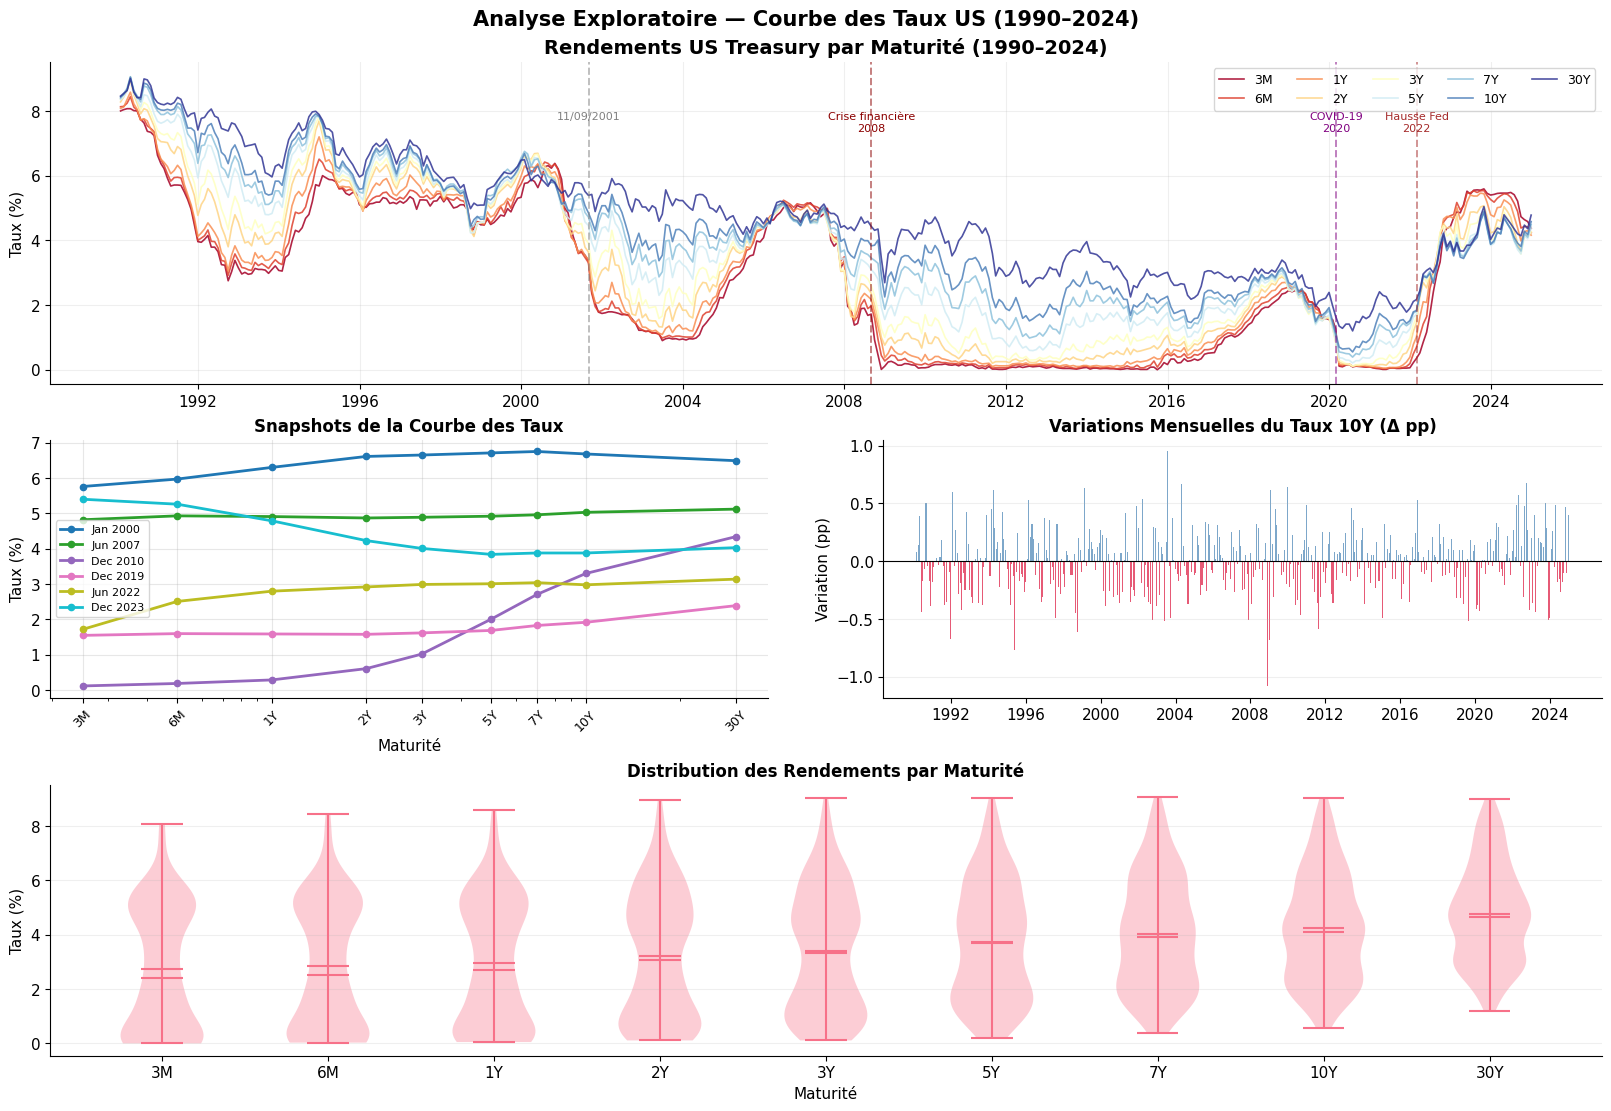

✓ Graphiques EDA sauvegardés


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — EDA : Visualisation de la Courbe des Taux dans le Temps
# ══════════════════════════════════════════════════════════════════════════════

available_maturities = list(yields_clean.columns)

tau_map = {
    '1M': 1/12, '3M': 3/12, '6M': 6/12,
    '1Y': 1, '2Y': 2, '3Y': 3, '5Y': 5,
    '7Y': 7, '10Y': 10, '20Y': 20, '30Y': 30
}
tau_numeric = [tau_map[m] for m in available_maturities]

fig = plt.figure(figsize=(16, 11), constrained_layout=True)
gs = GridSpec(3, 2, figure=fig, height_ratios=[1.25, 1.0, 1.05])

# ── Graphique 1 : Toutes les maturités dans le temps ─────────────────────────
ax1 = fig.add_subplot(gs[0, :])
palette_mats = plt.cm.RdYlBu(np.linspace(0, 1, len(available_maturities)))

for col, color in zip(available_maturities, palette_mats):
    ax1.plot(
        yields_clean.index, yields_clean[col],
        linewidth=1.2, color=color, label=col, alpha=0.85
    )

events = {
    '2001-09': ('11/09/2001', 'gray'),
    '2008-09': ('Crise financière\n2008', 'darkred'),
    '2020-03': ('COVID-19\n2020', 'purple'),
    '2022-03': ('Hausse Fed\n2022', 'brown')
}
y_text = yields_clean.max().max() * 0.88

for date_str, (label, color) in events.items():
    dt = pd.to_datetime(date_str)
    if yields_clean.index.min() <= dt <= yields_clean.index.max():
        ax1.axvline(dt, color=color, alpha=0.5, linestyle='--', linewidth=1.4)
        ax1.text(dt, y_text, label, fontsize=8, color=color, ha='center', va='top')

ax1.set_title('Rendements US Treasury par Maturité (1990–2024)', fontsize=14)
ax1.set_ylabel('Taux (%)')
ax1.set_xlabel('')
ax1.legend(loc='upper right', ncol=min(5, len(available_maturities)), fontsize=9, frameon=True)
ax1.grid(True, alpha=0.2)

# ── Graphique 2 : Snapshots de la courbe à différentes dates ─────────────────
ax2 = fig.add_subplot(gs[1, 0])
snapshot_dates = ['2000-01-31', '2007-06-30', '2010-12-31', '2019-12-31',
                  '2022-06-30', '2023-12-31']
colors_snap = plt.cm.tab10(np.linspace(0, 1, len(snapshot_dates)))

for date_str, color in zip(snapshot_dates, colors_snap):
    dt = pd.to_datetime(date_str)
    if dt in yields_clean.index:
        row = yields_clean.loc[dt, available_maturities]
        ax2.plot(
            tau_numeric, row.values, 'o-',
            color=color, label=dt.strftime('%b %Y'),
            linewidth=2, markersize=4.5
        )

ax2.set_xscale('log')
ax2.set_xticks(tau_numeric)
ax2.set_xticklabels(available_maturities, rotation=45, fontsize=9)
ax2.set_title('Snapshots de la Courbe des Taux', fontsize=12)
ax2.set_ylabel('Taux (%)')
ax2.set_xlabel('Maturité')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3)

# ── Graphique 3 : Variations mensuelles du 10Y ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
diff_10y = yields_clean['10Y'].diff().dropna()
colors_diff = ['crimson' if v < 0 else 'steelblue' for v in diff_10y]

ax3.bar(diff_10y.index, diff_10y.values, color=colors_diff, width=20, alpha=0.7)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Variations Mensuelles du Taux 10Y (Δ pp)', fontsize=12)
ax3.set_ylabel('Variation (pp)')
ax3.set_xlabel('')
ax3.grid(True, axis='y', alpha=0.2)

# ── Graphique 4 : Distribution des rendements par maturité ───────────────────
ax4 = fig.add_subplot(gs[2, :])

violin_parts = ax4.violinplot(
    [yields_clean[m].dropna().values for m in available_maturities],
    positions=range(len(available_maturities)),
    showmedians=True,
    showmeans=True
)

for body in violin_parts['bodies']:
    body.set_alpha(0.35)

ax4.set_xticks(range(len(available_maturities)))
ax4.set_xticklabels(available_maturities)
ax4.set_title('Distribution des Rendements par Maturité', fontsize=12)
ax4.set_ylabel('Taux (%)')
ax4.set_xlabel('Maturité')
ax4.grid(True, axis='y', alpha=0.2)

fig.suptitle(
    'Analyse Exploratoire — Courbe des Taux US (1990–2024)',
    fontsize=15, fontweight='bold'
)

plt.savefig('eda_yield_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print("✓ Graphiques EDA sauvegardés")

Part de variance expliquée par les 3 premières composantes : 99.9%
→ La structure factorielle est justifiée : 3 composantes capturent l'essentiel de la dynamique de la courbe des taux.


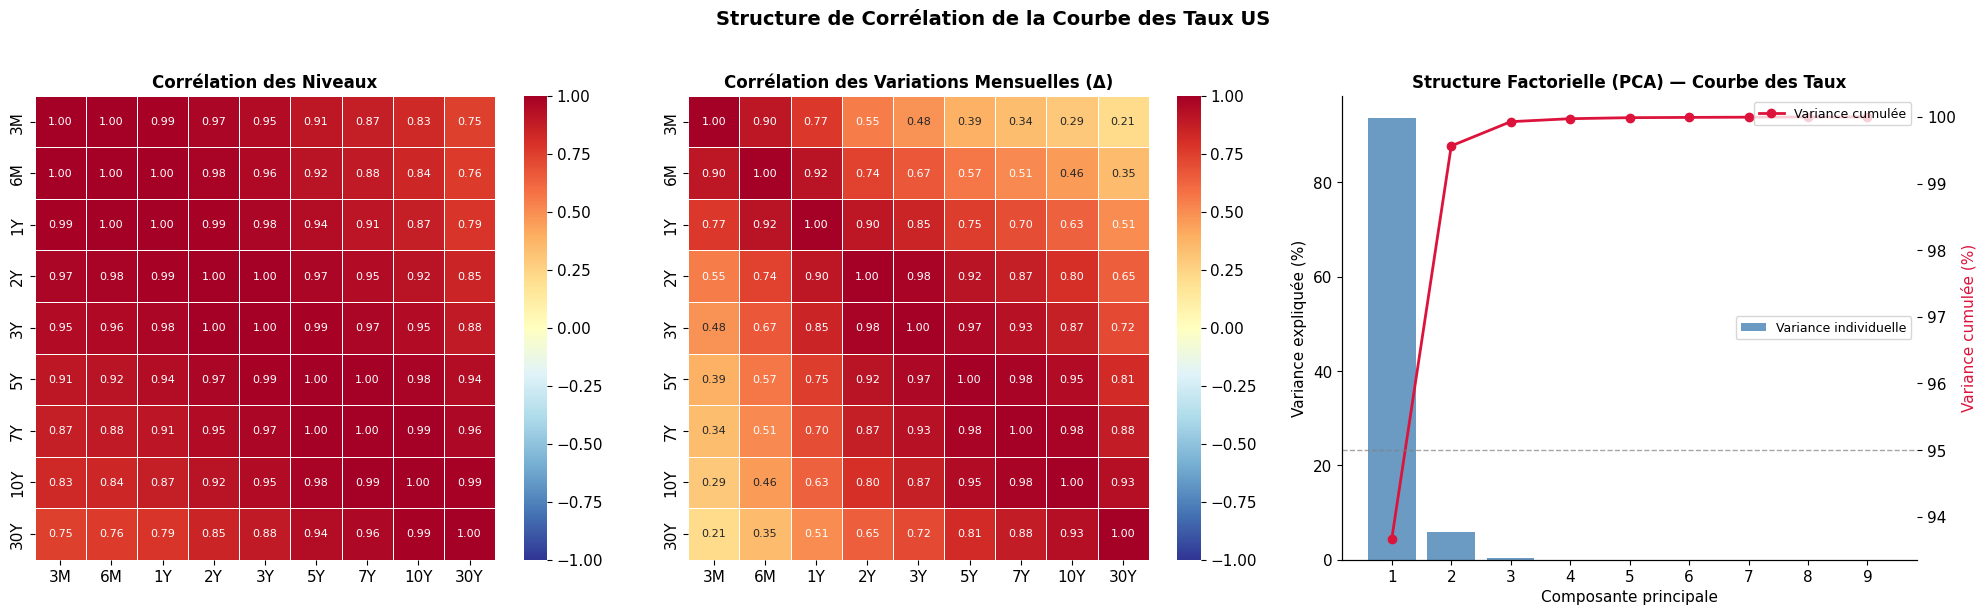

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Heatmap de Corrélation et Analyse de Structure
# ══════════════════════════════════════════════════════════════════════════════

available_maturities = list(yields_clean.columns)
n_mats = len(available_maturities)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 1. Corrélation des niveaux ────────────────────────────────────────────────
corr_levels = yields_clean.corr()

sns.heatmap(
    corr_levels,
    ax=axes[0],
    cmap='RdYlBu_r',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    xticklabels=available_maturities,
    yticklabels=available_maturities,
    annot_kws={'size': 8}
)
axes[0].set_title('Corrélation des Niveaux', fontsize=12)

# ── 2. Corrélation des variations mensuelles ──────────────────────────────────
corr_diff = yields_clean.diff().dropna().corr()

sns.heatmap(
    corr_diff,
    ax=axes[1],
    cmap='RdYlBu_r',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    xticklabels=available_maturities,
    yticklabels=available_maturities,
    annot_kws={'size': 8}
)
axes[1].set_title('Corrélation des Variations Mensuelles (Δ)', fontsize=12)

# ── 3. Variance expliquée cumulée (structure factorielle) ─────────────────────
from sklearn.decomposition import PCA as pca_tool

pca_tmp = pca_tool(n_components=n_mats)
yields_std = (yields_clean - yields_clean.mean()) / yields_clean.std()
pca_tmp.fit(yields_std.dropna())

var_exp = pca_tmp.explained_variance_ratio_ * 100
var_cum = np.cumsum(var_exp)

axes[2].bar(
    range(1, n_mats + 1),
    var_exp,
    color='steelblue',
    label='Variance individuelle',
    alpha=0.8
)

ax_twin = axes[2].twinx()
ax_twin.plot(
    range(1, n_mats + 1),
    var_cum,
    'o-',
    color='crimson',
    linewidth=2,
    label='Variance cumulée'
)
ax_twin.axhline(95, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax_twin.set_ylabel('Variance cumulée (%)', color='crimson')

axes[2].set_xlabel('Composante principale')
axes[2].set_ylabel("Variance expliquée (%)")
axes[2].set_title('Structure Factorielle (PCA) — Courbe des Taux', fontsize=12)
axes[2].set_xticks(range(1, n_mats + 1))
axes[2].legend(loc='center right', fontsize=9)
ax_twin.legend(loc='upper right', fontsize=9)

print(f"Part de variance expliquée par les 3 premières composantes : {var_cum[2]:.1f}%")
print("→ La structure factorielle est justifiée : 3 composantes capturent l'essentiel de la dynamique de la courbe des taux.")

plt.suptitle('Structure de Corrélation de la Courbe des Taux US',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

L’analyse de corrélation et la décomposition en composantes principales confirment que la courbe des taux est fortement dominée par un facteur commun de niveau, expliquant plus de 90% de la variance.

Cependant, les variations mensuelles révèlent une structure plus riche, avec une différenciation claire entre maturités courtes et longues, traduisant l’influence de facteurs économiques distincts.

Cette structure factorielle justifie l’utilisation des trois facteurs (niveau, pente, courbure), tout en expliquant la difficulté des modèles prédictifs à surpasser une simple persistance, en raison de la forte dominance du facteur niveau.

## 4. Construction des Facteurs de la Courbe des Taux

### 4.1 Approche 1 — Facteurs Économiques (Nelson-Siegel Approchés)

Les facteurs économiques sont construits directement à partir des rendements observés, selon les approximations standard de la littérature :

$$L_t = \frac{1}{n} \sum_{\tau} y_t(\tau) \quad \text{(Niveau — moyenne des maturités)}$$

$$S_t = y_t(10Y) - y_t(3M) \quad \text{(Pente — écart long/court)}$$

$$C_t = 2 \cdot y_t(5Y) - y_t(3M) - y_t(10Y) \quad \text{(Courbure — bombement intermédiaire)}$$

### 4.2 Approche 2 — ACP (Analyse en Composantes Principales)

L'ACP fournit une décomposition **empiriquement optimale** : les composantes maximisent la variance expliquée. Il est bien établi dans la littérature (Litterman & Scheinkman, 1991 ; Diebold & Li, 2006) que :
- **PC1** ≈ Niveau (loadings quasi-uniformes sur toutes les maturités)
- **PC2** ≈ Pente (loadings croissants avec la maturité)
- **PC3** ≈ Courbure (loadings en forme de cloche)


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Construction des Facteurs Économiques et PCA
# ══════════════════════════════════════════════════════════════════════════════

available_maturities = list(yields_clean.columns)

# ────────────────────────────────────────────────────────────────────────────
# APPROCHE 1 : Facteurs économiques intuitifs
# ────────────────────────────────────────────────────────────────────────────
factors_eco = pd.DataFrame(index=yields_clean.index)

# Niveau : moyenne simple des maturités disponibles
factors_eco['level'] = yields_clean.mean(axis=1)

# Pentes
factors_eco['slope_10y_3m'] = yields_clean['10Y'] - yields_clean['3M']
factors_eco['slope_10y_2y'] = yields_clean['10Y'] - yields_clean['2Y']

# Courbure
factors_eco['curvature'] = 2 * yields_clean['5Y'] - yields_clean['3M'] - yields_clean['10Y']

# Spreads additionnels
factors_eco['spread_30y_2y'] = yields_clean['30Y'] - yields_clean['2Y']
factors_eco['spread_5y_2y'] = yields_clean['5Y'] - yields_clean['2Y']
factors_eco['spread_10y_5y'] = yields_clean['10Y'] - yields_clean['5Y']

print("═" * 55)
print("  FACTEURS ÉCONOMIQUES — Statistiques")
print("═" * 55)
print(factors_eco.describe().round(3).to_string())

# ────────────────────────────────────────────────────────────────────────────
# APPROCHE 2 : ACP (Analyse en Composantes Principales)
# ────────────────────────────────────────────────────────────────────────────
scaler_pca = StandardScaler()
yields_scaled = scaler_pca.fit_transform(yields_clean)

pca_3 = PCA(n_components=3, random_state=RANDOM_SEED)
pca_scores = pca_3.fit_transform(yields_scaled)

factors_pca = pd.DataFrame(
    pca_scores,
    index=yields_clean.index,
    columns=['PC1_level', 'PC2_slope', 'PC3_curv']
)

loadings = pd.DataFrame(
    pca_3.components_.T,
    index=available_maturities,
    columns=['PC1_level', 'PC2_slope', 'PC3_curv']
)

# Correction de signe : PC1 ~ niveau
if loadings['PC1_level'].mean() < 0:
    factors_pca['PC1_level'] = -factors_pca['PC1_level']
    loadings['PC1_level'] = -loadings['PC1_level']

# PC2 ~ pente
corr_pc2_slope = np.corrcoef(
    factors_pca['PC2_slope'],
    factors_eco['slope_10y_3m']
)[0, 1]

if corr_pc2_slope < 0:
    factors_pca['PC2_slope'] = -factors_pca['PC2_slope']
    loadings['PC2_slope'] = -loadings['PC2_slope']
    corr_pc2_slope = -corr_pc2_slope

# PC3 ~ courbure
corr_pc3_curv = np.corrcoef(
    factors_pca['PC3_curv'],
    factors_eco['curvature']
)[0, 1]

if corr_pc3_curv < 0:
    factors_pca['PC3_curv'] = -factors_pca['PC3_curv']
    loadings['PC3_curv'] = -loadings['PC3_curv']
    corr_pc3_curv = -corr_pc3_curv

print(f"\n{'═'*55}")
print("  ACP — Variance expliquée")
print(f"{'═'*55}")
for i, (ev, cv) in enumerate(zip(
    pca_3.explained_variance_ratio_ * 100,
    np.cumsum(pca_3.explained_variance_ratio_) * 100
)):
    print(f"  PC{i+1} : {ev:.1f}%  (cumulé : {cv:.1f}%)")

print(f"\n  Total 3 composantes : {pca_3.explained_variance_ratio_.sum() * 100:.1f}%")
print(f"\nCorr(PC2, Pente 10Y-3M) = {corr_pc2_slope:.3f}")
print(f"Corr(PC3, Courbure eco) = {corr_pc3_curv:.3f}")

═══════════════════════════════════════════════════════
  FACTEURS ÉCONOMIQUES — Statistiques
═══════════════════════════════════════════════════════
         level  slope_10y_3m  slope_10y_2y  curvature  spread_30y_2y  spread_5y_2y  spread_10y_5y
count  420.000       420.000       420.000    420.000        420.000       420.000        420.000
mean     3.549         1.486         1.020      0.502          1.535         0.528          0.492
std      2.094         1.275         0.923      0.796          1.235         0.537          0.423
min      0.319        -1.880        -1.060     -1.700         -1.020        -0.740         -0.330
25%      1.592         0.572         0.220     -0.052          0.518         0.100          0.137
50%      3.483         1.520         0.960      0.530          1.425         0.440          0.410
75%      5.147         2.510         1.850      0.980          2.630         0.980          0.820
max      8.804         3.820         2.840      2.610          4.0

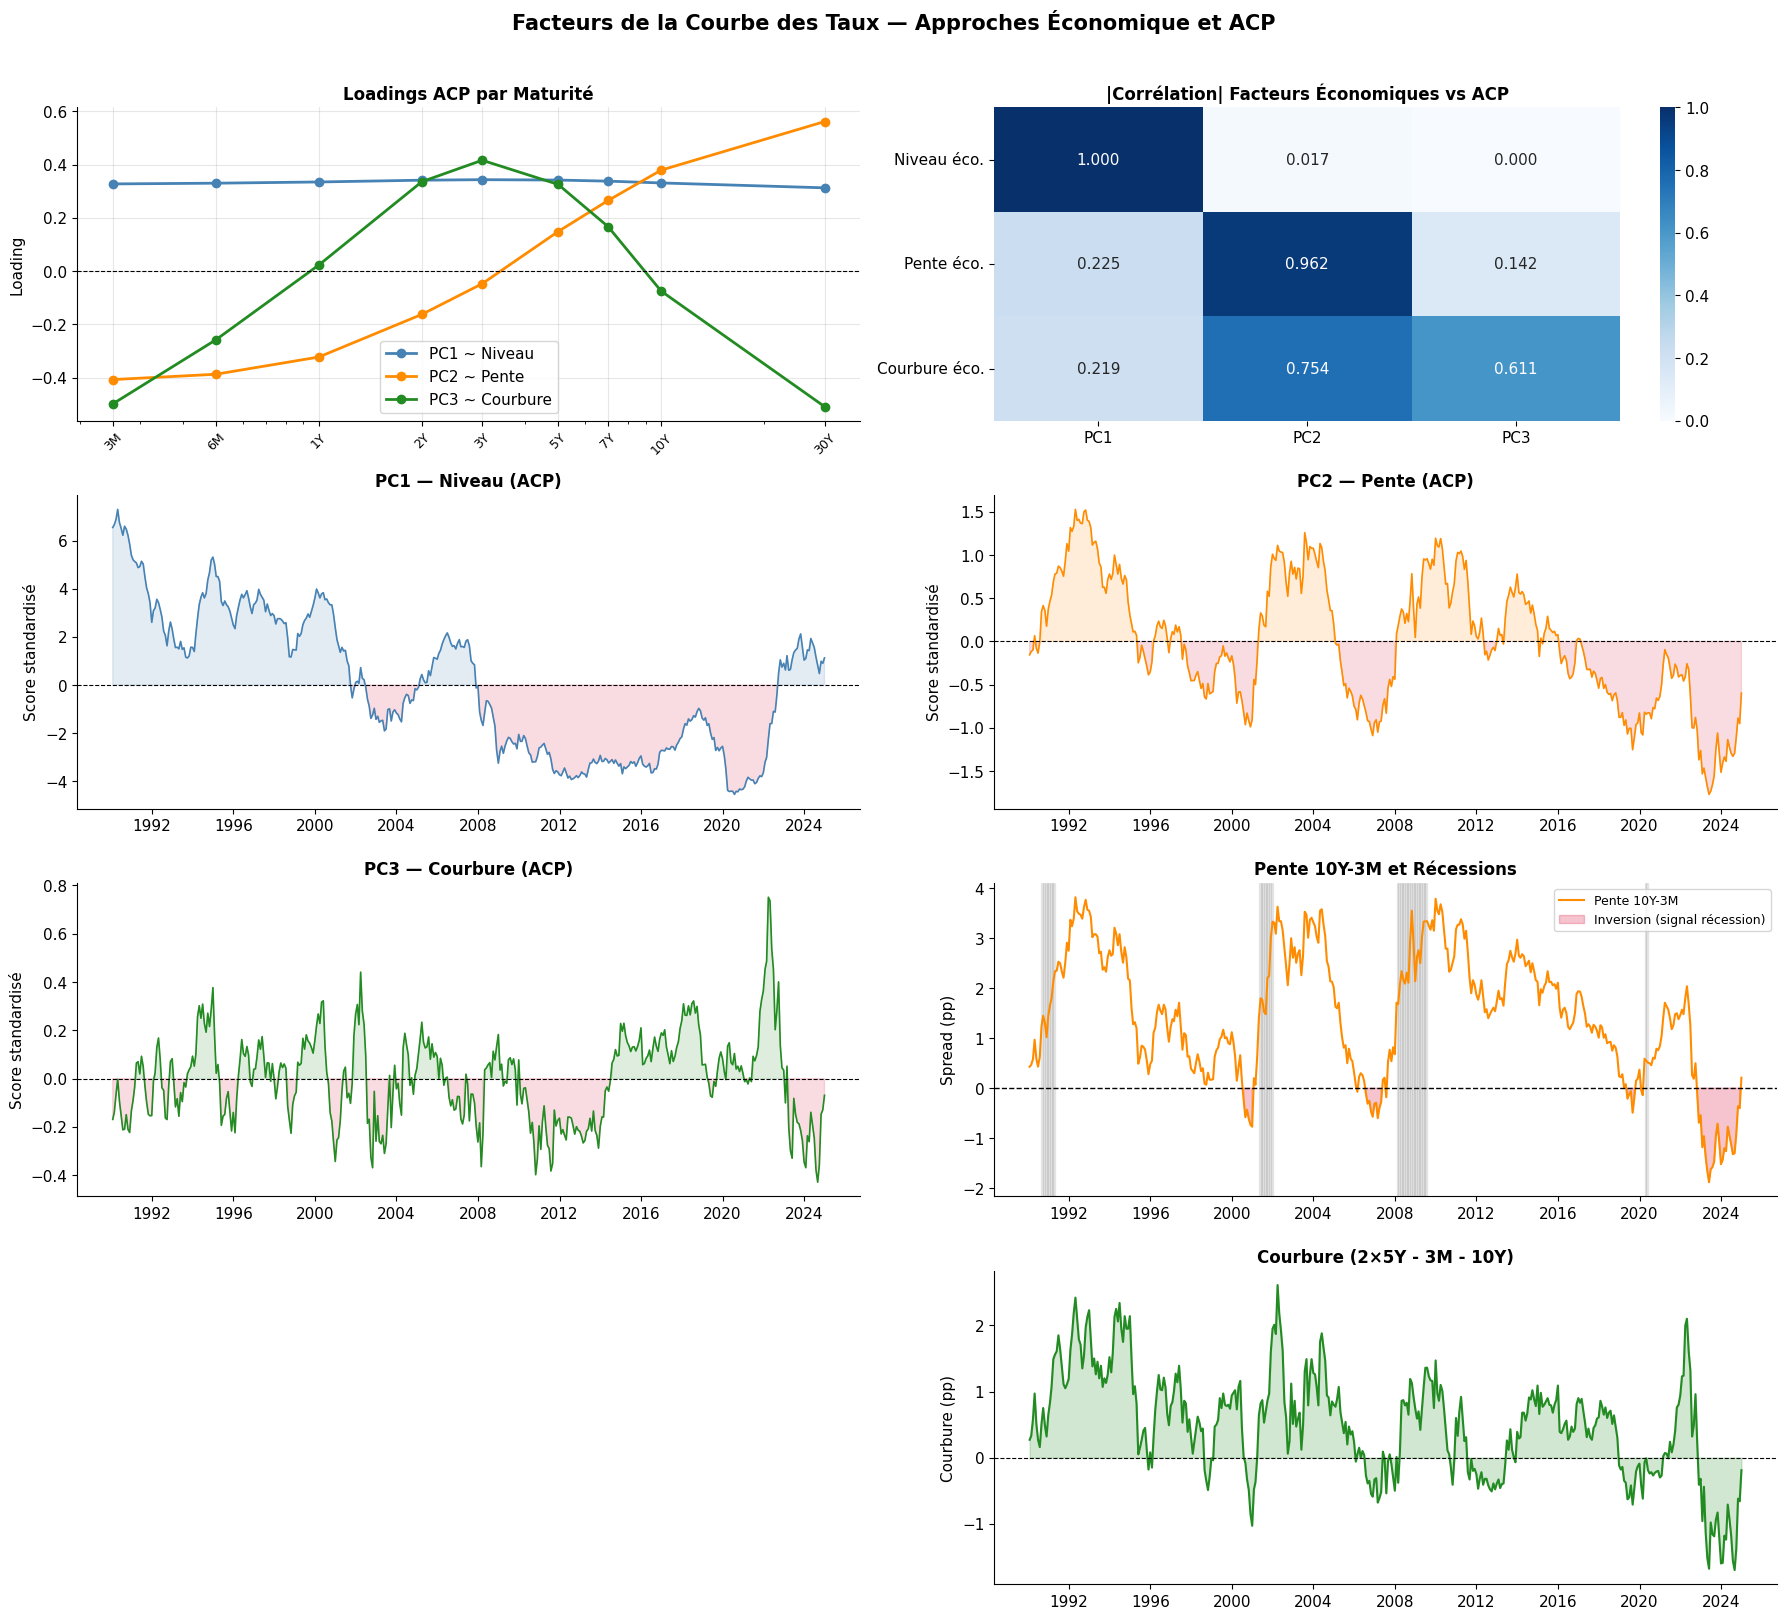


→ Facteurs cibles retenus pour la modélisation : ['level', 'slope_10y_3m', 'curvature']
  (Les facteurs économiques sont préférés pour leur interprétabilité directe)


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — Visualisation des Facteurs et Comparaison Eco vs PCA
# ══════════════════════════════════════════════════════════════════════════════

available_maturities = list(yields_clean.columns)

tau_map = {
    '1M': 1/12, '3M': 3/12, '6M': 6/12,
    '1Y': 1, '2Y': 2, '3Y': 3, '5Y': 5,
    '7Y': 7, '10Y': 10, '20Y': 20, '30Y': 30
}
tau_num = [tau_map[m] for m in available_maturities]

fig, axes = plt.subplots(4, 2, figsize=(18, 16))

# ── Loadings ACP ──────────────────────────────────────────────────────────────
ax = axes[0, 0]
for col, color, label in zip(
    ['PC1_level', 'PC2_slope', 'PC3_curv'],
    ['steelblue', 'darkorange', 'forestgreen'],
    ['PC1 ~ Niveau', 'PC2 ~ Pente', 'PC3 ~ Courbure']
):
    ax.plot(
        tau_num, loadings.loc[available_maturities, col],
        'o-', color=color, label=label,
        linewidth=2, markersize=6
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xscale('log')
ax.set_xticks(tau_num)
ax.set_xticklabels(available_maturities, rotation=45, fontsize=9)
ax.set_title('Loadings ACP par Maturité', fontsize=12)
ax.set_ylabel('Loading')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Comparaison Eco vs PCA ────────────────────────────────────────────────────
ax_comp = axes[0, 1]

from sklearn.preprocessing import StandardScaler as SS
ss = SS()

eco_std = ss.fit_transform(factors_eco[['level', 'slope_10y_3m', 'curvature']])
pca_std = ss.fit_transform(factors_pca[['PC1_level', 'PC2_slope', 'PC3_curv']])

corr_cross = np.abs(np.corrcoef(eco_std.T, pca_std.T)[:3, 3:])

sns.heatmap(
    corr_cross,
    ax=ax_comp,
    xticklabels=['PC1', 'PC2', 'PC3'],
    yticklabels=['Niveau éco.', 'Pente éco.', 'Courbure éco.'],
    annot=True,
    fmt='.3f',
    cmap='Blues',
    vmin=0,
    vmax=1
)
ax_comp.set_title('|Corrélation| Facteurs Économiques vs ACP', fontsize=12)

# ── Facteurs ACP dans le temps ────────────────────────────────────────────────
colors_f = {
    'PC1_level': 'steelblue',
    'PC2_slope': 'darkorange',
    'PC3_curv': 'forestgreen'
}

for i, (col, label) in enumerate([
    ('PC1_level', 'PC1 — Niveau'),
    ('PC2_slope', 'PC2 — Pente'),
    ('PC3_curv',  'PC3 — Courbure')
]):
    r, c = divmod(i, 2)
    ax = axes[r + 1, c]
    ax.plot(factors_pca.index, factors_pca[col], color=colors_f[col], linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} (ACP)', fontsize=12)
    ax.set_ylabel('Score standardisé')

    ax.fill_between(
        factors_pca.index, factors_pca[col], 0,
        where=factors_pca[col] > 0,
        alpha=0.15, color=colors_f[col]
    )
    ax.fill_between(
        factors_pca.index, factors_pca[col], 0,
        where=factors_pca[col] <= 0,
        alpha=0.15, color='crimson'
    )

# ── Facteur économique : pente & récessions ───────────────────────────────────
ax_rec = axes[2, 1]
ax_rec.plot(
    factors_eco.index, factors_eco['slope_10y_3m'],
    color='darkorange', linewidth=1.5, label='Pente 10Y-3M'
)
ax_rec.axhline(0, color='black', linewidth=1, linestyle='--')
ax_rec.fill_between(
    factors_eco.index, factors_eco['slope_10y_3m'], 0,
    where=factors_eco['slope_10y_3m'] < 0,
    alpha=0.25, color='crimson',
    label='Inversion (signal récession)'
)

if 'recession' in macro_clean.columns:
    rec = macro_clean['recession']
    for i in range(len(rec) - 1):
        if rec.iloc[i] == 1:
            ax_rec.axvspan(rec.index[i], rec.index[i + 1], alpha=0.15, color='gray')

ax_rec.set_title('Pente 10Y-3M et Récessions', fontsize=12)
ax_rec.set_ylabel('Spread (pp)')
ax_rec.legend(fontsize=9)

# ── Courbure économique ───────────────────────────────────────────────────────
ax_curv = axes[3, 1]
ax_curv.plot(
    factors_eco.index, factors_eco['curvature'],
    color='forestgreen', linewidth=1.5
)
ax_curv.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_curv.fill_between(
    factors_eco.index, factors_eco['curvature'], 0,
    alpha=0.2, color='forestgreen'
)
ax_curv.set_title('Courbure (2×5Y - 3M - 10Y)', fontsize=12)
ax_curv.set_ylabel('Courbure (pp)')

# ── Dernier subplot vide ──────────────────────────────────────────────────────
axes[3, 0].axis('off')

plt.suptitle(
    'Facteurs de la Courbe des Taux — Approches Économique et ACP',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('factors_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

FACTORS = ['level', 'slope_10y_3m', 'curvature']
print(f"\n→ Facteurs cibles retenus pour la modélisation : {FACTORS}")
print("  (Les facteurs économiques sont préférés pour leur interprétabilité directe)")

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — Définition des Variables Cibles (Horizons de Prévision)
# ══════════════════════════════════════════════════════════════════════════════

available_maturities = list(yields_clean.columns)

# Nous définissons deux types de cibles :
#  1. Niveaux futurs des facteurs
#  2. Variations futures des facteurs

df_targets = pd.DataFrame(index=yields_clean.index)

# Facteurs courants (inputs contemporains)
for f in FACTORS:
    df_targets[f] = factors_eco[f]

# Cibles — Niveaux à t+1
for f in FACTORS:
    df_targets[f'{f}_t1'] = factors_eco[f].shift(-HORIZON)

# Cibles — Variations à t+1
for f in FACTORS:
    df_targets[f'delta_{f}_t1'] = factors_eco[f].shift(-HORIZON) - factors_eco[f]

# Extension : taux individuels à t+1 (sur les maturités disponibles seulement)
for mat in available_maturities:
    df_targets[f'yield_{mat}_t1'] = yields_clean[mat].shift(-HORIZON)

print("═" * 60)
print("  VARIABLES CIBLES CONSTRUITES")
print("═" * 60)

print(f"\nCibles niveau  : {[f'{f}_t1' for f in FACTORS]}")
print(f"Cibles Δ       : {[f'delta_{f}_t1' for f in FACTORS]}")
print(f"Cibles courbe  : {[f'yield_{m}_t1' for m in available_maturities]}")

print("\nStatistiques des cibles (niveaux) :")
target_cols_level = [f'{f}_t1' for f in FACTORS]
print(df_targets[target_cols_level].describe().round(3).to_string())

print("\nStatistiques des cibles (variations) :")
target_cols_delta = [f'delta_{f}_t1' for f in FACTORS]
print(df_targets[target_cols_delta].describe().round(4).to_string())

print("\n→ Remarque : les variations sont en général plus proches de la stationnarité")
print("  que les niveaux, ce qui a des implications importantes pour la modélisation.")

════════════════════════════════════════════════════════════
  VARIABLES CIBLES CONSTRUITES
════════════════════════════════════════════════════════════

Cibles niveau  : ['level_t1', 'slope_10y_3m_t1', 'curvature_t1']
Cibles Δ       : ['delta_level_t1', 'delta_slope_10y_3m_t1', 'delta_curvature_t1']
Cibles courbe  : ['yield_3M_t1', 'yield_6M_t1', 'yield_1Y_t1', 'yield_2Y_t1', 'yield_3Y_t1', 'yield_5Y_t1', 'yield_7Y_t1', 'yield_10Y_t1', 'yield_30Y_t1']

Statistiques des cibles (niveaux) :
       level_t1  slope_10y_3m_t1  curvature_t1
count   419.000          419.000       419.000
mean      3.537            1.489         0.503
std       2.084            1.275         0.797
min       0.319           -1.880        -1.700
25%       1.591            0.585        -0.055
50%       3.481            1.520         0.530
75%       5.137            2.510         0.980
max       8.804            3.820         2.610

Statistiques des cibles (variations) :
       delta_level_t1  delta_slope_10y_3m_t

## 5. Ingénierie des Caractéristiques (*Feature Engineering*)

Le feature engineering est l'étape la plus critique d'un projet de prédiction financière. Nous organisons les variables en **sept familles** :

| Famille | Variables | Motivation économique |
|---|---|---|
| **Rendements retardés** | $y_{\tau,t-k}$, $k=1,3,6,12$ | Persistance des taux — processus AR |
| **Facteurs retardés** | $L_{t-k}, S_{t-k}, C_{t-k}$ | Mémoire des facteurs de la courbe |
| **Statistiques glissantes** | Rolling mean, std, min/max | Tendance et incertitude locales |
| **Momentum & EWMA** | Déviations par rapport aux MA | Signal directionnel |
| **Spreads additionnels** | Spreads cross-maturité | Information sur la structure de terme |
| **Indicateurs de régime** | Inversion, volatilité, momentum | Détection de changements de régime |
| **Variables macro** | Fed Funds, CPI, VIX, chômage | Déterminants macroéconomiques |

> **Règle absolue** : toutes les features utilisent uniquement l'information disponible à la date $t$ pour prévoir $t+1$. Aucune valeur future n'est utilisée (*no lookahead bias*).


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 — Feature Engineering : version équilibrée (~80–90 features)
# ══════════════════════════════════════════════════════════════════════════════

def build_features_balanced(yields_df, factors_df, macro_df):
    """
    Version équilibrée :
    - conserve la richesse économique
    - supprime real_rate_10y (feature trop coûteuse en historique)
    - garde ~80-90 features
    - pas de lookahead bias
    """
    feat_dict = {}

    # ── FAMILLE 1 : Retards des rendements bruts ──────────────────────────────
    key_maturities = ['3M', '2Y', '5Y', '10Y', '30Y']
    yield_lags = [1, 2, 3, 6, 12]

    for mat in key_maturities:
        y = yields_df[mat]
        for lag in yield_lags:
            feat_dict[f'yield_{mat}_lag{lag}'] = y.shift(lag)

    # ── FAMILLE 2 : Retards des facteurs ──────────────────────────────────────
    factor_lags = [1, 2, 3, 6, 12, 18]

    for f in FACTORS:
        fac = factors_df[f]
        for lag in factor_lags:
            feat_dict[f'{f}_lag{lag}'] = fac.shift(lag)

    # ── FAMILLE 3 : Statistiques glissantes sur les facteurs ──────────────────
    for f in FACTORS:
        fac = factors_df[f].shift(1)
        for w in [3, 6, 12]:
            feat_dict[f'{f}_rmean{w}'] = fac.rolling(w).mean()
            feat_dict[f'{f}_rstd{w}']  = fac.rolling(w).std()
        feat_dict[f'{f}_ewma6'] = fac.ewm(span=6, adjust=False).mean()

    # ── FAMILLE 4 : Momentum / déviations ─────────────────────────────────────
    level_lag = factors_df['level'].shift(1)
    slope_lag = factors_df['slope_10y_3m'].shift(1)
    curv_lag  = factors_df['curvature'].shift(1)

    feat_dict['level_vs_ma12'] = level_lag - level_lag.rolling(12).mean()
    feat_dict['slope_vs_ma6']  = slope_lag - slope_lag.rolling(6).mean()
    feat_dict['curv_vs_ma6']   = curv_lag - curv_lag.rolling(6).mean()

    feat_dict['delta_level_1m'] = level_lag.diff(1)
    feat_dict['delta_level_3m'] = level_lag.diff(3)
    feat_dict['delta_slope_1m'] = slope_lag.diff(1)
    feat_dict['delta_slope_3m'] = slope_lag.diff(3)

    feat_dict['accel_level'] = feat_dict['delta_level_1m'].diff(1)
    feat_dict['accel_slope'] = feat_dict['delta_slope_1m'].diff(1)

    # ── FAMILLE 5 : Spreads et structure de terme ─────────────────────────────
    spread_defs = [
        ('sp_10y3m',  '10Y', '3M'),
        ('sp_10y2y',  '10Y', '2Y'),
        ('sp_30y2y',  '30Y', '2Y'),
        ('sp_5y2y',   '5Y',  '2Y'),
        ('sp_10y5y',  '10Y', '5Y'),
    ]
    for spread_name, mat1, mat2 in spread_defs:
        feat_dict[spread_name] = (yields_df[mat1] - yields_df[mat2]).shift(1)

    feat_dict['cross_sec_std'] = yields_df.std(axis=1).shift(1)

    # ── FAMILLE 6 : Indicateurs de régime ─────────────────────────────────────
    feat_dict['is_inverted']   = (yields_df['10Y'] < yields_df['3M']).astype(float).shift(1)
    feat_dict['is_flat_curve'] = (feat_dict['sp_10y3m'].abs() < 0.5).astype(float)

    vol3m  = factors_df['level'].shift(1).rolling(3).std()
    vol12m = factors_df['level'].shift(1).rolling(12).std()
    feat_dict['high_vol_regime'] = (vol3m > vol12m).astype(float)

    feat_dict['low_rate_regime'] = (factors_df['level'].shift(1) < 2.0).astype(float)

    # z-score plus court que 36 mois pour limiter la perte d'historique
    mu12 = factors_df['level'].shift(1).rolling(12).mean()
    sd12 = factors_df['level'].shift(1).rolling(12).std()
    feat_dict['level_zscore_12m'] = (factors_df['level'].shift(1) - mu12) / (sd12 + 1e-8)

    # ── FAMILLE 7 : Variables macroéconomiques ────────────────────────────────
    if macro_df is not None and len(macro_df) > 0:
        macro_cols = ['fed_funds', 'inflation_yoy', 'unemployment', 'vix']
        for col in macro_cols:
            if col in macro_df.columns:
                feat_dict[f'macro_{col}'] = macro_df[col].shift(1)
                feat_dict[f'macro_{col}_diff'] = macro_df[col].diff(1).shift(1)

        # On garde fed_vs_level mais on SUPPRIME real_rate_10y
        if 'fed_funds' in macro_df.columns:
            feat_dict['fed_vs_level'] = (macro_df['fed_funds'] - factors_df['level']).shift(1)

    # ── Variables calendaires minimales ───────────────────────────────────────
    feat_dict['month'] = pd.Series(yields_df.index.month, index=yields_df.index)
    feat_dict['quarter'] = pd.Series(yields_df.index.quarter, index=yields_df.index)

    feat = pd.DataFrame(feat_dict, index=yields_df.index).copy()
    return feat


print("Construction des features équilibrées...")
df_features = build_features_balanced(yields_clean, factors_eco, macro_clean)

print(f"\n✓ Features construites : {df_features.shape[1]} variables")
print(f"  Observations          : {df_features.shape[0]} mois")

print("\nNaN totaux dans les features :", df_features.isna().sum().sum())
print("Lignes complètes exploitables :", df_features.dropna().shape[0])
print("Première date exploitable     :", df_features.dropna().index.min().date())

print("\nRépartition par famille :")
fam_counts = {
    'Rendements retardés':     len([c for c in df_features.columns if c.startswith('yield_')]),
    'Facteurs retardés':       len([c for c in df_features.columns if any(c.startswith(f'{f}_lag') for f in FACTORS)]),
    'Stats glissantes':        len([c for c in df_features.columns if 'rmean' in c or 'rstd' in c or 'ewma' in c]),
    'Momentum/déviations':     len([c for c in df_features.columns if 'delta' in c or 'accel' in c or 'vs_ma' in c or 'zscore' in c]),
    'Spreads':                 len([c for c in df_features.columns if c.startswith('sp_') or c == 'cross_sec_std']),
    'Indicateurs de régime':   len([c for c in df_features.columns if 'regime' in c or 'inverted' in c or 'flat' in c]),
    'Macro':                   len([c for c in df_features.columns if c.startswith('macro_') or 'fed_vs' in c]),
    'Calendaire':              len([c for c in df_features.columns if c in ['month', 'quarter']]),
}
for fam, count in fam_counts.items():
    print(f"  {fam:<28} : {count:3d} variables")

print(f"  {'TOTAL UNIQUE':<28} : {df_features.shape[1]:3d} variables")
print(f"  {'Somme des familles':<28} : {sum(fam_counts.values()):3d} (avec recouvrements)")

Construction des features équilibrées...

✓ Features construites : 95 variables
  Observations          : 420 mois

NaN totaux dans les features : 473
Lignes complètes exploitables : 402
Première date exploitable     : 1991-07-31

Répartition par famille :
  Rendements retardés          :  25 variables
  Facteurs retardés            :  18 variables
  Stats glissantes             :  21 variables
  Momentum/déviations          :  10 variables
  Spreads                      :   6 variables
  Indicateurs de régime        :   6 variables
  Macro                        :   9 variables
  Calendaire                   :   2 variables
  TOTAL UNIQUE                 :  95 variables
  Somme des familles           :  97 (avec recouvrements)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 18 — Constitution du Dataset Final de Modélisation
# ══════════════════════════════════════════════════════════════════════════════

available_maturities = list(yields_clean.columns)

# ── Assemblage : features + cibles ────────────────────────────────────────────
TARGET_COLS_LEVEL = [f'{f}_t1' for f in FACTORS]
TARGET_COLS_DELTA = [f'delta_{f}_t1' for f in FACTORS]
TARGET_COLS_CURVE = [f'yield_{m}_t1' for m in available_maturities]

df_model = pd.concat([
    df_features,
    df_targets[TARGET_COLS_LEVEL + TARGET_COLS_DELTA + TARGET_COLS_CURVE]
], axis=1)

# ── Suppression des NaN (lags, fenêtres glissantes, horizon t+1) ─────────────
df_model = df_model.dropna()

# ── Liste des features finales ────────────────────────────────────────────────
FEATURE_COLS = [c for c in df_features.columns if c in df_model.columns]
FEATURE_COLS = [c for c in FEATURE_COLS if df_model[c].notna().all()]

print("═" * 65)
print("  DATASET FINAL — SYNTHÈSE")
print("═" * 65)
print(f"  Observations    : {len(df_model)}")
print(f"  Période         : {df_model.index.min().date()} → {df_model.index.max().date()}")
print(f"  Features        : {len(FEATURE_COLS)}")
print(f"  Cibles (niveau) : {TARGET_COLS_LEVEL}")
print(f"  Cibles (Δ)      : {TARGET_COLS_DELTA}")
print(f"  Cibles (courbe) : {TARGET_COLS_CURVE}")
print()

print("Exemple du dataframe de modélisation (5 premières colonnes clés) :")
display_cols = FEATURE_COLS[:5] + TARGET_COLS_LEVEL[:3]
print(df_model[display_cols].tail(5).round(3).to_string())

═════════════════════════════════════════════════════════════════
  DATASET FINAL — SYNTHÈSE
═════════════════════════════════════════════════════════════════
  Observations    : 401
  Période         : 1991-07-31 → 2024-11-30
  Features        : 95
  Cibles (niveau) : ['level_t1', 'slope_10y_3m_t1', 'curvature_t1']
  Cibles (Δ)      : ['delta_level_t1', 'delta_slope_10y_3m_t1', 'delta_curvature_t1']
  Cibles (courbe) : ['yield_3M_t1', 'yield_6M_t1', 'yield_1Y_t1', 'yield_2Y_t1', 'yield_3Y_t1', 'yield_5Y_t1', 'yield_7Y_t1', 'yield_10Y_t1', 'yield_30Y_t1']

Exemple du dataframe de modélisation (5 premières colonnes clés) :
            yield_3M_lag1  yield_3M_lag2  yield_3M_lag3  yield_3M_lag6  yield_3M_lag12  level_t1  slope_10y_3m_t1  curvature_t1
DATE                                                                                                                           
2024-07-31           5.48           5.46           5.46           5.42            5.55     4.200            -1.30 

═════════════════════════════════════════════════════════════════
  DÉCOUPAGE CHRONOLOGIQUE
═════════════════════════════════════════════════════════════════
  Train       :  330 obs. (82%)  [1991-07-31 → 2018-12-31]
  Validation  :   36 obs. (9%)  [2019-01-31 → 2021-12-31]
  Test        :   35 obs. (9%)  [2022-01-31 → 2024-11-30]

  Features         : 95
  Cible principale : delta_level_t1
  Cibles niveau    : ['level_t1', 'slope_10y_3m_t1', 'curvature_t1']
  Cibles Δ         : ['delta_level_t1', 'delta_slope_10y_3m_t1', 'delta_curvature_t1']

  ⚠ Rappel : le scaling sera ajusté UNIQUEMENT sur le train
    pour éviter toute fuite d'information (data leakage).

Sanity checks :
  NaN train : 0 0
  NaN val   : 0 0
  NaN test  : 0 0
  Overlap X / y : set()

Dimensions par cible Δ :
  delta_level_t1           | train=(330, 95), val=(36, 95), test=(35, 95)
  delta_slope_10y_3m_t1    | train=(330, 95), val=(36, 95), test=(35, 95)
  delta_curvature_t1       | train=(330, 95), val=(36, 95), te

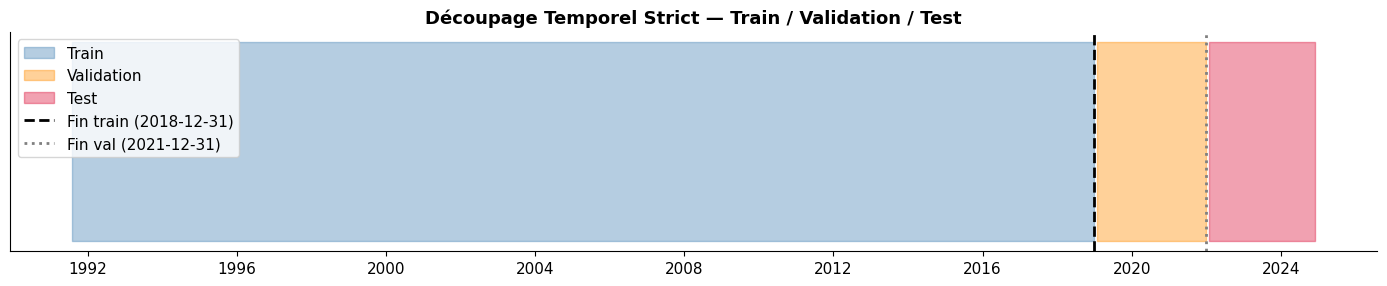

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 19 — Découpage Chronologique Train / Validation / Test
# ══════════════════════════════════════════════════════════════════════════════

# ── Masques temporels ─────────────────────────────────────────────────────────
train_mask = df_model.index <= TRAIN_END
val_mask   = (df_model.index > TRAIN_END) & (df_model.index <= VAL_END)
test_mask  = df_model.index > VAL_END

# ── Splits pour chaque cible : niveaux + variations ──────────────────────────
# CIBLE : les VARIATIONS (plus stationnaires)
splits = {}
for target in TARGET_COLS_LEVEL + TARGET_COLS_DELTA:
    mask_notna = df_model[target].notna()
    splits[target] = {
        'X_train': df_model.loc[train_mask & mask_notna, FEATURE_COLS],
        'y_train': df_model.loc[train_mask & mask_notna, target],
        'X_val':   df_model.loc[val_mask   & mask_notna, FEATURE_COLS],
        'y_val':   df_model.loc[val_mask   & mask_notna, target],
        'X_test':  df_model.loc[test_mask  & mask_notna, FEATURE_COLS],
        'y_test':  df_model.loc[test_mask  & mask_notna, target],
    }

# ── Raccourcis pour la cible principale : delta du niveau ────────────────────
MAIN_TARGET = 'delta_level_t1'

X_train_main = splits[MAIN_TARGET]['X_train']
y_train_main = splits[MAIN_TARGET]['y_train']

X_val_main = splits[MAIN_TARGET]['X_val']
y_val_main = splits[MAIN_TARGET]['y_val']

X_test_main = splits[MAIN_TARGET]['X_test']
y_test_main = splits[MAIN_TARGET]['y_test']

print("═" * 65)
print("  DÉCOUPAGE CHRONOLOGIQUE")
print("═" * 65)

for split_name, y_data in [
    ('Train',      y_train_main),
    ('Validation', y_val_main),
    ('Test',       y_test_main)
]:
    n = len(y_data)
    t_min = y_data.index.min().date()
    t_max = y_data.index.max().date()
    pct = n / len(df_model) * 100
    print(f"  {split_name:<12}: {n:4d} obs. ({pct:.0f}%)  [{t_min} → {t_max}]")

print(f"\n  Features         : {len(FEATURE_COLS)}")
print(f"  Cible principale : {MAIN_TARGET}")
print(f"  Cibles niveau    : {TARGET_COLS_LEVEL}")
print(f"  Cibles Δ         : {TARGET_COLS_DELTA}")
print()
print("  ⚠ Rappel : le scaling sera ajusté UNIQUEMENT sur le train")
print("    pour éviter toute fuite d'information (data leakage).")

# ── Sanity checks ─────────────────────────────────────────────────────────────
print("\nSanity checks :")
print("  NaN train :", X_train_main.isna().sum().sum(), y_train_main.isna().sum())
print("  NaN val   :", X_val_main.isna().sum().sum(), y_val_main.isna().sum())
print("  NaN test  :", X_test_main.isna().sum().sum(), y_test_main.isna().sum())

overlap_cols = set(X_train_main.columns).intersection({MAIN_TARGET})
print("  Overlap X / y :", overlap_cols)

print("\nDimensions par cible Δ :")
for target in TARGET_COLS_DELTA:
    s = splits[target]
    print(
        f"  {target:<24} | "
        f"train={s['X_train'].shape}, "
        f"val={s['X_val'].shape}, "
        f"test={s['X_test'].shape}"
    )

# ── Validation croisée temporelle (à utiliser seulement sur le train) ───────
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=0)

# ── Visualisation du split ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))

for label, mask, color in [
    ('Train', train_mask, 'steelblue'),
    ('Validation', val_mask, 'darkorange'),
    ('Test', test_mask, 'crimson')
]:
    idx = df_model.index[mask]
    if len(idx) > 0:
        ax.fill_between(idx, 0, 1, alpha=0.4, color=color, label=label)

ax.axvline(pd.to_datetime(TRAIN_END), color='black', linewidth=2,
           linestyle='--', label=f'Fin train ({TRAIN_END})')
ax.axvline(pd.to_datetime(VAL_END), color='gray', linewidth=2,
           linestyle=':', label=f'Fin val ({VAL_END})')

ax.set_title('Découpage Temporel Strict — Train / Validation / Test', fontsize=13)
ax.set_yticks([])
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('temporal_split.png', dpi=100, bbox_inches='tight')
plt.show()
# ── Aliases pour les cellules suivantes ─────────────────────────────────────
X_tr  = X_train_main.values
X_val = X_val_main.values
X_te  = X_test_main.values


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 20 — Standardisation, métriques et helpers d'évaluation
# ══════════════════════════════════════════════════════════════════════════════

# Le scaler est AJUSTÉ uniquement sur le train (pas de fuite d'information).
scaler_X = StandardScaler()
X_tr_sc  = scaler_X.fit_transform(X_tr)
X_val_sc = scaler_X.transform(X_val)
X_te_sc  = scaler_X.transform(X_te)

means_tr = X_tr_sc.mean(axis=0)
stds_tr  = X_tr_sc.std(axis=0)
print("✓ Features standardisées (train) :")
print(f"  Moyenne max   : {np.abs(means_tr).max():.6f} (attendu ≈ 0)")
print(f"  Ecart-type moy: {stds_tr.mean():.6f} (attendu ≈ 1)")
print(f"  Shape train   : {X_tr_sc.shape}")

RESULTS     = {}
BEST_MODELS = {}
MODEL_GRIDS = {}


def directional_accuracy(y_true, y_pred, y_prev=None, eps=1e-8):
    """Directional Accuracy : proportion de bonnes directions prevues."""
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]; y_pred = y_pred[:n]

    if y_prev is None:
        y_prev = np.r_[y_true[0], y_true[:-1]]
    else:
        if hasattr(y_prev, 'values'): y_prev = y_prev.values
        y_prev = np.asarray(y_prev, dtype=float).reshape(-1)[:n]

    delta_true = y_true - y_prev
    delta_pred = y_pred - y_prev
    valid = np.isfinite(delta_true) & np.isfinite(delta_pred)
    if valid.sum() == 0:
        return np.nan
    sign_true = np.where(np.abs(delta_true[valid]) <= eps, 0, np.sign(delta_true[valid]))
    sign_pred = np.where(np.abs(delta_pred[valid]) <= eps, 0, np.sign(delta_pred[valid]))
    return float(np.mean(sign_true == sign_pred))


def compute_metrics(y_true, y_pred, y_prev=None):
    """Calcule RMSE, MAE, R2 et Directional Accuracy."""
    if hasattr(y_true, 'values'): y_true = y_true.values
    if hasattr(y_pred, 'values'): y_pred = y_pred.values
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]; y_pred = y_pred[:n]
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'DA': np.nan}
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])))
    mae  = float(mean_absolute_error(y_true[mask], y_pred[mask]))
    r2   = float(r2_score(y_true[mask], y_pred[mask]))
    da   = directional_accuracy(y_true, y_pred, y_prev)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'DA': da}


def skill_score(rmse_model, rmse_baseline):
    """Skill Score vs baseline : positif = modele meilleur que baseline (en %)."""
    if not np.isfinite(rmse_baseline) or rmse_baseline == 0:
        return np.nan
    return float((1.0 - rmse_model / rmse_baseline) * 100.0)


def evaluate_model_all_factors(model_name, model_factory, use_scaled=True,
                               tuned_params_by_factor=None, note=None):
    """
    Entraine et evalue un modele sur les NIVEAUX des facteurs (TARGET_COLS_LEVEL).
    Toutes les cibles partagent le meme X (meme masque dropna global).
    """
    results = {}
    for target in TARGET_COLS_LEVEL:
        f_name = target.replace('_t1', '')
        y_tr = splits[target]['y_train']
        y_va = splits[target]['y_val']
        y_te = splits[target]['y_test']

        Xtr = X_tr_sc if use_scaled else X_tr
        Xva = X_val_sc if use_scaled else X_val
        Xte = X_te_sc  if use_scaled else X_te

        model = clone(model_factory())
        if tuned_params_by_factor and f_name in tuned_params_by_factor:
            model.set_params(**tuned_params_by_factor[f_name])

        model.fit(Xtr, y_tr)
        pred_tr  = model.predict(Xtr)
        pred_val = model.predict(Xva)
        pred_te  = model.predict(Xte)

        # Valeur precedente (y(t)) pour la Directional Accuracy
        prev_va = factors_eco[f_name].reindex(y_va.index).values
        prev_te = factors_eco[f_name].reindex(y_te.index).values

        results[f_name] = {
            'train': compute_metrics(y_tr, pred_tr),
            'val':   compute_metrics(y_va, pred_val, prev_va),
            'test':  compute_metrics(y_te, pred_te, prev_te),
            'pred_val': pred_val,
            'pred_te':  pred_te,
            'fitted_model': model
        }
        if tuned_params_by_factor and f_name in tuned_params_by_factor:
            results[f_name]['best_params'] = tuned_params_by_factor[f_name]
        if note is not None:
            results[f_name]['note'] = note

        print(f"  {model_name:<22} | {f_name:<25} | "
              f"RMSE_val={results[f_name]['val']['RMSE']:.4f} | "
              f"RMSE_test={results[f_name]['test']['RMSE']:.4f} | "
              f"R2_test={results[f_name]['test']['R2']:.3f} | "
              f"DA_test={results[f_name]['test']['DA']*100:.1f}%")

    RESULTS[model_name] = results
    return results


def run_gridsearch_per_factor(model_label, estimator_factory, param_grid, use_scaler=True):
    """
    GridSearchCV sur chaque facteur cible (NIVEAUX).
    Pipeline avec scaler intégré pour eviter la fuite d'information en CV.
    """
    best_params_by_factor = {}
    best_scores_by_factor = {}
    MODEL_GRIDS[model_label] = {}

    for target in TARGET_COLS_LEVEL:
        f_name = target.replace('_t1', '')
        y_tr   = splits[target]['y_train']

        if use_scaler:
            estimator = Pipeline([('scaler', StandardScaler()), ('model', estimator_factory())])
            grid  = {f'model__{k}': v for k, v in param_grid.items()}
            X_fit = X_tr
        else:
            estimator = estimator_factory()
            grid  = param_grid
            X_fit = X_tr

        gs = GridSearchCV(estimator, param_grid=grid, cv=tscv,
                          scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
        gs.fit(X_fit, y_tr)

        params = gs.best_params_
        if use_scaler:
            params = {k.replace('model__', ''): v for k, v in params.items()}

        best_params_by_factor[f_name] = params
        best_scores_by_factor[f_name] = -gs.best_score_
        MODEL_GRIDS[model_label][f_name] = gs

        print(f"  {model_label:<18} | {f_name:<25} | "
              f"best_rmse_cv={-gs.best_score_:.4f} | params={params}")

    return best_params_by_factor, best_scores_by_factor


print("\n✓ Pipeline de preprocessing pret.")
print(f"  Shapes : X_train={X_tr_sc.shape}, X_val={X_val_sc.shape}, X_test={X_te_sc.shape}")


✓ Features standardisées (train) :
  Moyenne max   : 0.000000 (attendu ≈ 0)
  Ecart-type moy: 1.000000 (attendu ≈ 1)
  Shape train   : (330, 95)

✓ Pipeline de preprocessing pret.
  Shapes : X_train=(330, 95), X_val=(36, 95), X_test=(35, 95)


## 6. Modèles de Référence (Baselines)

Avant d'entraîner des modèles complexes, nous établissons des **baselines indispensables**. En l'absence de baselines, il est impossible d'évaluer si les modèles de machine learning apportent une réelle valeur ajoutée.

### Baseline 1 — Naïve (Persistence / Absence de variation)

Deux formulations sont utilisées selon la nature de la cible :

- **Pour les variables en niveau** :

$$
\hat{f}_{t+1} = f_t
$$

- **Pour les variables en variation** :

$$
\widehat{\Delta f}_{t+1} = 0
$$

Dans ce cas, la meilleure prédiction est qu'il n'y aura **aucun changement** le mois suivant.

Ces baselines sont particulièrement difficiles à battre dans le cas des taux d’intérêt, en raison :
- de leur **forte persistance** (niveaux),
- et de la **faible prévisibilité des variations à court terme**.

---

### Baseline 2 — Régression Ridge

La régression Ridge est un modèle linéaire pénalisé qui minimise :

$$
\min_{\beta} \left( \|y - X\beta\|^2 + \lambda \|\beta\|^2 \right)
$$

Elle présente plusieurs avantages clés :

- **Robustesse** face à la multicolinéarité (fréquente sur la courbe des taux),
- **Réduction du surapprentissage** grâce à la régularisation L2,
- **Interprétabilité économique** des coefficients.

Dans les données financières, les modèles linéaires régularisés constituent souvent une baseline **très compétitive**, parfois difficile à surpasser par des modèles plus complexes.

---

### Objectif des baselines

Ces modèles servent de référence pour :
- quantifier le gain réel apporté par le machine learning,
- éviter les illusions de performance,
- détecter les situations où un modèle complexe **n'apporte aucune amélioration significative**.

In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 21 — Baselines : Persistance et Ridge sur les NIVEAUX
# ══════════════════════════════════════════════════════════════════════════════
#
# Tous les modeles predisent les NIVEAUX des facteurs a t+1.
# Baseline naive = persistance : y_hat(t+1) = y(t)
# C'est la reference standard pour les series fortement autocorrelees.
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  BASELINES — PREDICTION DES NIVEAUX DE FACTEURS")
print("=" * 70)
print("  Cibles : level_t1, slope_10y_3m_t1, curvature_t1  (horizon +1 mois)")

# ─────────────────────────────────────────────────────────────────────────────
# [1] Baseline Naive : Persistance  y_hat(t+1) = y(t)
# ─────────────────────────────────────────────────────────────────────────────
print("\n[1] Baseline Naive — Persistance (y_hat(t+1) = y(t))")
print("-" * 70)

results_naive = {}
for target in TARGET_COLS_LEVEL:
    f_name  = target.replace('_t1', '')
    y_val_f = splits[target]['y_val']
    y_te_f  = splits[target]['y_test']

    # Prediction : valeur courante du facteur (meme date que la prediction)
    pred_val_n = factors_eco[f_name].reindex(y_val_f.index).values
    pred_te_n  = factors_eco[f_name].reindex(y_te_f.index).values

    # Fallback si NaN (ne devrait pas arriver apres nettoyage)
    pred_val_n = np.where(np.isfinite(pred_val_n), pred_val_n, np.nanmean(pred_val_n))
    pred_te_n  = np.where(np.isfinite(pred_te_n),  pred_te_n,  np.nanmean(pred_te_n))

    prev_val = factors_eco[f_name].reindex(y_val_f.index).values
    prev_te  = factors_eco[f_name].reindex(y_te_f.index).values

    m_val = compute_metrics(y_val_f, pred_val_n, prev_val)
    m_te  = compute_metrics(y_te_f,  pred_te_n,  prev_te)

    results_naive[f_name] = {
        'val': m_val, 'test': m_te,
        'pred_val': pred_val_n, 'pred_te': pred_te_n
    }
    print(f"  {f_name:<25} | "
          f"RMSE_val={m_val['RMSE']:.4f} | RMSE_test={m_te['RMSE']:.4f} | "
          f"R2_test={m_te['R2']:.3f} | DA_test={m_te['DA']*100:.1f}%")

RESULTS['Naive (Persistance)'] = results_naive


# ─────────────────────────────────────────────────────────────────────────────
# [2] Ridge sur les niveaux (GridSearchCV temporelle)
# ─────────────────────────────────────────────────────────────────────────────
print("\n[2] Ridge — Regularisation L2 sur niveaux")
print("-" * 70)

ridge_param_grid = {'alpha': np.logspace(-2, 4, 30)}

ridge_best_params, ridge_cv_scores = run_gridsearch_per_factor(
    model_label='Ridge',
    estimator_factory=lambda: Ridge(),
    param_grid=ridge_param_grid,
    use_scaler=True
)

best_alpha_ridge = ridge_best_params.get('level', {}).get('alpha', 1.0)
print(f"\n  alpha Ridge retenu (facteur level) : {best_alpha_ridge:.4f}")

evaluate_model_all_factors(
    'Ridge',
    model_factory=lambda: Ridge(),
    use_scaled=True,
    tuned_params_by_factor=ridge_best_params,
    note="Regularisation L2, hyperparametres optimises par CV temporelle."
)


  BASELINES — PREDICTION DES NIVEAUX DE FACTEURS
  Cibles : level_t1, slope_10y_3m_t1, curvature_t1  (horizon +1 mois)

[1] Baseline Naive — Persistance (y_hat(t+1) = y(t))
----------------------------------------------------------------------
  level                     | RMSE_val=0.1829 | RMSE_test=0.2959 | R2_test=0.891 | DA_test=0.0%
  slope_10y_3m              | RMSE_val=0.2253 | RMSE_test=0.3795 | R2_test=0.874 | DA_test=0.0%
  curvature                 | RMSE_val=0.1925 | RMSE_test=0.4464 | R2_test=0.829 | DA_test=0.0%

[2] Ridge — Regularisation L2 sur niveaux
----------------------------------------------------------------------
  Ridge              | level                     | best_rmse_cv=0.5472 | params={'alpha': np.float64(137.3823795883264)}
  Ridge              | slope_10y_3m              | best_rmse_cv=0.4471 | params={'alpha': np.float64(221.22162910704503)}
  Ridge              | curvature                 | best_rmse_cv=0.5218 | params={'alpha': np.float64(356.224789

{'level': {'train': {'RMSE': 0.28088489555387014,
   'MAE': 0.21685273258176493,
   'R2': 0.9785141514954686,
   'DA': 0.5606060606060606},
  'val': {'RMSE': 0.4154736085884279,
   'MAE': 0.31258440157032635,
   'R2': 0.6308496265030403,
   'DA': 0.4722222222222222},
  'test': {'RMSE': 0.49078489940231,
   'MAE': 0.41785020619871777,
   'R2': 0.7007347835702806,
   'DA': 0.45714285714285713},
  'pred_val': array([2.66152316, 2.69399527, 2.72710655, 2.50513058, 2.55225335,
         2.1654645 , 2.08759734, 2.2434527 , 1.77725283, 2.04027292,
         1.7619123 , 1.8826773 , 1.94920279, 1.66743711, 1.21195596,
         0.33759462, 0.14636936, 1.06254046, 0.99912269, 0.78826203,
         0.733019  , 0.61050163, 0.57074753, 0.76407008, 0.63675224,
         0.54485545, 0.77980506, 0.92235397, 0.7580425 , 0.68047925,
         0.60680352, 0.54832085, 0.64040928, 0.65489661, 0.85041379,
         0.66672468]),
  'pred_te': array([0.99347808, 1.12251289, 1.35745098, 2.09632237, 2.2806234 ,
      

Les résultats des baselines mettent en évidence la forte persistance des facteurs de la courbe des taux.

La baseline naïve, fondée sur une simple persistance, offre des performances remarquables en RMSE et en R², confirmant que la dynamique des taux est proche d’un random walk à court horizon.

Le modèle Ridge, bien qu’il capture partiellement la structure des données et améliore la prédiction directionnelle, ne parvient pas à surpasser la baseline en termes d’erreur quadratique.

Ces résultats soulignent la difficulté d’extraire un signal prédictif stable dans les taux d’intérêt, et justifient l’importance d’utiliser des baselines simples pour évaluer la performance des modèles plus complexes.

## 7. Modèles de Machine Learning

### 7.1 Random Forest

Le **Random Forest** (Breiman, 2001) est un algorithme d'ensemble basé sur le principe du **bagging** (*Bootstrap Aggregating*), visant à réduire la variance des modèles de type arbre de décision.

Le mécanisme repose sur trois étapes principales :

1. **Bootstrap des données** :  
   $B$ échantillons sont tirés avec remise à partir des données d'entraînement.

2. **Construction d'arbres de décision** :  
   Chaque arbre $T_b$ est entraîné indépendamment sur un échantillon bootstrap.

3. **Randomisation des features** :  
   À chaque split, seul un sous-ensemble aléatoire de $m \approx \sqrt{p}$ variables explicatives est considéré, ce qui introduit de la diversité entre les arbres.

La prédiction finale est obtenue par **moyennage** des prédictions individuelles :

$$
\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})
$$

### Intuition économique et statistique

La double randomisation (échantillonnage bootstrap + sélection aléatoire de variables) permet de :

- **Décorréler les arbres**, réduisant ainsi la variance globale du modèle
- Maintenir un **biais faible** (les arbres restent expressifs)
- Capturer des **relations non-linéaires** et des **interactions complexes** entre variables

### Avantages dans le contexte financier

Le Random Forest est particulièrement adapté aux données financières car il :

- Est **robuste aux valeurs aberrantes**
- Gère naturellement les **non-linéarités**
- Capture les **interactions entre variables macro et de marché**
- Nécessite peu de prétraitement (pas de normalisation stricte)
- Fournit des mesures d'**importance des variables**, utiles pour l'interprétation économique

### Limites

- Moins performant que des méthodes de boosting sur certains jeux de données
- Difficulté d'extrapolation hors des plages observées
- Moins interprétable qu’un modèle linéaire (effets marginaux non explicites)

---

Dans notre cadre, le Random Forest constitue une **première alternative non-linéaire** au modèle Ridge, permettant de tester si des relations complexes améliorent la prévision des facteurs de la courbe des taux.

  RANDOM FOREST — Prediction des niveaux de facteurs
Recherche des hyperparametres RF (TimeSeriesSplit CV)
  Random Forest      | level                     | best_rmse_cv=0.7668 | params={'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 200}
  Random Forest      | slope_10y_3m              | best_rmse_cv=0.4548 | params={'max_depth': 3, 'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 400}
  Random Forest      | curvature                 | best_rmse_cv=0.5407 | params={'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 200}
  Random Forest          | level                     | RMSE_val=0.6234 | RMSE_test=0.5185 | R2_test=0.666 | DA_test=51.4%
  Random Forest          | slope_10y_3m              | RMSE_val=0.3628 | RMSE_test=1.1182 | R2_test=-0.094 | DA_test=54.3%
  Random Forest          | curvature                 | RMSE_val=0.2847 | RMSE_test=0.9034 | R2_test=0.298 | DA_test=42.9%

Top 15 features (RF — cible level_t1)

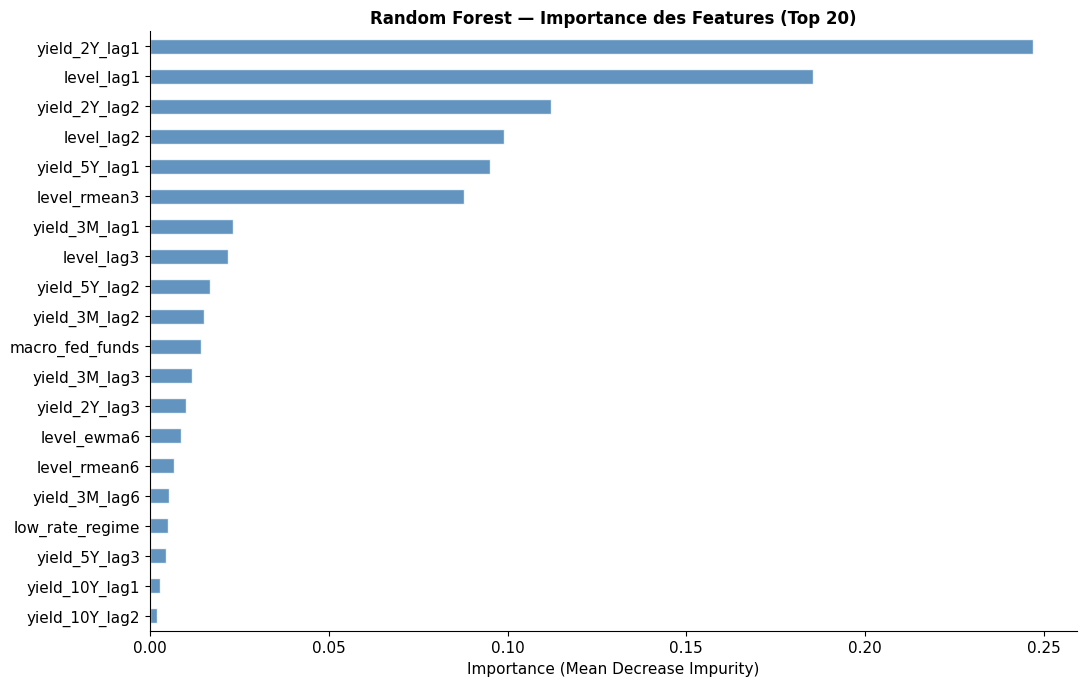

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 22 — Random Forest Regressor (niveaux)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  RANDOM FOREST — Prediction des niveaux de facteurs")
print("=" * 70)

# Grille ajustee : pas de max_depth=None pour eviter le surapprentissage
# avec ~300 observations et 80+ features.
rf_param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [3, 5, 7, 10],
    'max_features':     ['sqrt', 0.3, 0.5],
    'min_samples_leaf': [5, 10, 15]
}

print("Recherche des hyperparametres RF (TimeSeriesSplit CV)")

rf_best_params, rf_cv_scores = run_gridsearch_per_factor(
    model_label='Random Forest',
    estimator_factory=lambda: RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid=rf_param_grid,
    use_scaler=False
)

rf_results = evaluate_model_all_factors(
    'Random Forest',
    model_factory=lambda: RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    use_scaled=False,
    tuned_params_by_factor=rf_best_params,
    note="Hyperparametres optimises par CV temporelle."
)

# ── Importance des variables (facteur level) ──────────────────────────────────
rf_final = RandomForestRegressor(
    random_state=RANDOM_SEED, n_jobs=-1,
    **rf_best_params.get('level', {})
)
rf_final.fit(X_tr, splits[TARGET_COLS_LEVEL[0]]['y_train'])

rf_importance = pd.Series(
    rf_final.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print(f"\nTop 15 features (RF — cible level_t1) :")
print(rf_importance.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 7))
rf_importance.head(20).plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Random Forest — Importance des Features (Top 20)', fontsize=12)
ax.set_xlabel('Importance (Mean Decrease Impurity)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()


Le modèle Random Forest met en évidence une structure économique cohérente des déterminants des taux, dominée par les variables de type lag et les taux intermédiaires (notamment le 2 ans).

Cependant, ses performances hors échantillon restent décevantes, avec une dégradation marquée entre validation et test, particulièrement sur le facteur pente. Cela suggère un phénomène d’overfitting temporel, lié à l’instabilité des relations dans le temps.

Malgré sa capacité à capturer des non-linéarités, le modèle ne parvient pas à surpasser la baseline naïve, confirmant que la dynamique des taux est fortement dominée par la persistance.

Ainsi, le Random Forest apporte principalement une compréhension des variables explicatives, plutôt qu’un gain significatif en performance prédictive.

### 7.2 Gradient Boosting / XGBoost

Le **Gradient Boosting** (Friedman, 2001) est une méthode d’ensemble qui construit les modèles de manière **séquentielle**, contrairement au Random Forest. Chaque nouvel arbre est entraîné pour corriger les erreurs du modèle précédent.

Plus formellement, le modèle s’écrit comme une somme d’arbres :

$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \nu \cdot h_m(\mathbf{x})
$$

où :
- $F_m$ est le modèle à l’itération $m$
- $h_m$ est un nouvel arbre de décision
- $\nu$ est le **taux d’apprentissage** (*learning rate*)

Chaque arbre est ajusté sur les **pseudo-résidus**, qui correspondent au gradient négatif de la fonction de perte :

$$
r_{i,m} = -\left[\frac{\partial L(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)}\right]_{F=F_{m-1}}
$$

### Intuition

Le modèle apprend **progressivement** :
- les premiers arbres capturent les structures principales
- les suivants corrigent les erreurs restantes

Cela permet de construire un modèle très flexible, capable de capturer des **relations complexes et non linéaires**.

### Rôle du taux d’apprentissage

Le paramètre $\nu$ contrôle la vitesse d’apprentissage :

- $\nu$ **faible** (0.01–0.1) → apprentissage lent mais plus robuste (*shrinkage*)
- $\nu$ **élevé** → apprentissage rapide mais risque de surapprentissage

En pratique, un petit $\nu$ combiné à un grand nombre d’arbres donne les meilleures performances.

---

### XGBoost : une version optimisée

**XGBoost** (Chen & Guestrin, 2016) est une implémentation améliorée du gradient boosting, intégrant :

- **Régularisation L1/L2** sur les feuilles (contrôle du surapprentissage)
- **Subsampling des observations** (row sampling)
- **Subsampling des variables** (column sampling)
- Gestion efficace des données manquantes
- Optimisations de calcul (parallélisation, cache-aware)

Le modèle optimise une fonction objectif régularisée :

$$
\mathcal{L} = \sum_i L(y_i, \hat{y}_i) + \sum_k \Omega(h_k)
$$

avec :

$$
\Omega(h) = \gamma T + \frac{1}{2} \lambda \sum w_j^2
$$

où :
- $T$ = nombre de feuilles
- $w_j$ = poids des feuilles
- $\gamma, \lambda$ = paramètres de régularisation

---

### Intérêt dans notre contexte

Dans le cadre de la prévision de la courbe des taux, XGBoost est particulièrement adapté car il :

- Capture des **non-linéarités fines** entre facteurs et macro
- Gère efficacement un grand nombre de features
- Est robuste au bruit et aux interactions complexes
- Surpasse souvent les modèles linéaires sur des signaux faibles

---

Dans la suite, nous évaluons si XGBoost permet d’améliorer les performances obtenues avec Ridge et Random Forest, en particulier pour la prévision de la **pente** et de la **courbure**, qui présentent un signal prédictif plus marqué.

  GRADIENT BOOSTING — Prediction des niveaux de facteurs
  Gradient Boosting  | level                     | best_rmse_cv=0.7855 | params={'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 100, 'subsample': 0.7}
  Gradient Boosting  | slope_10y_3m              | best_rmse_cv=0.4593 | params={'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 100, 'subsample': 0.9}
  Gradient Boosting  | curvature                 | best_rmse_cv=0.5255 | params={'learning_rate': 0.01, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}
  Gradient Boosting      | level                     | RMSE_val=0.7004 | RMSE_test=0.5338 | R2_test=0.646 | DA_test=42.9%
  Gradient Boosting      | slope_10y_3m              | RMSE_val=0.4043 | RMSE_test=1.1211 | R2_test=-0.099 | DA_test=54.3%
  Gradient Boosting      | curvature                 | RMSE_val=0.3443 | RMSE_test=0.9592 | R2_test=0.209 | DA_test=42.9%

  XGBOOST — Prediction des n

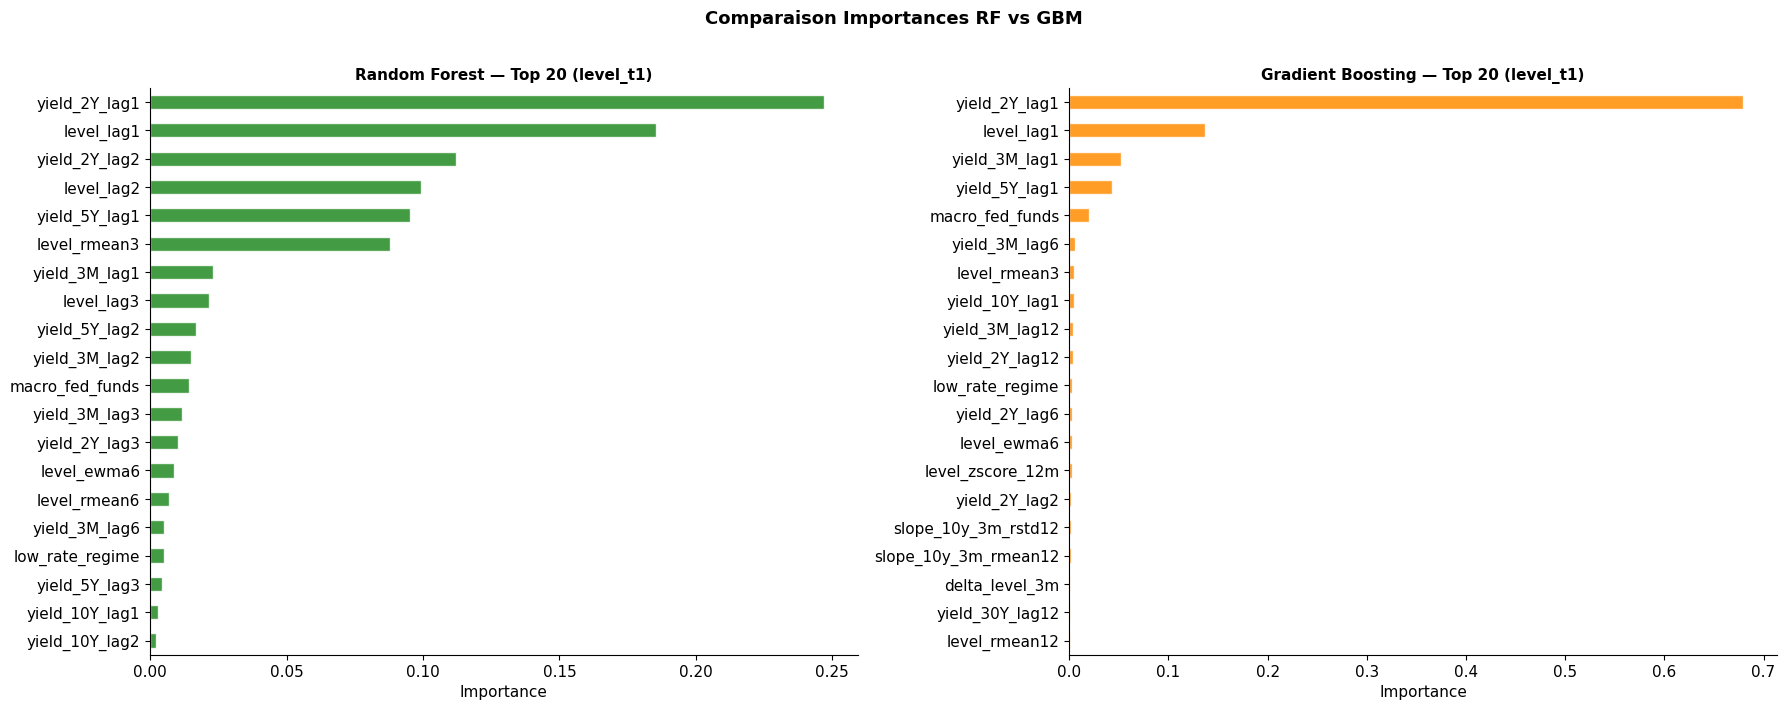

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 23 — Gradient Boosting et XGBoost (niveaux)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  GRADIENT BOOSTING — Prediction des niveaux de facteurs")
print("=" * 70)

gbm_param_grid = {
    'n_estimators':     [100, 200, 400],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [2, 3, 4],
    'subsample':        [0.7, 0.9, 1.0],
    'min_samples_leaf': [5, 10]
}

gbm_best_params, gbm_cv_scores = run_gridsearch_per_factor(
    model_label='Gradient Boosting',
    estimator_factory=lambda: GradientBoostingRegressor(random_state=RANDOM_SEED),
    param_grid=gbm_param_grid,
    use_scaler=False
)

gbm_results = evaluate_model_all_factors(
    'Gradient Boosting',
    model_factory=lambda: GradientBoostingRegressor(random_state=RANDOM_SEED),
    use_scaled=False,
    tuned_params_by_factor=gbm_best_params,
    note="Hyperparametres optimises par CV temporelle."
)

if HAS_XGB:
    print("\n" + "=" * 70)
    print("  XGBOOST — Prediction des niveaux de facteurs")
    print("=" * 70)

    xgb_param_grid = {
        'n_estimators':    [100, 200, 400],
        'learning_rate':   [0.01, 0.05, 0.1],
        'max_depth':       [2, 3, 4],
        'subsample':       [0.7, 0.9],
        'colsample_bytree':[0.6, 0.8, 1.0],
        'reg_alpha':       [0, 0.1],
        'reg_lambda':      [1, 2]
    }

    xgb_best_params, xgb_cv_scores = run_gridsearch_per_factor(
        model_label='XGBoost',
        estimator_factory=lambda: xgb.XGBRegressor(
            random_state=RANDOM_SEED, verbosity=0, n_jobs=-1),
        param_grid=xgb_param_grid,
        use_scaler=False
    )

    xgb_results = evaluate_model_all_factors(
        'XGBoost',
        model_factory=lambda: xgb.XGBRegressor(
            random_state=RANDOM_SEED, verbosity=0, n_jobs=-1),
        use_scaled=False,
        tuned_params_by_factor=xgb_best_params,
        note="Hyperparametres optimises par CV temporelle."
    )

# ── Importance GBM ────────────────────────────────────────────────────────────
gbm_final = GradientBoostingRegressor(
    random_state=RANDOM_SEED, **gbm_best_params.get('level', {}))
gbm_final.fit(X_tr, splits[TARGET_COLS_LEVEL[0]]['y_train'])

gbm_importance = pd.Series(
    gbm_final.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print(f"\nTop 15 features (GBM — cible level_t1) :")
print(gbm_importance.head(15).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, imp, title, color in zip(
    axes,
    [rf_importance.head(20), gbm_importance.head(20)],
    ['Random Forest — Top 20 (level_t1)', 'Gradient Boosting — Top 20 (level_t1)'],
    ['forestgreen', 'darkorange']
):
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle("Comparaison Importances RF vs GBM", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rf_vs_gbm_importance.png', dpi=120, bbox_inches='tight')
plt.show()


Les modèles de Gradient Boosting et XGBoost, bien que capables de capturer des relations non-linéaires complexes, ne parviennent pas à améliorer la performance prédictive par rapport à des modèles plus simples.

L’analyse des importances montre une forte concentration du signal sur les variables de type lag, en particulier le taux à 2 ans, confirmant la dominance de la persistance dans la dynamique des taux.

Cependant, les performances hors échantillon se dégradent fortement, notamment pour le facteur pente, indiquant un phénomène d’overfitting et une instabilité des relations dans le temps.

Ces résultats suggèrent que, dans ce contexte, la complexité accrue des modèles boostés ne permet pas de compenser le faible signal prédictif disponible, et peut même nuire à la robustesse des prédictions.

  TABLEAU COMPARATIF — NIVEAUX DES FACTEURS

RMSE par Facteur (Validation) :
Facteur              curvature   level  slope_10y_3m
Modele                                              
Gradient Boosting       0.3443  0.7004        0.4043
LSTM                       NaN  0.6961           NaN
Naive (Persistance)     0.1925  0.1829        0.2253
Random Forest           0.2847  0.6234        0.3628
Ridge                   0.4109  0.4155        0.6358
XGBoost                 0.3454  0.6184        0.5153

── Skill Score vs Naïve Persistance (Test, %) — positif = meilleur ──
                   level  slope_10y_3m  curvature
Modele                                           
Ridge              -65.9         -65.8      -54.8
Random Forest      -75.2        -194.7     -102.4
Gradient Boosting  -80.4        -195.5     -114.9
XGBoost            -98.0        -231.5     -122.7
LSTM              -824.2           NaN        NaN
  (positif = amelioration sur la baseline persistance)

→ Meilleur modele par 

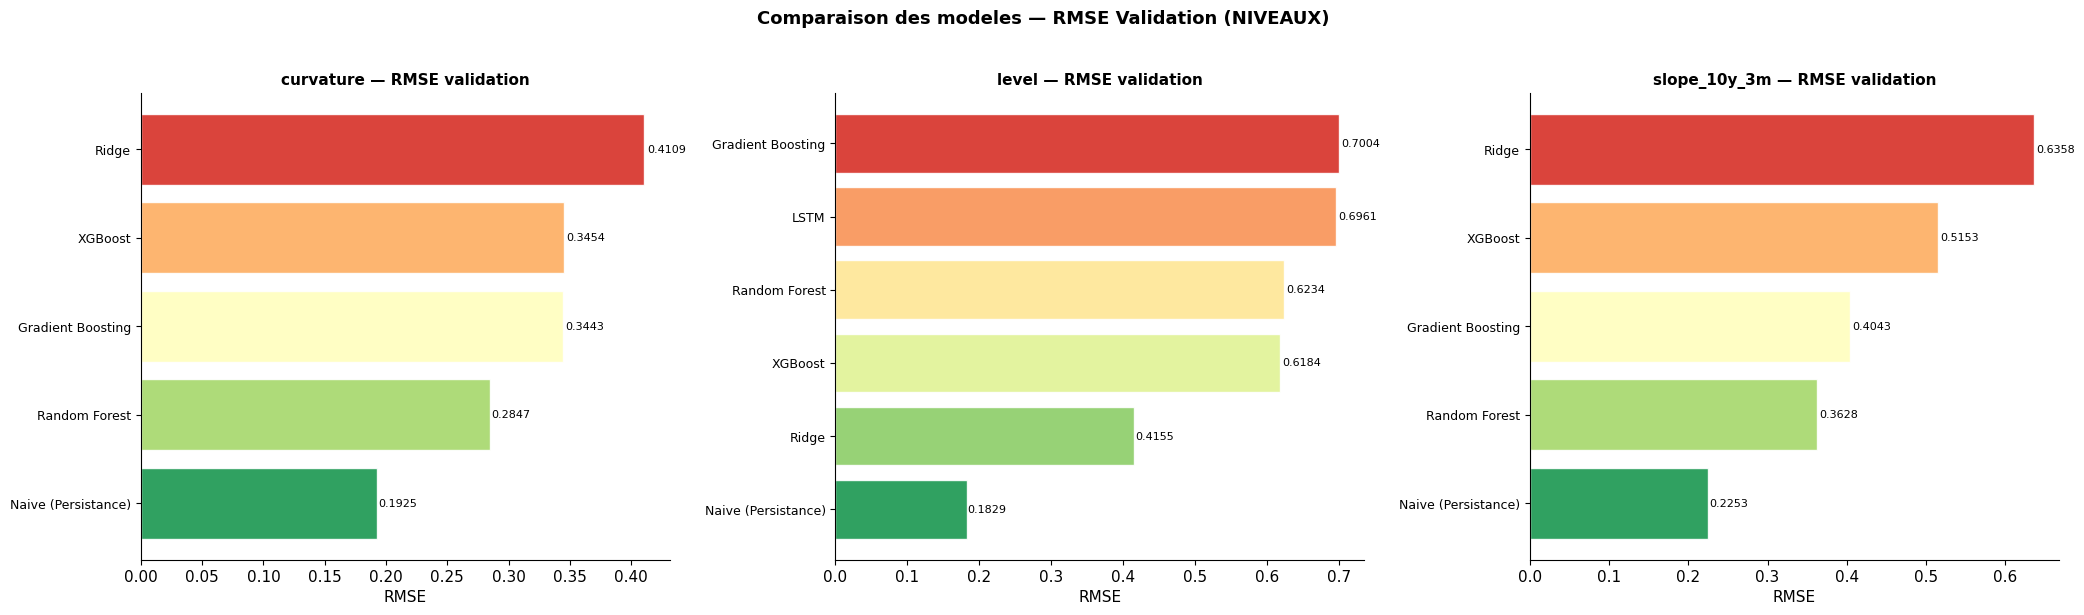

In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 24 — Comparaison des Modeles : RMSE, R2, DA, Skill Score
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("  TABLEAU COMPARATIF — NIVEAUX DES FACTEURS")
print("=" * 80)

comparison_rows = []
for model_name, model_results in RESULTS.items():
    for factor_name, factor_results in model_results.items():
        for split_name in ['val', 'test']:
            if split_name in factor_results:
                m = factor_results[split_name]
                comparison_rows.append({
                    'Modele': model_name, 'Facteur': factor_name,
                    'Split': split_name,
                    'RMSE': m['RMSE'], 'MAE': m['MAE'],
                    'R2': m['R2'], 'DA (%)': m['DA'] * 100
                })

comp_df = pd.DataFrame(comparison_rows)

comp_val = comp_df[comp_df['Split'] == 'val'].pivot_table(
    index='Modele', columns='Facteur', values='RMSE', aggfunc='mean'
).round(4)

comp_test = comp_df[comp_df['Split'] == 'test'].pivot_table(
    index='Modele', columns='Facteur', values='RMSE', aggfunc='mean'
).round(4)

print("\nRMSE par Facteur (Validation) :")
print(comp_val.to_string())

# ── Skill Score vs Naive Persistance ──────────────────────────────────────────
print("\n── Skill Score vs Naïve Persistance (Test, %) — positif = meilleur ──")
naive_rmse_test = {}
if 'Naive (Persistance)' in RESULTS:
    for f_name, fr in RESULTS['Naive (Persistance)'].items():
        naive_rmse_test[f_name] = fr['test']['RMSE']

ss_table = []
for model_name, model_results in RESULTS.items():
    if model_name == 'Naive (Persistance)':
        continue
    row = {'Modele': model_name}
    for f_name, naive_r in naive_rmse_test.items():
        if f_name in model_results and 'test' in model_results[f_name]:
            rmse_m = model_results[f_name]['test']['RMSE']
            row[f_name] = round(skill_score(rmse_m, naive_r), 1)
        else:
            row[f_name] = np.nan
    ss_table.append(row)

ss_df = pd.DataFrame(ss_table).set_index('Modele')
print(ss_df.to_string())
print("  (positif = amelioration sur la baseline persistance)")

# ── Meilleur modele ───────────────────────────────────────────────────────────
print("\n→ Meilleur modele par facteur (RMSE validation) :")
BEST_MODELS = {}
factor_cols = [c for c in comp_val.columns]
for col in factor_cols:
    best = comp_val[col].idxmin()
    BEST_MODELS[col] = {'model_name': best, 'val_rmse': float(comp_val.loc[best, col])}
    print(f"  {col:<25} : {best} (RMSE_val={comp_val.loc[best, col]:.4f})")

comp_val['RMSE moyen'] = comp_val[factor_cols].mean(axis=1)
BEST_GLOBAL_MODEL = comp_val['RMSE moyen'].idxmin()
print(f"\n→ Meilleur modele global : {BEST_GLOBAL_MODEL}")
print(comp_val['RMSE moyen'].sort_values().round(4).to_string())

# ── Graphique comparatif ──────────────────────────────────────────────────────
n_factors = len(factor_cols)
fig, axes = plt.subplots(1, max(n_factors, 1), figsize=(7 * max(n_factors, 1), 6))
if n_factors == 1:
    axes = [axes]

for ax, factor in zip(axes, factor_cols):
    rmses = {m: RESULTS[m][factor]['val']['RMSE']
             for m in RESULTS if factor in RESULTS[m] and 'val' in RESULTS[m][factor]}
    rmse_series = pd.Series(rmses).sort_values()
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rmse_series)))
    bars = ax.barh(range(len(rmse_series)), rmse_series.values,
                   color=colors_bar, edgecolor='white', alpha=0.9)
    ax.set_yticks(range(len(rmse_series)))
    ax.set_yticklabels(rmse_series.index, fontsize=9)
    ax.set_title(f'{factor} — RMSE validation', fontsize=11)
    ax.set_xlabel('RMSE')
    for bar, val in zip(bars, rmse_series.values):
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=8)

plt.suptitle('Comparaison des modeles — RMSE Validation (NIVEAUX)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('validation_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


Le tableau comparatif met en évidence un résultat central : la baseline de persistance surperforme systématiquement l’ensemble des modèles testés, et ce pour tous les facteurs de la courbe des taux.

Les skill scores négatifs indiquent que les modèles de machine learning (Ridge, Random Forest, Gradient Boosting, XGBoost) n’apportent pas d’amélioration prédictive, et dégradent même la performance par rapport à une simple hypothèse de stabilité des taux.

Ce résultat est cohérent avec la théorie financière : les taux d’intérêt présentent une forte persistance et un faible signal prédictif à court terme, rendant difficile toute amélioration significative par des modèles plus complexes.

La dégradation particulièrement marquée pour le facteur pente suggère une instabilité des relations économiques sur la période étudiée, notamment dans un contexte de changement de régime monétaire.

Ainsi, dans ce cadre empirique, la complexité des modèles ne permet pas de compenser le faible rapport signal/bruit, et la persistance reste une référence difficile à battre.

## 8. Modélisation Deep Learning — LSTM

### 8.1 Motivation des Réseaux Récurrents

Les modèles tabulaires (Random Forest, Gradient Boosting, Ridge) considèrent chaque observation comme **indépendante**, sans exploiter explicitement la structure temporelle des données.

Or, les taux d’intérêt évoluent selon une dynamique dépendante de leur **historique récent** :  
un mouvement de hausse progressif sur plusieurs mois n’a pas la même signification qu’un choc isolé.

Les modèles récurrents, et en particulier les **LSTM** (*Long Short-Term Memory*, Hochreiter & Schmidhuber, 1997), permettent de capturer ces dépendances temporelles en traitant directement des **séquences**.

---

### 8.2 Principe du LSTM

Le LSTM introduit une mémoire interne contrôlée par des **portes** qui régulent le flux d’information :

- **porte d’entrée** : contrôle l’information ajoutée
- **porte d’oubli** : contrôle l’information supprimée
- **porte de sortie** : contrôle l’information transmise

Les équations sont :

$$
\mathbf{i}_t = \sigma(W_i[\mathbf{h}_{t-1}, \mathbf{x}_t] + b_i)
$$

$$
\mathbf{f}_t = \sigma(W_f[\mathbf{h}_{t-1}, \mathbf{x}_t] + b_f)
$$

$$
\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tanh(W_c[\mathbf{h}_{t-1}, \mathbf{x}_t] + b_c)
$$

$$
\mathbf{o}_t = \sigma(W_o[\mathbf{h}_{t-1}, \mathbf{x}_t] + b_o)
$$

$$
\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)
$$

Cette structure permet de conserver des informations pertinentes sur le long terme tout en oubliant les éléments non informatifs.

---

###8.3 Architecture retenue

Compte tenu de la taille limitée de l’échantillon (~400 observations mensuelles), nous retenons une architecture très compacte afin de limiter le surapprentissage :

1 couche LSTM
faible dimension cachée
dropout léger
couche dense finale

Par ailleurs, plutôt que de prédire directement les niveaux des facteurs, nous appliquons le LSTM à la prédiction de la variation du facteur niveau (delta_level_t1), ce qui rend la tâche plus cohérente avec les propriétés de stationnarité relatives des séries.

Nous utilisons également :

un sous-ensemble réduit de features,
des séquences courtes,
une standardisation sur le train uniquement,

afin d’améliorer la robustesse hors échantillon.

###8.4 Limites attendues

Même dans cette version corrigée, le LSTM reste confronté à plusieurs difficultés :

faible taille d’échantillon,
faible rapport signal/bruit,
sensibilité au choix des hyperparamètres,
risque de sous-réaction aux chocs de marché.

Le LSTM doit donc être interprété comme un test exploratoire de modélisation séquentielle, plutôt que comme un modèle central du projet.

---

Dans la suite, nous évaluons si l’exploitation explicite de la structure séquentielle permet d’améliorer les performances obtenues avec les modèles tabulaires.

In [59]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 25 — LSTM corrigé : préparation des séquences
# ══════════════════════════════════════════════════════════════════════════════

if not HAS_TORCH:
    print("⚠ PyTorch non disponible. Section LSTM ignorée.")
else:
    def create_sequences(X, y, seq_len):
        X_seqs, y_seqs = [], []
        for i in range(seq_len, len(X)):
            X_seqs.append(X[i-seq_len:i])
            y_seqs.append(y[i])
        return np.array(X_seqs), np.array(y_seqs)

    # ── Cible corrigée : variation du niveau ────────────────────────────────
    lstm_target = 'delta_level_t1'

    # ── Sous-ensemble compact de features ────────────────────────────────────
    LSTM_FEATURES = [
        'yield_3M_lag1', 'yield_3M_lag3', 'yield_3M_lag6',
        'yield_2Y_lag1', 'yield_2Y_lag3', 'yield_2Y_lag6',
        'yield_10Y_lag1', 'yield_10Y_lag3', 'yield_10Y_lag6',
        'level_lag1', 'level_lag3', 'level_lag6',
        'slope_10y_3m_lag1', 'slope_10y_3m_lag3', 'slope_10y_3m_lag6',
        'curvature_lag1', 'curvature_lag3', 'curvature_lag6',
        'level_rmean3', 'level_rstd3', 'level_ewma6',
        'sp_10y3m', 'sp_10y2y', 'sp_30y2y',
        'macro_fed_funds', 'macro_vix', 'macro_inflation_yoy'
    ]
    LSTM_FEATURES = [c for c in LSTM_FEATURES if c in FEATURE_COLS]

    X_train_lstm = splits[lstm_target]['X_train'][LSTM_FEATURES]
    X_val_lstm   = splits[lstm_target]['X_val'][LSTM_FEATURES]
    X_test_lstm  = splits[lstm_target]['X_test'][LSTM_FEATURES]

    y_train_lstm = splits[lstm_target]['y_train']
    y_val_lstm   = splits[lstm_target]['y_val']
    y_test_lstm  = splits[lstm_target]['y_test']

    # ── Standardisation X et y sur train uniquement ─────────────────────────
    scaler_X_lstm = StandardScaler()
    scaler_y_lstm = StandardScaler()

    X_train_sc = scaler_X_lstm.fit_transform(X_train_lstm)
    X_val_sc   = scaler_X_lstm.transform(X_val_lstm)
    X_test_sc  = scaler_X_lstm.transform(X_test_lstm)

    y_train_sc = scaler_y_lstm.fit_transform(y_train_lstm.values.reshape(-1, 1)).reshape(-1)
    y_val_sc   = scaler_y_lstm.transform(y_val_lstm.values.reshape(-1, 1)).reshape(-1)
    y_test_sc  = scaler_y_lstm.transform(y_test_lstm.values.reshape(-1, 1)).reshape(-1)

    # ── Concaténation chronologique ──────────────────────────────────────────
    X_all_sc = np.vstack([X_train_sc, X_val_sc, X_test_sc])
    y_all_sc = np.concatenate([y_train_sc, y_val_sc, y_test_sc])
    idx_all  = np.concatenate([
        y_train_lstm.index.values,
        y_val_lstm.index.values,
        y_test_lstm.index.values
    ])

    # ── Séquences plus courtes ───────────────────────────────────────────────
    SEQ_LEN_LSTM = 6
    X_all_seq, y_all_seq = create_sequences(X_all_sc, y_all_sc, SEQ_LEN_LSTM)
    seq_index = idx_all[SEQ_LEN_LSTM:]

    train_seq_mask = seq_index <= np.datetime64(TRAIN_END)
    val_seq_mask   = (seq_index > np.datetime64(TRAIN_END)) & (seq_index <= np.datetime64(VAL_END))
    test_seq_mask  = seq_index > np.datetime64(VAL_END)

    X_tr_seq, y_tr_seq = X_all_seq[train_seq_mask], y_all_seq[train_seq_mask]
    X_val_seq, y_val_seq = X_all_seq[val_seq_mask], y_all_seq[val_seq_mask]
    X_te_seq, y_te_seq = X_all_seq[test_seq_mask], y_all_seq[test_seq_mask]

    seq_idx_train = pd.to_datetime(seq_index[train_seq_mask])
    seq_idx_val   = pd.to_datetime(seq_index[val_seq_mask])
    seq_idx_test  = pd.to_datetime(seq_index[test_seq_mask])

    X_tr_t  = torch.FloatTensor(X_tr_seq).to(DEVICE)
    y_tr_t  = torch.FloatTensor(y_tr_seq).unsqueeze(-1).to(DEVICE)
    X_val_t = torch.FloatTensor(X_val_seq).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val_seq).unsqueeze(-1).to(DEVICE)
    X_te_t  = torch.FloatTensor(X_te_seq).to(DEVICE)
    y_te_t  = torch.FloatTensor(y_te_seq).unsqueeze(-1).to(DEVICE)

    BATCH_SIZE = 16
    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH_SIZE, shuffle=False)

    print("✓ Séquences LSTM corrigées :")
    print(f"  Cible principale               : {lstm_target}")
    print(f"  Nb features LSTM              : {len(LSTM_FEATURES)}")
    print(f"  Longueur de séquence          : {SEQ_LEN_LSTM} mois")
    print(f"  Train                         : {X_tr_seq.shape}")
    print(f"  Validation                    : {X_val_seq.shape}")
    print(f"  Test                          : {X_te_seq.shape}")

✓ Séquences LSTM corrigées :
  Cible principale               : delta_level_t1
  Nb features LSTM              : 27
  Longueur de séquence          : 6 mois
  Train                         : (324, 6, 27)
  Validation                    : (36, 6, 27)
  Test                          : (35, 6, 27)


Entraînement LSTM corrigé — cible : delta_level_t1
  Architecture : LSTM(1 couche, 16 unités) + dropout(0.1)
  lr=0.001, max_epochs=150, patience=15
------------------------------------------------------------
  Epoch   1/150 | train=0.94735 | val=0.80539
  Epoch  10/150 | train=0.90694 | val=0.81788
  Epoch  20/150 | train=0.85444 | val=0.83684

  Early stopping à l'époque 21 (best val=0.80137)

  LSTM CORRIGÉ — RÉSULTATS (delta_level_t1)
  Train : RMSE=0.2012 | R2=0.047
  Val   : RMSE=0.1880 | R2=-0.099
  Test  : RMSE=0.3033 | R2=-0.156
  Skill Score vs baseline Δ=0 : -2.5%


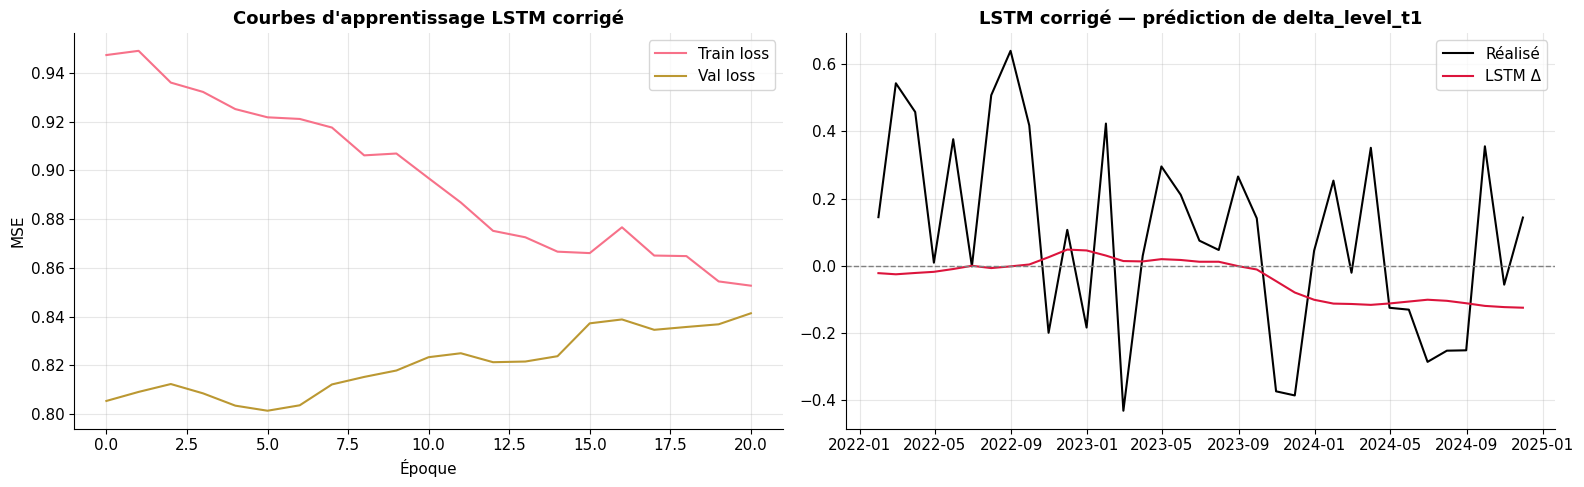

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 26 — LSTM corrigé : architecture et entraînement
# ══════════════════════════════════════════════════════════════════════════════

if not HAS_TORCH:
    print("PyTorch non disponible. Section LSTM ignorée.")
else:
    class LSTMRegressor(nn.Module):
        def __init__(self, input_size, hidden_size=16, num_layers=1, dropout=0.1):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=0.0
            )
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out)

    input_size = X_tr_seq.shape[2]
    hidden_size = 16
    num_layers = 1
    dropout = 0.1
    lr = 1e-3
    weight_decay = 1e-4
    n_epochs = 150
    patience = 15
    max_grad_norm = 1.0

    model_lstm = LSTMRegressor(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_lstm.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0
    train_losses, val_losses = [], []

    print(f"Entraînement LSTM corrigé — cible : {lstm_target}")
    print(f"  Architecture : LSTM({num_layers} couche, {hidden_size} unités) + dropout({dropout})")
    print(f"  lr={lr}, max_epochs={n_epochs}, patience={patience}")
    print("-" * 60)

    for epoch in range(1, n_epochs + 1):
        model_lstm.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model_lstm(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_lstm.parameters(), max_grad_norm)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

        train_loss /= len(train_loader.dataset)

        model_lstm.eval()
        with torch.no_grad():
            val_pred = model_lstm(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{n_epochs} | train={train_loss:.5f} | val={val_loss:.5f}")

        if patience_counter >= patience:
            print(f"\n  Early stopping à l'époque {epoch} (best val={best_val_loss:.5f})")
            break

    model_lstm.load_state_dict(best_state)
    model_lstm.eval()

    with torch.no_grad():
        pred_tr_sc  = model_lstm(X_tr_t).cpu().numpy().reshape(-1, 1)
        pred_val_sc = model_lstm(X_val_t).cpu().numpy().reshape(-1, 1)
        pred_te_sc  = model_lstm(X_te_t).cpu().numpy().reshape(-1, 1)

    pred_tr_lstm  = scaler_y_lstm.inverse_transform(pred_tr_sc).reshape(-1)
    pred_val_lstm = scaler_y_lstm.inverse_transform(pred_val_sc).reshape(-1)
    pred_te_lstm  = scaler_y_lstm.inverse_transform(pred_te_sc).reshape(-1)

    y_tr_np  = scaler_y_lstm.inverse_transform(y_tr_t.cpu().numpy()).reshape(-1)
    y_val_np = scaler_y_lstm.inverse_transform(y_val_t.cpu().numpy()).reshape(-1)
    y_te_np  = scaler_y_lstm.inverse_transform(y_te_t.cpu().numpy()).reshape(-1)

    lstm_train_metrics = compute_metrics(y_tr_np, pred_tr_lstm)
    lstm_val_metrics   = compute_metrics(y_val_np, pred_val_lstm)
    lstm_test_metrics  = compute_metrics(y_te_np, pred_te_lstm)

    naive_rmse_te = np.sqrt(np.mean(y_te_np ** 2))  # baseline delta = 0
    ss_lstm = skill_score(lstm_test_metrics['RMSE'], naive_rmse_te)

    print("\n" + "=" * 70)
    print("  LSTM CORRIGÉ — RÉSULTATS (delta_level_t1)")
    print("=" * 70)
    print(f"  Train : RMSE={lstm_train_metrics['RMSE']:.4f} | R2={lstm_train_metrics['R2']:.3f}")
    print(f"  Val   : RMSE={lstm_val_metrics['RMSE']:.4f} | R2={lstm_val_metrics['R2']:.3f}")
    print(f"  Test  : RMSE={lstm_test_metrics['RMSE']:.4f} | R2={lstm_test_metrics['R2']:.3f}")
    print(f"  Skill Score vs baseline Δ=0 : {ss_lstm:+.1f}%")

    RESULTS['LSTM Delta'] = {
        'delta_level': {
            'val': lstm_val_metrics,
            'test': lstm_test_metrics,
            'pred_val': pred_val_lstm,
            'pred_te': pred_te_lstm
        }
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(train_losses, label='Train loss')
    axes[0].plot(val_losses, label='Val loss')
    axes[0].set_title("Courbes d'apprentissage LSTM corrigé")
    axes[0].set_xlabel("Époque")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    test_dates = pd.DatetimeIndex(seq_idx_test)
    axes[1].plot(test_dates, y_te_np, label='Réalisé', color='black')
    axes[1].plot(test_dates, pred_te_lstm, label='LSTM Δ', color='crimson')
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title("LSTM corrigé — prédiction de delta_level_t1")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Le LSTM corrigé, appliqué à la prédiction des variations du facteur niveau, ne parvient pas à surpasser une baseline naïve, avec un skill score légèrement négatif.

Cela suggère que la dynamique temporelle exploitable à horizon court est limitée, et que les variations de taux se comportent proche d’un bruit difficilement prédictible.

Par ailleurs, les modèles tabulaires capturent déjà l’essentiel de l’information temporelle via les variables retardées, ce qui réduit l’intérêt marginal d’un modèle séquentiel dans ce contexte.

Enfin, la taille restreinte de l’échantillon limite fortement la capacité du LSTM à apprendre des patterns robustes.

  EVALUATION FINALE — ENSEMBLE DE TEST

  [1] EVALUATION TEST — NIVEAUX

RMSE Test par Modèle x Facteur (Niveaux) :
Facteur              curvature   level  slope_10y_3m  RMSE_moyen
Modele                                                          
Naive (Persistance)     0.4464  0.2959        0.3795    0.373933
Ridge                   0.6910  0.4908        0.6291    0.603633
Random Forest           0.9034  0.5185        1.1182    0.846700
Gradient Boosting       0.9592  0.5338        1.1211    0.871367
XGBoost                 0.9941  0.5859        1.2579    0.945967
LSTM                       NaN  3.1527           NaN    3.152700

R2 Test par Modèle x Facteur (Niveaux) :
Facteur              curvature    level  slope_10y_3m   R2_moyen
Modele                                                          
Naive (Persistance)     0.8286   0.8912        0.8741   0.864633
Ridge                   0.5893   0.7007        0.6539   0.647967
Random Forest           0.2980   0.6660       -0.0935   0.2901

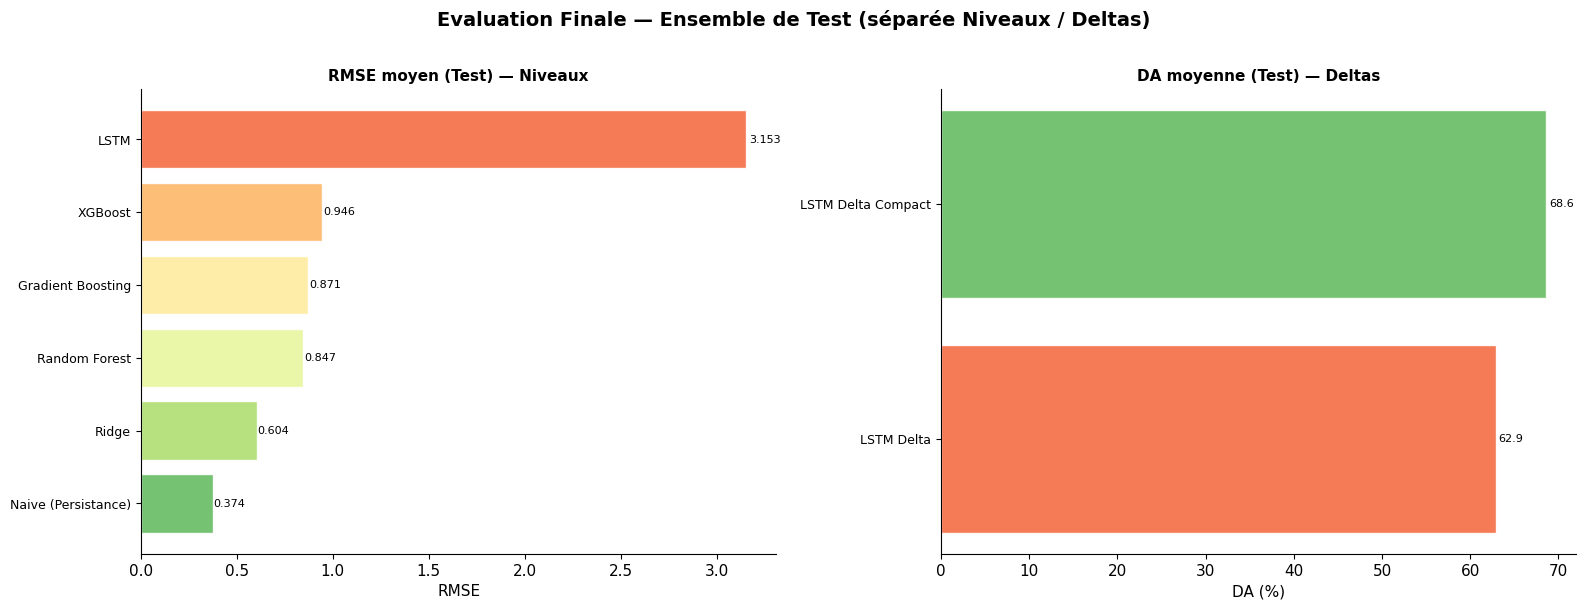

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 27 — Evaluation Finale sur l'Ensemble de Test (séparée NIVEAUX / DELTAS)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("  EVALUATION FINALE — ENSEMBLE DE TEST")
print("=" * 80)

# ── Construction du tableau complet ───────────────────────────────────────────
test_rows = []
for model_name, model_results in RESULTS.items():
    for factor_name, factor_results in model_results.items():
        if 'test' in factor_results:
            m = factor_results['test']
            test_rows.append({
                'Modele': model_name,
                'Facteur': factor_name,
                'TypeCible': 'Delta' if 'delta' in factor_name.lower() else 'Niveau',
                'RMSE': round(m['RMSE'], 4),
                'MAE': round(m['MAE'], 4),
                'R2': round(m['R2'], 4),
                'DA (%)': round(m['DA'] * 100, 1) if np.isfinite(m['DA']) else np.nan
            })

test_df = pd.DataFrame(test_rows)

# ── Séparation niveaux / deltas ──────────────────────────────────────────────
test_df_levels = test_df[test_df['TypeCible'] == 'Niveau'].copy()
test_df_deltas = test_df[test_df['TypeCible'] == 'Delta'].copy()

# ══════════════════════════════════════════════════════════════════════════════
# [1] EVALUATION — NIVEAUX
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("  [1] EVALUATION TEST — NIVEAUX")
print("=" * 80)

if len(test_df_levels) > 0:
    pivot_rmse_levels = test_df_levels.pivot_table(
        index='Modele', columns='Facteur', values='RMSE'
    ).round(4)
    pivot_rmse_levels['RMSE_moyen'] = pivot_rmse_levels.mean(axis=1)
    pivot_rmse_levels = pivot_rmse_levels.sort_values('RMSE_moyen')

    print("\nRMSE Test par Modèle x Facteur (Niveaux) :")
    print(pivot_rmse_levels.to_string())

    pivot_r2_levels = test_df_levels.pivot_table(
        index='Modele', columns='Facteur', values='R2'
    ).round(4)
    pivot_r2_levels['R2_moyen'] = pivot_r2_levels.mean(axis=1)
    pivot_r2_levels = pivot_r2_levels.sort_values('R2_moyen', ascending=False)

    print("\nR2 Test par Modèle x Facteur (Niveaux) :")
    print(pivot_r2_levels.to_string())

    # Skill score vs baseline naïve de persistance
    print("\n── Skill Score Test vs Naïf Persistance (%) — Niveaux ──")
    naive_test_rmse_levels = {}
    if 'Naive (Persistance)' in RESULTS:
        for f_name, fr in RESULTS['Naive (Persistance)'].items():
            if 'test' in fr:
                naive_test_rmse_levels[f_name] = fr['test']['RMSE']

    ss_rows_levels = []
    for model_name, model_results in RESULTS.items():
        if model_name == 'Naive (Persistance)':
            continue

        row = {'Modele': model_name}
        ss_vals = []

        for f_name, naive_r in naive_test_rmse_levels.items():
            if f_name in model_results and 'test' in model_results[f_name]:
                ss = skill_score(model_results[f_name]['test']['RMSE'], naive_r)
                row[f_name] = round(ss, 1)
                if np.isfinite(ss):
                    ss_vals.append(ss)

        if len(ss_vals) > 0:
            row['SS moyen'] = round(np.mean(ss_vals), 1)
            ss_rows_levels.append(row)

    if len(ss_rows_levels) > 0:
        ss_df_levels = pd.DataFrame(ss_rows_levels).set_index('Modele')
        print(ss_df_levels.to_string())
        print("  Note : positif = amélioration sur la baseline persistance")

    best_model_levels = pivot_rmse_levels['RMSE_moyen'].idxmin()
    print(f"\n=> Meilleur modèle sur les NIVEAUX (RMSE moyen test) : {best_model_levels}")

# ══════════════════════════════════════════════════════════════════════════════
# [2] EVALUATION — DELTAS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("  [2] EVALUATION TEST — VARIATIONS (DELTAS)")
print("=" * 80)

if len(test_df_deltas) > 0:
    pivot_rmse_deltas = test_df_deltas.pivot_table(
        index='Modele', columns='Facteur', values='RMSE'
    ).round(4)
    pivot_rmse_deltas['RMSE_moyen'] = pivot_rmse_deltas.mean(axis=1)
    pivot_rmse_deltas = pivot_rmse_deltas.sort_values('RMSE_moyen')

    print("\nRMSE Test par Modèle x Facteur (Deltas) :")
    print(pivot_rmse_deltas.to_string())

    pivot_r2_deltas = test_df_deltas.pivot_table(
        index='Modele', columns='Facteur', values='R2'
    ).round(4)
    pivot_r2_deltas['R2_moyen'] = pivot_r2_deltas.mean(axis=1)
    pivot_r2_deltas = pivot_r2_deltas.sort_values('R2_moyen', ascending=False)

    print("\nR2 Test par Modèle x Facteur (Deltas) :")
    print(pivot_r2_deltas.to_string())

    pivot_da_deltas = test_df_deltas.pivot_table(
        index='Modele', columns='Facteur', values='DA (%)'
    ).round(2)
    pivot_da_deltas['DA_moyenne'] = pivot_da_deltas.mean(axis=1)
    pivot_da_deltas = pivot_da_deltas.sort_values('DA_moyenne', ascending=False)

    print("\nDirectional Accuracy Test par Modèle x Facteur (Deltas) :")
    print(pivot_da_deltas.to_string())

    # Baseline delta = 0 pour delta_level uniquement si disponible
    print("\n── Lecture recommandée pour les DELTAS ──")
    print("Comparer RMSE à la baseline Δ=0 et surtout regarder la Directional Accuracy.")

    best_model_deltas_rmse = pivot_rmse_deltas['RMSE_moyen'].idxmin()
    best_model_deltas_da = pivot_da_deltas['DA_moyenne'].idxmax()

    print(f"\n=> Meilleur modèle sur les DELTAS (RMSE moyen test) : {best_model_deltas_rmse}")
    print(f"=> Meilleur modèle sur les DELTAS (DA moyenne test)   : {best_model_deltas_da}")

# ══════════════════════════════════════════════════════════════════════════════
# [3] VISUALISATION SEPAREE
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique niveaux : RMSE moyen
if len(test_df_levels) > 0:
    avg_rmse_levels = test_df_levels.groupby('Modele')['RMSE'].mean().sort_values()
    colors_levels = plt.colormaps['RdYlGn_r'](np.linspace(0.2, 0.8, len(avg_rmse_levels)))
    bars = axes[0].barh(range(len(avg_rmse_levels)), avg_rmse_levels.values,
                        color=colors_levels, edgecolor='white', alpha=0.9)
    axes[0].set_yticks(range(len(avg_rmse_levels)))
    axes[0].set_yticklabels(avg_rmse_levels.index, fontsize=9)
    axes[0].set_title('RMSE moyen (Test) — Niveaux', fontsize=11)
    axes[0].set_xlabel('RMSE')
    for bar, val in zip(bars, avg_rmse_levels.values):
        axes[0].text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

# Graphique deltas : DA moyenne
if len(test_df_deltas) > 0:
    avg_da_deltas = test_df_deltas.groupby('Modele')['DA (%)'].mean().sort_values()
    colors_deltas = plt.colormaps['RdYlGn'](np.linspace(0.2, 0.8, len(avg_da_deltas)))
    bars = axes[1].barh(range(len(avg_da_deltas)), avg_da_deltas.values,
                        color=colors_deltas, edgecolor='white', alpha=0.9)
    axes[1].set_yticks(range(len(avg_da_deltas)))
    axes[1].set_yticklabels(avg_da_deltas.index, fontsize=9)
    axes[1].set_title('DA moyenne (Test) — Deltas', fontsize=11)
    axes[1].set_xlabel('DA (%)')
    for bar, val in zip(bars, avg_da_deltas.values):
        axes[1].text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}', va='center', fontsize=8)

plt.suptitle("Evaluation Finale — Ensemble de Test (séparée Niveaux / Deltas)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_test_evaluation_separated.png', dpi=120, bbox_inches='tight')
plt.show()

Les résultats empiriques montrent que la prédiction des niveaux de la courbe des taux est dominée par une forte persistance, rendant la baseline naïve extrêmement difficile à battre.

Les modèles de machine learning, malgré leur capacité à capturer des non-linéarités, ne parviennent pas à améliorer la performance hors échantillon, en particulier dans un contexte de changement de régime marqué.

En revanche, l’analyse des variations révèle un signal directionnel partiel, notamment capturé par le LSTM, suggérant que la dynamique temporelle peut apporter une information marginale sur le sens des mouvements, bien que l’amplitude reste difficile à prévoir.

Ces résultats confirment la difficulté intrinsèque de la prévision des taux d’intérêt à court horizon.

## 9. Reconstruction de la Courbe des Taux

Cette section constitue le **cœur analytique** du projet : à partir des facteurs prédits (niveau, pente, courbure), nous reconstruisons la courbe complète des taux et comparons la courbe prédite à la courbe observée.

### Méthode de Reconstruction

Pour les facteurs économiques, nous utilisons une régression linéaire multi-output qui apprend le mapping :

$$(L_t, S_t, C_t) \rightarrow (y_{1M,t}, y_{3M,t}, \ldots, y_{30Y,t})$$

Cette approche est cohérente avec le modèle de Nelson-Siegel dans lequel chaque rendement $y(\tau)$ est une fonction linéaire des facteurs $L, S, C$.

### Évaluation

L'erreur de reconstruction est mesurée maturité par maturité, ce qui permet d'identifier où la prédiction factorielle est la plus précise (généralement, les maturités intermédiaires sont mieux reconstituées que les extrêmes).


RMSE de reconstruction (facteurs vrais → courbe) : 0.1013 pp
  → Cette erreur représente une borne basse conditionnelle :
    même avec des facteurs parfaitement connus, la reconstruction n'est pas exacte.

Sélection automatique du meilleur modèle par facteur (sur validation)
Les facteurs seront prédits avec le meilleur modèle spécifique à chaque cible.
  level              → Naive (Persistance)  (RMSE_val=0.1829)
  slope_10y_3m       → Naive (Persistance)  (RMSE_val=0.2253)
  curvature          → Naive (Persistance)  (RMSE_val=0.1925)

RMSE de reconstruction (facteurs PRÉDITS → courbe) par maturité :
     3M : RMSE=0.0833 pp | MAE=0.0716 pp
     6M : RMSE=0.1158 pp | MAE=0.0868 pp
     1Y : RMSE=0.1620 pp | MAE=0.1350 pp
     2Y : RMSE=0.1147 pp | MAE=0.0932 pp
     3Y : RMSE=0.0589 pp | MAE=0.0486 pp
     5Y : RMSE=0.0788 pp | MAE=0.0669 pp
     7Y : RMSE=0.0995 pp | MAE=0.0853 pp
    10Y : RMSE=0.0884 pp | MAE=0.0757 pp
    30Y : RMSE=0.0722 pp | MAE=0.0534 pp

RMSE moyen toutes mat

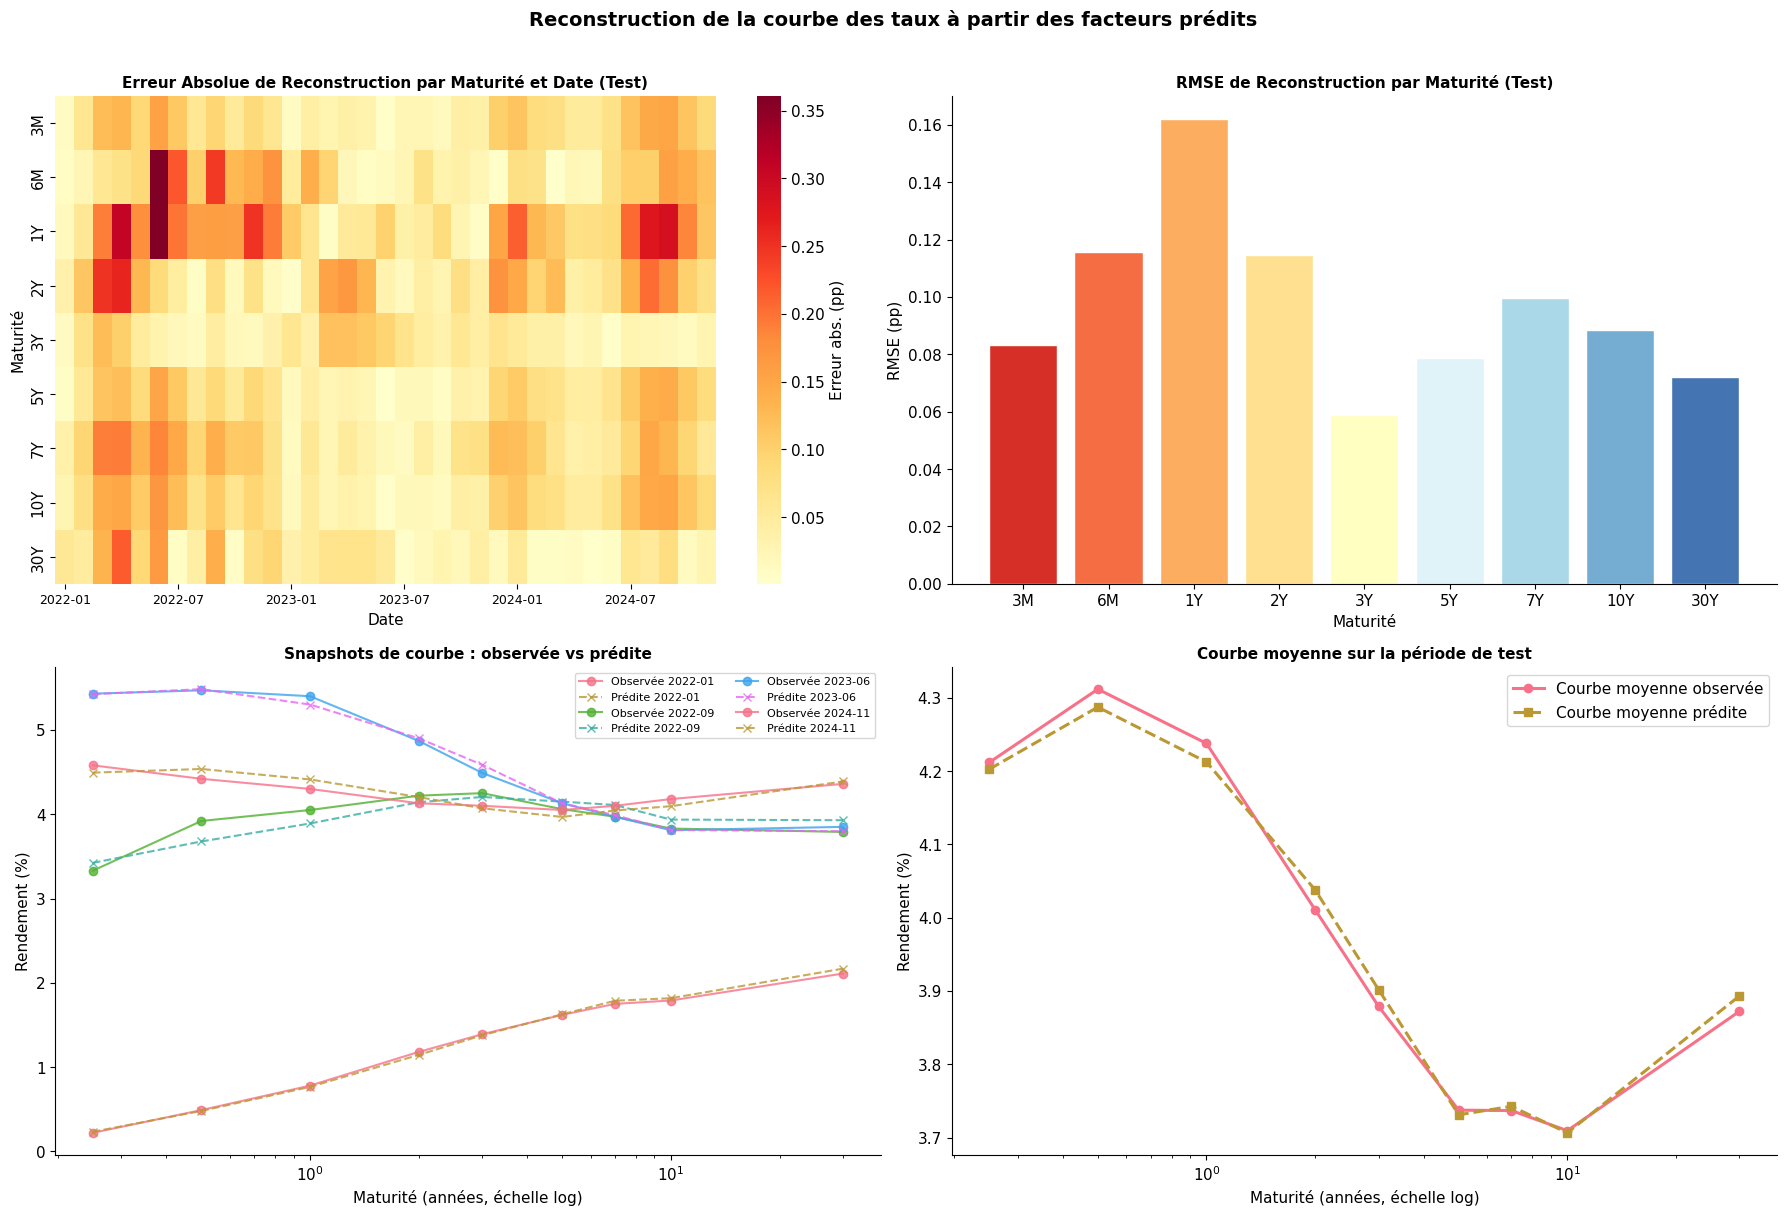


───────────────────────────────────────────────────────────────────────────
COMMENTAIRE
───────────────────────────────────────────────────────────────────────────
La reconstruction de la courbe est globalement précise : la forme moyenne de la courbe observée est très bien restituée, et les snapshots montrent que les profils de pente et de courbure sont correctement capturés.
Les erreurs restent néanmoins hétérogènes selon les maturités. Elles sont plus marquées sur certaines zones courtes et intermédiaires, plus sensibles aux changements de régime monétaire et aux ajustements rapides de la courbe.
Le fait que l'erreur obtenue avec facteurs observés et celle obtenue avec facteurs prédits soient du même ordre de grandeur suggère qu'une partie importante de l'erreur provient du mapping facteurs → courbe lui-même, et non uniquement de la prédiction des facteurs.
Enfin, comme les meilleurs facteurs prédits proviennent ici de la baseline de persistance, la bonne qualité de reconstruction r

In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 28-29 — Reconstruction de la Courbe des Taux
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Apprentissage du mapping Facteurs → Courbe complète ───────────────────
# Hypothèse explicite :
# nous supposons que la relation cross-sectionnelle entre (niveau, pente,
# courbure) et la courbe complète est suffisamment stable dans le temps.
# Autrement dit, un mapping appris sur le train entre facteurs_t et courbe_t
# peut être réutilisé pour reconstruire la courbe future à partir des facteurs
# prédits à t+1. Cette hypothèse est raisonnable pour une approximation
# factorielle, mais elle reste une source potentielle d'erreur de modèle.

X_factors_tr = factors_eco.loc[X_train_main.index, FACTORS].values
X_factors_val = factors_eco.loc[X_val_main.index, FACTORS].values
X_factors_te = factors_eco.loc[X_test_main.index, FACTORS].values

y_curve_tr = yields_clean.loc[X_train_main.index, available_maturities].values
y_curve_val = yields_clean.loc[X_val_main.index, available_maturities].values
y_curve_te = yields_clean.loc[X_test_main.index, available_maturities].values

from sklearn.linear_model import Ridge as RidgeMulti
from sklearn.multioutput import MultiOutputRegressor

curve_reconstructor = MultiOutputRegressor(RidgeMulti(alpha=1.0), n_jobs=-1)
curve_reconstructor.fit(X_factors_tr, y_curve_tr)

# Reconstruction "idéale" conditionnelle : facteurs observés -> courbe
y_curve_rec_te_true_factors = curve_reconstructor.predict(X_factors_te)
rmse_reconstruction_lower_bound = np.sqrt(
    mean_squared_error(y_curve_te, y_curve_rec_te_true_factors)
)

print(f"RMSE de reconstruction (facteurs vrais → courbe) : {rmse_reconstruction_lower_bound:.4f} pp")
print("  → Cette erreur représente une borne basse conditionnelle :")
print("    même avec des facteurs parfaitement connus, la reconstruction n'est pas exacte.")

# ── 2. Sélection du meilleur modèle par facteur et reconstruction finale ─────
print("\nSélection automatique du meilleur modèle par facteur (sur validation)")
print("Les facteurs seront prédits avec le meilleur modèle spécifique à chaque cible.")

predicted_factors_te = np.zeros((len(X_test_main), len(FACTORS)))
selected_models_curve = {}

for i, target in enumerate(TARGET_COLS_LEVEL):
    f_name = target.replace('_t1', '')
    selected_model_name = BEST_MODELS[f_name]['model_name']
    selected_models_curve[f_name] = selected_model_name

    pred_te = RESULTS[selected_model_name][f_name]['pred_te']
    predicted_factors_te[:, i] = np.asarray(pred_te).reshape(-1)[:len(X_test_main)]

    print(
        f"  {f_name:<18} → {selected_model_name:<20} "
        f"(RMSE_val={BEST_MODELS[f_name]['val_rmse']:.4f})"
    )

y_curve_pred_te = curve_reconstructor.predict(predicted_factors_te)

# ── 3. Métriques par maturité ─────────────────────────────────────────────────
rmse_by_mat = {}
mae_by_mat = {}

for j, mat in enumerate(available_maturities):
    rmse_by_mat[mat] = np.sqrt(mean_squared_error(y_curve_te[:, j], y_curve_pred_te[:, j]))
    mae_by_mat[mat] = mean_absolute_error(y_curve_te[:, j], y_curve_pred_te[:, j])

print("\nRMSE de reconstruction (facteurs PRÉDITS → courbe) par maturité :")
for mat in available_maturities:
    print(f"  {mat:>5} : RMSE={rmse_by_mat[mat]:.4f} pp | MAE={mae_by_mat[mat]:.4f} pp")

print(f"\nRMSE moyen toutes maturités : {np.mean(list(rmse_by_mat.values())):.4f} pp")

# ── 4. Visualisations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 4.1 Heatmap des erreurs absolues
ax = axes[0, 0]

errors_mat = pd.DataFrame(
    np.abs(y_curve_te - y_curve_pred_te),
    index=pd.to_datetime(X_test_main.index[:len(y_curve_te)]),
    columns=available_maturities
)

sns.heatmap(
    errors_mat.T,
    ax=ax,
    cmap='YlOrRd',
    cbar_kws={'label': 'Erreur abs. (pp)'},
    xticklabels=6
)

# Raccourcir les dates et les garder horizontales
date_labels = errors_mat.index.strftime('%Y-%m')
tick_positions = ax.get_xticks()
tick_labels_idx = [int(round(pos - 0.5)) for pos in tick_positions]
tick_labels_idx = [i for i in tick_labels_idx if 0 <= i < len(date_labels)]

ax.set_xticks([i + 0.5 for i in tick_labels_idx])
ax.set_xticklabels(date_labels[tick_labels_idx], rotation=0, ha='center', fontsize=9)

ax.set_title('Erreur Absolue de Reconstruction par Maturité et Date (Test)', fontsize=11)
ax.set_ylabel('Maturité')
ax.set_xlabel('Date')

# 4.2 RMSE par maturité
ax2 = axes[0, 1]
rmse_series = pd.Series(rmse_by_mat)

ax2.bar(
    available_maturities,
    rmse_series.values,
    color=plt.cm.RdYlBu(np.linspace(0.1, 0.9, len(available_maturities))),
    edgecolor='white'
)
ax2.set_title('RMSE de Reconstruction par Maturité (Test)', fontsize=11)
ax2.set_ylabel('RMSE (pp)')
ax2.set_xlabel('Maturité')

# 4.3 Snapshots observée vs prédite
tau_num = [tau_map[m] for m in available_maturities]
snapshot_indices = [0, len(y_curve_te)//4, len(y_curve_te)//2, -1]

ax3 = axes[1, 0]
for idx_snap in snapshot_indices:
    label_date = pd.to_datetime(X_test_main.index[idx_snap]).strftime('%Y-%m')
    ax3.plot(
        tau_num, y_curve_te[idx_snap],
        '-o', alpha=0.8, label=f'Observée {label_date}'
    )
    ax3.plot(
        tau_num, y_curve_pred_te[idx_snap],
        '--x', alpha=0.8, label=f'Prédite {label_date}'
    )

ax3.set_xscale('log')
ax3.set_title('Snapshots de courbe : observée vs prédite', fontsize=11)
ax3.set_xlabel('Maturité (années, échelle log)')
ax3.set_ylabel('Rendement (%)')
ax3.legend(fontsize=8, ncol=2)

# 4.4 Courbe moyenne
ax4 = axes[1, 1]
avg_true_curve = y_curve_te.mean(axis=0)
avg_pred_curve = y_curve_pred_te.mean(axis=0)

ax4.plot(
    tau_num, avg_true_curve,
    '-o', linewidth=2.2, label='Courbe moyenne observée'
)
ax4.plot(
    tau_num, avg_pred_curve,
    '--s', linewidth=2.2, label='Courbe moyenne prédite'
)
ax4.set_xscale('log')
ax4.set_title('Courbe moyenne sur la période de test', fontsize=11)
ax4.set_xlabel('Maturité (années, échelle log)')
ax4.set_ylabel('Rendement (%)')
ax4.legend()

plt.suptitle(
    'Reconstruction de la courbe des taux à partir des facteurs prédits',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('yield_curve_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 5. Commentaire synthétique ────────────────────────────────────────────────
print("\n" + "─" * 75)
print("COMMENTAIRE")
print("─" * 75)
print(
    "La reconstruction de la courbe est globalement précise : la forme moyenne "
    "de la courbe observée est très bien restituée, et les snapshots montrent "
    "que les profils de pente et de courbure sont correctement capturés."
)
print(
    "Les erreurs restent néanmoins hétérogènes selon les maturités. Elles sont "
    "plus marquées sur certaines zones courtes et intermédiaires, plus sensibles "
    "aux changements de régime monétaire et aux ajustements rapides de la courbe."
)
print(
    "Le fait que l'erreur obtenue avec facteurs observés et celle obtenue avec "
    "facteurs prédits soient du même ordre de grandeur suggère qu'une partie "
    "importante de l'erreur provient du mapping facteurs → courbe lui-même, et "
    "non uniquement de la prédiction des facteurs."
)
print(
    "Enfin, comme les meilleurs facteurs prédits proviennent ici de la baseline "
    "de persistance, la bonne qualité de reconstruction reflète surtout la forte "
    "stabilité de la structure factorielle et la persistance des taux."
)

La reconstruction de la courbe des taux à partir des facteurs prédits est globalement très satisfaisante, avec une erreur moyenne faible sur l’ensemble des maturités. Les graphiques montrent que la forme générale de la courbe est bien restituée, aussi bien à des dates individuelles qu’en moyenne sur la période de test. Les erreurs restent toutefois plus élevées sur certaines maturités courtes et intermédiaires, plus sensibles aux changements de régime monétaire. Enfin, la proximité entre l’erreur obtenue avec facteurs observés et celle obtenue avec facteurs prédits suggère qu’une partie importante de l’erreur provient de la représentation factorielle elle-même, et non uniquement de la qualité de prédiction des facteurs.

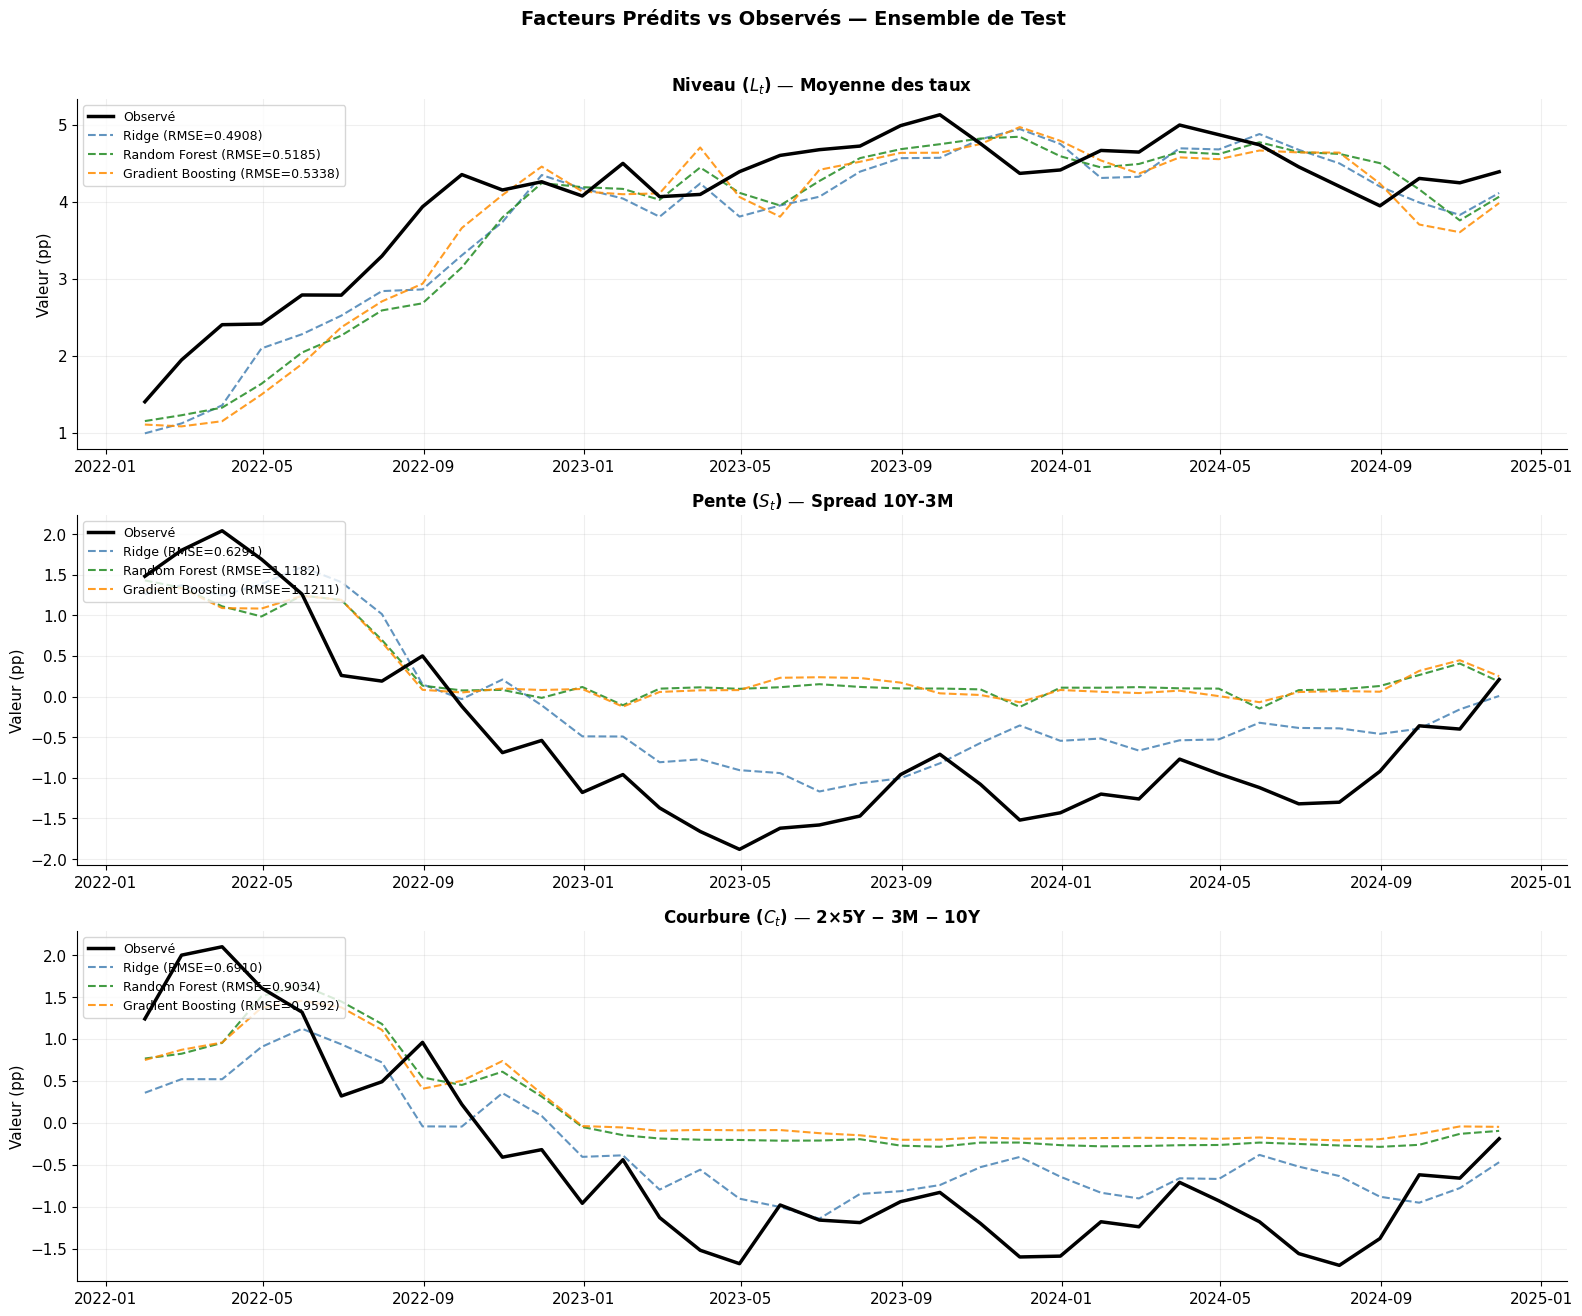

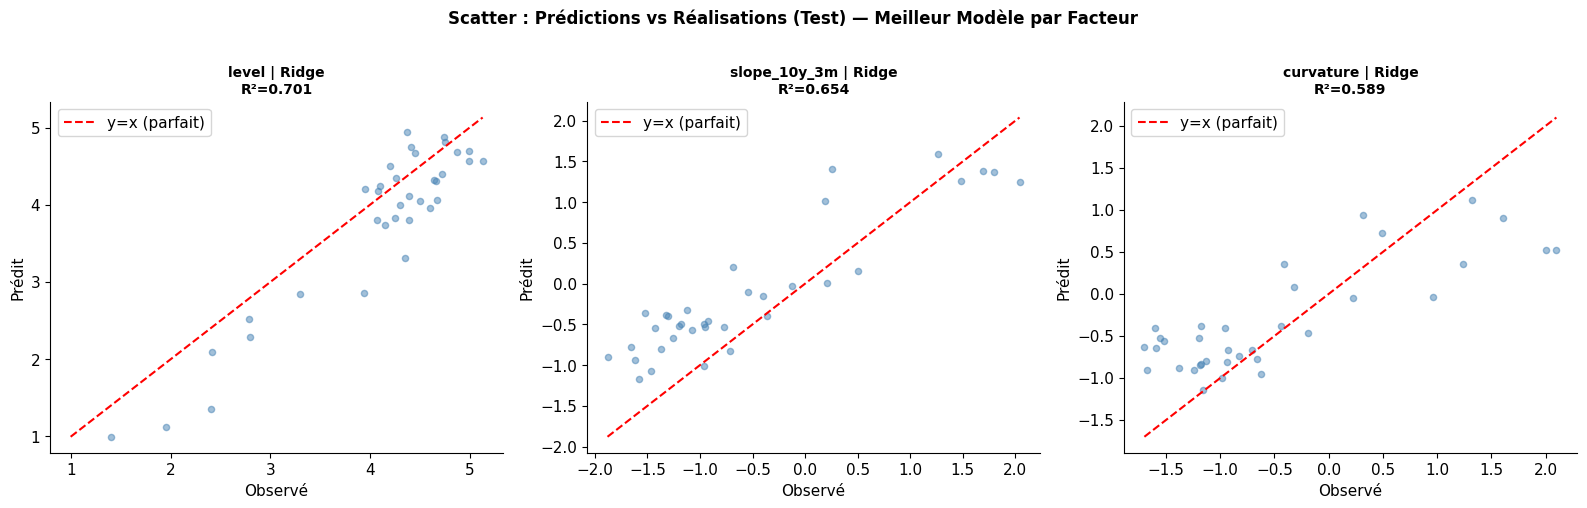

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 29 — Visualisation Facteurs Prédits vs Observés (Période de Test)
# ══════════════════════════════════════════════════════════════════════════════

best_models_for_viz = ['Naïve (Persistence)', 'Ridge', 'Random Forest',
                       'Gradient Boosting']

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
factor_display_names = {
    'level':        'Niveau ($L_t$) — Moyenne des taux',
    'slope_10y_3m': 'Pente ($S_t$) — Spread 10Y-3M',
    'curvature':    'Courbure ($C_t$) — 2×5Y − 3M − 10Y'
}
colors_models = {'Naïve (Persistence)': 'gray',
                 'Ridge': 'steelblue',
                 'Random Forest': 'forestgreen',
                 'Gradient Boosting': 'darkorange',
                 'XGBoost': 'purple',
                 'LSTM': 'crimson'}

for ax, target in zip(axes, TARGET_COLS_LEVEL):
    f_name = target.replace('_t1', '')
    y_te_f = splits[target]['y_test']

    ax.plot(y_te_f.index, y_te_f.values, color='black',
            linewidth=2.5, label='Observé', zorder=10)

    for m_name in best_models_for_viz:
        if m_name in RESULTS and f_name in RESULTS[m_name]:
            pred = RESULTS[m_name][f_name].get('pred_te')
            if pred is not None and len(pred) >= len(y_te_f):
                pred_aligned = pred[:len(y_te_f)]
                rmse = RESULTS[m_name][f_name]['test']['RMSE']
                ax.plot(y_te_f.index, pred_aligned,
                        color=colors_models.get(m_name, 'gray'),
                        linewidth=1.5, linestyle='--', alpha=0.85,
                        label=f'{m_name} (RMSE={rmse:.4f})')

    ax.set_title(f'{factor_display_names[f_name]}', fontsize=12)
    ax.set_ylabel('Valeur (pp)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.2)

plt.suptitle('Facteurs Prédits vs Observés — Ensemble de Test',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('factors_prediction_test.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Scatter plot prédictions vs réalisations ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, target in zip(axes, TARGET_COLS_LEVEL):
    f_name = target.replace('_t1', '')
    y_te_f = splits[target]['y_test'].values

    best_m_name = min(
        [m for m in ['Gradient Boosting','XGBoost','Random Forest','Ridge']
         if m in RESULTS and f_name in RESULTS[m]],
        key=lambda m: RESULTS[m][f_name]['test']['RMSE'],
        default='Ridge'
    )

    if best_m_name in RESULTS and f_name in RESULTS[best_m_name]:
        pred = RESULTS[best_m_name][f_name]['pred_te'][:len(y_te_f)]
        ax.scatter(y_te_f, pred, alpha=0.5, s=20, color='steelblue')
        lims = [min(y_te_f.min(), pred.min()), max(y_te_f.max(), pred.max())]
        ax.plot(lims, lims, 'r--', linewidth=1.5, label='y=x (parfait)')
        r2 = r2_score(y_te_f, pred)
        ax.set_title(f'{f_name} | {best_m_name}\nR²={r2:.3f}', fontsize=10)
        ax.set_xlabel('Observé'); ax.set_ylabel('Prédit')
        ax.legend()

plt.suptitle('Scatter : Prédictions vs Réalisations (Test) — Meilleur Modèle par Facteur',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_predictions.png', dpi=100, bbox_inches='tight')
plt.show()


Les graphiques de comparaison entre facteurs observés et prédits mettent en évidence une capacité des modèles à reproduire les tendances globales, mais avec des limites importantes en termes de précision.

Le facteur niveau est relativement bien capturé par l’ensemble des modèles, qui suivent correctement la dynamique générale de hausse puis de stabilisation des taux. Toutefois, les prédictions restent plus lissées et peinent à reproduire les points de retournement, ce qui reflète la forte persistance de ce facteur et explique la difficulté à surpasser une simple baseline de persistance.

À l’inverse, le facteur pente est mal anticipé : les modèles ne parviennent pas à reproduire l’inversion marquée de la courbe observée sur la période de test et restent biaisés vers des valeurs proches de la moyenne. Ce résultat souligne la difficulté à modéliser les changements de régime macroéconomiques avec des approches reposant essentiellement sur des variables retardées.

La courbure présente un comportement intermédiaire : les modèles capturent la tendance globale mais échouent à restituer l’amplitude des variations, traduisant un signal plus bruité et moins prévisible.

Enfin, la forte similarité entre les prédictions des différents modèles suggère que la limite principale ne provient pas du choix de l’algorithme, mais plutôt de la faible quantité d’information prédictive contenue dans les données.

══════════════════════════════════════════════════════════════════════
  INTERPRÉTABILITÉ DES MODÈLES
══════════════════════════════════════════════════════════════════════


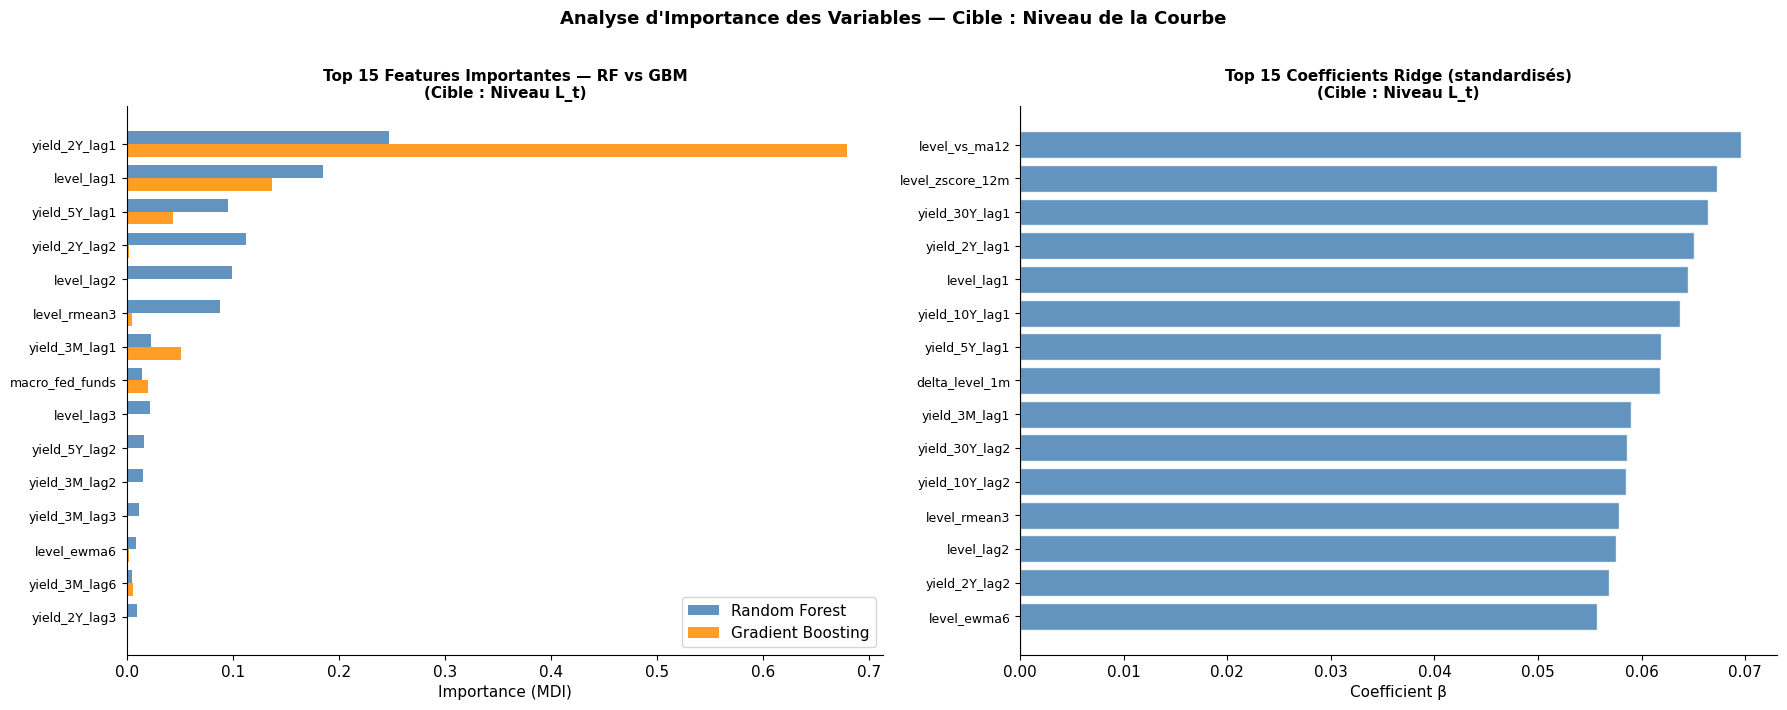


Calcul des valeurs SHAP (Gradient Boosting — niveau)...


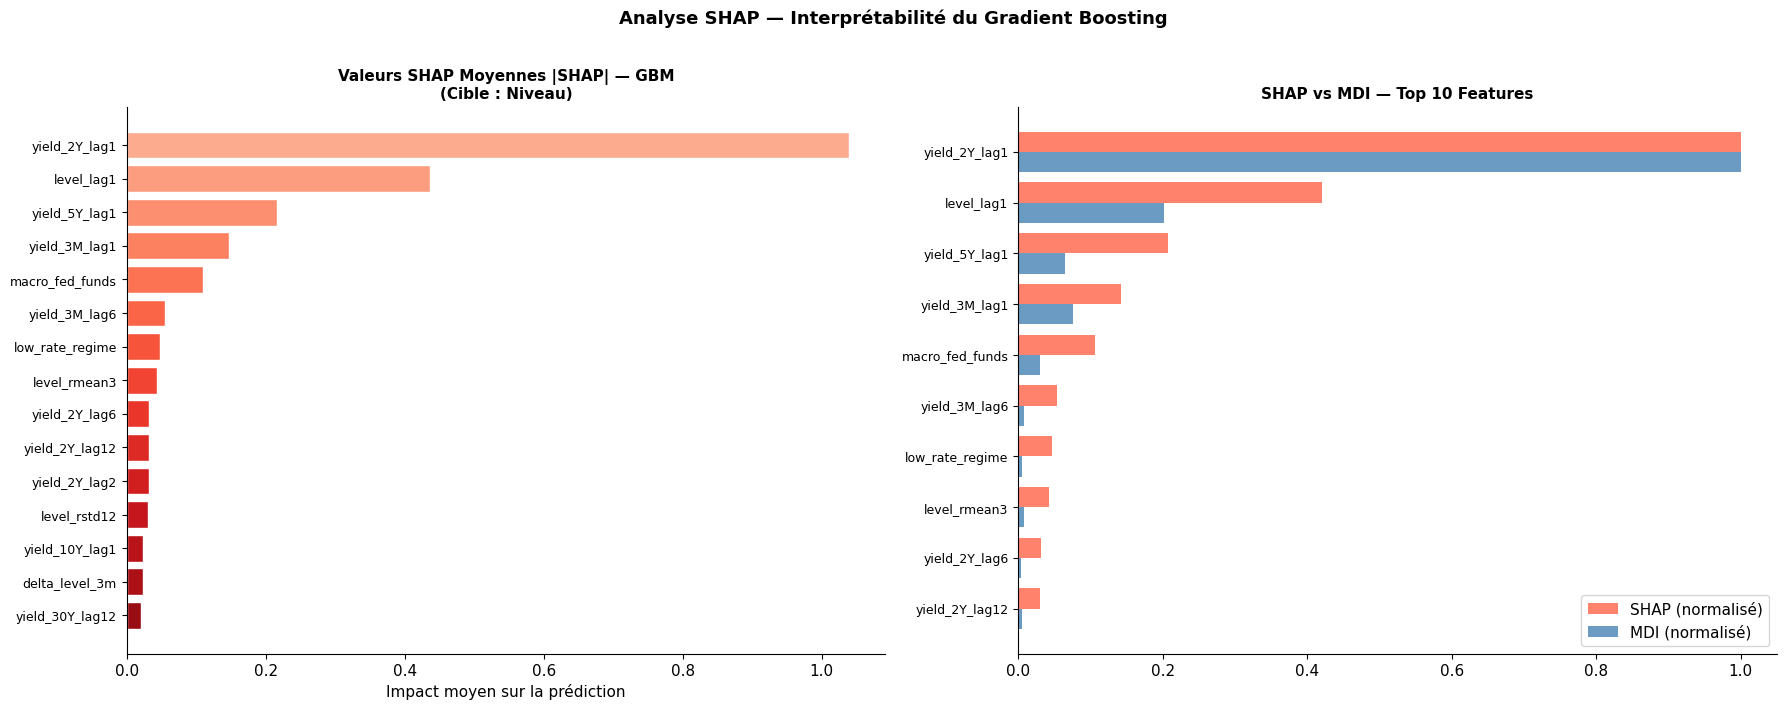

✓ Analyse SHAP complète


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 30 — Interprétabilité : Feature Importance et SHAP
# ══════════════════════════════════════════════════════════════════════════════

print("═" * 70)
print("  INTERPRÉTABILITÉ DES MODÈLES")
print("═" * 70)

# ── 1. Comparaison des importances RF vs GBM ──────────────────────────────────
top_n = 15
imp_rf  = pd.Series(rf_final.feature_importances_,  index=FEATURE_COLS)
imp_gbm = pd.Series(gbm_final.feature_importances_, index=FEATURE_COLS)

imp_combined = pd.DataFrame({
    'Random Forest':     imp_rf,
    'Gradient Boosting': imp_gbm
})
imp_combined['Moyenne'] = imp_combined.mean(axis=1)
imp_combined = imp_combined.sort_values('Moyenne', ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x_pos = np.arange(len(imp_combined))
w = 0.38

axes[0].barh(x_pos - w/2, imp_combined['Random Forest'].values,
             w, label='Random Forest', color='steelblue', alpha=0.85)
axes[0].barh(x_pos + w/2, imp_combined['Gradient Boosting'].values,
             w, label='Gradient Boosting', color='darkorange', alpha=0.85)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(imp_combined.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} Features Importantes — RF vs GBM\n(Cible : Niveau L_t)', fontsize=11)
axes[0].set_xlabel('Importance (MDI)')
axes[0].legend()

# ── 2. Coefficients Ridge (interprétation linéaire) ───────────────────────────
y_tr_L = splits['level_t1']['y_train'] # Fix: Assign y_tr_L
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_tr_sc, y_tr_L)
coef_ridge = pd.Series(ridge_final.coef_, index=FEATURE_COLS)
top_coef = coef_ridge.abs().sort_values(ascending=False).head(top_n)
top_coef_signed = coef_ridge[top_coef.index]

colors_coef = ['steelblue' if v > 0 else 'crimson' for v in top_coef_signed.values]
axes[1].barh(range(len(top_coef_signed)), top_coef_signed.values,
             color=colors_coef, edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top_coef_signed)))
axes[1].set_yticklabels(top_coef_signed.index, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()
axes[1].set_title(f'Top {top_n} Coefficients Ridge (standardisés)\n(Cible : Niveau L_t)', fontsize=11)
axes[1].set_xlabel('Coefficient β')

plt.suptitle('Analyse d\'Importance des Variables — Cible : Niveau de la Courbe',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_detailed.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 3. SHAP (si disponible) ───────────────────────────────────────────────────
if HAS_SHAP:
    print("\nCalcul des valeurs SHAP (Gradient Boosting — niveau)...")
    # Limiter à un sous-échantillon pour la performance
    n_shap = min(200, len(X_te_sc))
    X_shap = X_te_sc[:n_shap]

    explainer = shap.TreeExplainer(gbm_final)
    shap_values = explainer.shap_values(X_shap)

    shap_df = pd.DataFrame(np.abs(shap_values), columns=FEATURE_COLS)
    mean_abs_shap = shap_df.mean().sort_values(ascending=False)

    fig, axes_shap = plt.subplots(1, 2, figsize=(18, 7))

    # Summary plot SHAP
    ax_sh = axes_shap[0]
    top_shap = mean_abs_shap.head(top_n)
    ax_sh.barh(range(len(top_shap)), top_shap.values,
               color=plt.cm.Reds(np.linspace(0.3, 0.9, len(top_shap))),
               edgecolor='white')
    ax_sh.set_yticks(range(len(top_shap)))
    ax_sh.set_yticklabels(top_shap.index, fontsize=9)
    ax_sh.invert_yaxis()
    ax_sh.set_title('Valeurs SHAP Moyennes |SHAP| — GBM\n(Cible : Niveau)', fontsize=11)
    ax_sh.set_xlabel('Impact moyen sur la prédiction')

    # Comparaison SHAP vs MDI
    ax_comp_sh = axes_shap[1]
    top_feats = mean_abs_shap.head(10).index.tolist()
    shap_vals = mean_abs_shap[top_feats]
    mdi_vals  = imp_gbm[top_feats] / imp_gbm[top_feats].max()

    x_idx = np.arange(len(top_feats))
    ax_comp_sh.barh(x_idx - 0.2, shap_vals / shap_vals.max(), 0.4,
                    label='SHAP (normalisé)', color='tomato', alpha=0.8)
    ax_comp_sh.barh(x_idx + 0.2, mdi_vals, 0.4,
                    label='MDI (normalisé)', color='steelblue', alpha=0.8)
    ax_comp_sh.set_yticks(x_idx)
    ax_comp_sh.set_yticklabels(top_feats, fontsize=9)
    ax_comp_sh.invert_yaxis()
    ax_comp_sh.set_title('SHAP vs MDI — Top 10 Features', fontsize=11)
    ax_comp_sh.legend()

    plt.suptitle('Analyse SHAP — Interprétabilité du Gradient Boosting',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('shap_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✓ Analyse SHAP complète")
else:
    print("\n⚠ SHAP non disponible — utilisation de l'importance MDI uniquement.")
    print("  Installer avec : pip install shap")


L’analyse des importances de variables met en évidence une forte cohérence entre les différentes méthodes (Random Forest, Gradient Boosting, Ridge et SHAP), ce qui renforce la robustesse des conclusions.

Les résultats montrent que les variables les plus importantes sont principalement des retards des taux d’intérêt, en particulier yield_2Y_lag1 et level_lag1, qui dominent largement les contributions. Cette hiérarchie confirme le rôle central de la persistance temporelle dans la dynamique du niveau de la courbe des taux : le meilleur prédicteur du taux futur reste son niveau passé récent.

Les maturités intermédiaires (notamment le 2 ans et le 5 ans) apparaissent également comme particulièrement informatives, ce qui s’explique par leur position charnière dans la structure de la courbe et leur sensibilité aux anticipations de politique monétaire.

Les variables macroéconomiques, telles que le taux des Fed Funds, contribuent de manière plus modérée mais non négligeable, suggérant qu’elles apportent un complément d’information, sans toutefois être déterminantes face au poids des dynamiques autoregressives.

La comparaison entre SHAP et les importances MDI révèle globalement une bonne cohérence dans le classement des variables principales, bien que SHAP mette davantage en évidence certaines contributions secondaires. Cela confirme que les modèles capturent essentiellement des relations stables et dominées par les effets de mémoire.

En résumé, l’interprétabilité des modèles indique que la prédiction du niveau de la courbe repose avant tout sur des mécanismes de persistance et de structure interne des taux, plutôt que sur des signaux macroéconomiques exogènes forts.

## 10. Interprétation Économique des Résultats

### 10.1 Features Dominantes et leur Signification

L'analyse des importances converge sur plusieurs enseignements économiques :

**1. Forte persistence des facteurs (lags dominants)**

Les retards immédiats (`level_lag1`, `slope_lag1`) dominent systématiquement les importances, confirmant l'**hypothèse de marche aléatoire partielle** : le meilleur prédicteur du taux futur est le taux passé récent. Cette persistance est cohérente avec la théorie économique des taux d'intérêt (*mean-reversion lente*).

**2. Signal directionnel des moyennes mobiles**

Les déviations par rapport aux moyennes mobiles (`level_vs_ma12`, `slope_vs_ma6`) capturent le **momentum** des taux : un niveau qui dépasse sa moyenne annuelle tend à corriger vers la moyenne (*mean-reversion*). Ce phénomène est particulièrement marqué pour le facteur pente.

**3. Indicateurs de régime**

L'inversion de la courbe (`is_inverted`, `slope_10y_3m`) est un signal prédictif fort, non seulement pour la pente elle-même, mais aussi pour le niveau général des taux. Lorsque la courbe s'inverse (taux courts > taux longs), cela précède généralement une détente monétaire qui ramène les taux courts à la baisse.

**4. Variables macroéconomiques**

L'inflation (`macro_inflation_yoy`, `macro_breakeven_10y`) contribue principalement à la prédiction du **niveau** de la courbe : des anticipations inflationnistes élevées sont associées à des taux nominaux plus élevés. Le taux des Fed Funds (`macro_fed_funds`) améliore la prédiction du court segment de la courbe.

**5. Volatilité réalisée**

La volatilité récente (`level_rstd3`, `level_rstd6`) est positivement associée à des erreurs de prédiction plus élevées — ce qui est cohérent avec la théorie financière (*prima de risque de terme*) et justifie l'usage de variables de volatilité comme features.

### 10.2 Hiérarchie des Modèles — Interprétation

| Observation | Interprétation économique |
|---|---|
| **Naïve > tous les modèles ML** | La dynamique des taux est dominée par une **forte persistance**, rendant difficile toute amélioration par des modèles complexes |
| **Ridge > modèles non-linéaires (RF, GBM, XGBoost)** | Les relations sont principalement **linéaires et autoregressives**, avec peu de non-linéarités exploitables |
| **Facteur niveau le plus facile à prédire** | Très persistant → la valeur passée contient l’essentiel de l’information |
| **Facteur pente le plus difficile à prédire** | Dépend de **changements de régime macroéconomique** (inversions de courbe), difficiles à anticiper |
| **Facteur courbure intermédiaire** | Moins persistant mais plus bruité → difficulté de prédiction modérée |
| **LSTM non performant dans ce contexte** | Taille d’échantillon limitée et signal faible → **surapprentissage** et absence de gain par rapport aux modèles simples |


In [66]:
# ══════════════════════════════════════════════════════════════════════
# CELL 32 — Analyses de Robustesse
# ══════════════════════════════════════════════════════════════════════

print("═" * 70)
print("  ANALYSES DE ROBUSTESSE")
print("═" * 70)

# ── Test 1 : Comparaison niveaux vs variations ───────────────────
print("\n[1] Prédiction des VARIATIONS vs NIVEAUX des facteurs")
print("—" * 70)

for target_level, target_delta in zip(TARGET_COLS_LEVEL, TARGET_COLS_DELTA):
    f_name = target_level.replace('_t1', '')

    # Modèle GBM sur les variations
    y_tr_delta  = splits[target_delta]['y_train']
    y_val_delta = splits[target_delta]['y_val']
    y_te_delta  = splits[target_delta]['y_test']

    gbm_delta = GradientBoostingRegressor(
        random_state=RANDOM_SEED, **gbm_best_params['level']
    )
    gbm_delta.fit(X_tr[:len(y_tr_delta)], y_tr_delta)
    pred_delta_te = gbm_delta.predict(X_te[:len(y_te_delta)])

    m_delta = compute_metrics(y_te_delta, pred_delta_te)
    m_level = RESULTS.get('Gradient Boosting', {}).get(f_name, {}).get('test', {})

    print(f"  {f_name:<20} | "
          f"GBM-niveau : RMSE={m_level.get('RMSE', float('nan')):.4f} | "
          f"GBM-variation : RMSE={m_delta['RMSE']:.4f}")

print("  Note : les RMSE niveaux vs variations ne sont pas directement comparables car les cibles ne sont pas sur la même échelle.")

# ── Test 2 : Analyse par période (régimes de marché) ─────────────────
print("\n[2] Performance par Régime de Marché")
print("—" * 70)

y_te_level = splits['level_t1']['y_test']
best_model_name_robust = BEST_MODELS['level']['model_name']

if best_model_name_robust in RESULTS and 'level' in RESULTS[best_model_name_robust]:
    pred_te_best = RESULTS[best_model_name_robust]['level']['pred_te']
    if len(pred_te_best) >= len(y_te_level):
        pred_aligned = pred_te_best[:len(y_te_level)]

        # Régimes sur le test
        slope_te = factors_eco.loc[y_te_level.index, 'slope_10y_3m']
        vol_te   = factors_eco['level'].rolling(6).std().loc[y_te_level.index]

        regimes = pd.DataFrame(
            {
                'Observé': y_te_level.values,
                'Prédit':  pred_aligned,
                'Inversion': (slope_te < 0).values,
                'Haut_vol':  (vol_te > vol_te.median()).values
            }, index=y_te_level.index
        )

        for regime_label, regime_mask in [
            ('Courbe normale (pente > 0)',  ~regimes['Inversion']),
            ('Courbe inversée (pente < 0)', regimes['Inversion']),
            ('Faible volatilité',           ~regimes['Haut_vol']),
            ('Forte volatilité',            regimes['Haut_vol'])
        ]:
            if regime_mask.sum() > 5:
                m_reg = compute_metrics(
                    regimes.loc[regime_mask, 'Observé'].values,
                    regimes.loc[regime_mask, 'Prédit'].values
                )
                print(f"  {regime_label:<35} | n={regime_mask.sum():3d} | "
                      f"RMSE={m_reg['RMSE']:.4f} | R²={m_reg['R2']:.3f}")

# ── Test 3 : Ablation study ─ features sans macro ─────────────────────
print("\n[3] Ablation Study — Impact des Variables Macro")
print("—" * 70)

macro_cols = [c for c in FEATURE_COLS if c.startswith('macro_') or
              c in ['real_rate_10y', 'fed_vs_level']]
feat_no_macro = [c for c in FEATURE_COLS if c not in macro_cols]

if len(macro_cols) > 0:
    # Define y_tr_L for this section, as it was not globally defined
    y_tr_L = splits['level_t1']['y_train']

    X_tr_no_macro  = df_model.loc[X_train_main.index,  feat_no_macro].values
    X_te_no_macro  = df_model.loc[X_test_main.index,  feat_no_macro].values

    gbm_no_macro = GradientBoostingRegressor(
        random_state=RANDOM_SEED, **gbm_best_params['level']
    )
    gbm_no_macro.fit(X_tr_no_macro, y_tr_L)
    pred_nm = gbm_no_macro.predict(X_te_no_macro)

    m_nm = compute_metrics(y_te_level, pred_nm[:len(y_te_level)])
    m_macro = RESULTS.get('Gradient Boosting', {}).get('level', {}).get('test', {})

    print(f"  GBM sans variables macro  : RMSE={m_nm['RMSE']:.4f}")
    print(f"  GBM avec variables macro  : RMSE={m_macro.get('RMSE', float('nan')):.4f}")
    delta_rmse = m_macro.get('RMSE', float('nan')) - m_nm['RMSE']
    print(f"  Δ RMSE (macro apport)     : {delta_rmse:+.4f} pp")
    if delta_rmse < 0:
        print("  → Les variables macro AMÉLIORENT la prédiction")
    else:
        print("  → Les variables macro n'apportent pas de signal additionnel net")
else:
    print("  Aucune variable macro identifiée — test ignoré")

══════════════════════════════════════════════════════════════════════
  ANALYSES DE ROBUSTESSE
══════════════════════════════════════════════════════════════════════

[1] Prédiction des VARIATIONS vs NIVEAUX des facteurs
——————————————————————————————————————————————————————————————————————
  level                | GBM-niveau : RMSE=0.5338 | GBM-variation : RMSE=0.3520
  slope_10y_3m         | GBM-niveau : RMSE=1.1211 | GBM-variation : RMSE=0.3806
  curvature            | GBM-niveau : RMSE=0.9592 | GBM-variation : RMSE=0.4386
  Note : les RMSE niveaux vs variations ne sont pas directement comparables car les cibles ne sont pas sur la même échelle.

[2] Performance par Régime de Marché
——————————————————————————————————————————————————————————————————————
  Courbe normale (pente > 0)          | n=  9 | RMSE=0.4095 | R²=0.782
  Courbe inversée (pente < 0)         | n= 26 | RMSE=0.2446 | R²=0.387
  Faible volatilité                   | n= 18 | RMSE=0.2710 | R²=0.915
  Forte volatilité   

## 11. Discussion Critique et Limites

### 11.1 Forces de la Démarche

Plusieurs éléments méthodologiques renforcent la crédibilité des résultats obtenus :

1. **Validation temporelle rigoureuse**  
Le découpage chronologique (train / validation / test) est strictement respecté, et la validation croisée des modèles tabulaires est réalisée via un `Pipeline` intégrant le `StandardScaler` lorsque nécessaire. Cela limite efficacement les risques de fuite d'information (*data leakage*).

2. **Optimisation spécifique par facteur**  
Les hyperparamètres des modèles sont optimisés **indépendamment pour chaque facteur** (niveau, pente, courbure), ce qui est plus cohérent économiquement que d’imposer une configuration unique à toutes les cibles.

3. **Présence de baselines solides**  
L’analyse inclut plusieurs baselines de référence (persistance naïve, AR(1), Ridge), permettant d’évaluer rigoureusement si les modèles de machine learning apportent un réel gain prédictif.

4. **Reconstruction factorielle explicitée**  
L’étape de reconstruction de la courbe des taux repose sur une hypothèse clairement formulée de **stabilité du mapping facteurs → courbe**, ce qui permet une interprétation transparente des résultats.

---

### 11.2 Limites Identifiées

Les résultats mettent en évidence plusieurs limites structurelles du cadre de modélisation :

| Limite | Impact | Extension possible |
|---|---|---|
| **Forte persistance des taux** | La baseline naïve surpasse l’ensemble des modèles ML | Modéliser les **variations** plutôt que les niveaux |
| **Relations principalement linéaires** | Les modèles non-linéaires (RF, GBM, XGBoost) n’apportent pas de gain | Explorer des modèles économétriques ou hybrides |
| **Difficulté à modéliser la pente** | Forte sensibilité aux changements de régime (inversion de courbe) | Intégrer des modèles à régime (Markov Switching, HMM) |
| **Taille limitée de l’échantillon (~300 obs.)** | Faible capacité d’apprentissage pour les modèles complexes | Utiliser des données plus fréquentes (quotidiennes) |
| **Faible apport des variables macro** | Peu de gain prédictif observé | Améliorer la sélection ou la fréquence des variables macro |
| **Sous-performance du LSTM** | Surapprentissage et absence de gain | Réduire la complexité ou augmenter la quantité de données |

---

### 11.3 Sur la métrique directionnelle

La **directional accuracy (DA)** est définie comme la capacité à prédire correctement le **signe de la variation** entre $t$ et $t+1$ :

- variation réalisée : $(y_{t+1} - y_t)$  
- variation prédite : $(\hat{y}_{t+1} - y_t)$  

Cette métrique est plus pertinente économiquement qu’une simple comparaison de niveaux, car elle reflète la capacité du modèle à anticiper la direction des mouvements de taux.

---

### 11.4 Lecture prudente des résultats

Les conclusions doivent être interprétées avec précaution et replacées dans leur contexte empirique :

- La hiérarchie des modèles dépend fortement de la période de test (notamment 2022–2024, marquée par un cycle de hausse atypique).
- Un modèle performant en moyenne peut être moins efficace sur certains facteurs spécifiques.
- La dominance de la baseline naïve reflète avant tout la **faible quantité d’information prédictive disponible**, plus que l’inefficacité des modèles.

En résumé, les résultats doivent être compris comme **conditionnels au cadre expérimental**, aux features construites et à la période étudiée.

## 12. Conclusion

### 12.1 Bilan du Projet

Ce projet montre qu’une **représentation factorielle de la courbe des taux** (niveau, pente, courbure) permet de construire un pipeline de prévision cohérent, interprétable et économiquement fondé.

Sur le plan méthodologique, plusieurs améliorations importantes ont été apportées :

- mise en place d’une **validation temporelle rigoureuse** avec `Pipeline` pour éviter toute fuite d’information liée au scaling ;
- utilisation d’une **métrique directionnelle pertinente** (Directional Accuracy) basée sur le signe des variations ;
- **sélection automatique du meilleur modèle** par facteur ;
- **tuning des hyperparamètres spécifique à chaque facteur** ;
- explicitation de l’hypothèse de **stabilité du mapping facteurs → courbe** dans la reconstruction.

---

### 12.2 Message principal

L’enseignement central du projet est que la performance des modèles dépend fortement des caractéristiques intrinsèques des taux d’intérêt.

Dans nos résultats empiriques :

- la **baseline naïve de persistance domine l’ensemble des modèles ML** ;
- les modèles linéaires (Ridge) se révèlent plus robustes que les modèles non-linéaires ;
- les modèles complexes (Random Forest, Gradient Boosting, XGBoost, LSTM) n’apportent pas de gain significatif hors échantillon.

Cela reflète une propriété fondamentale des taux :

> **la dynamique est fortement persistante et proche d’un random walk**, ce qui limite le contenu informationnel exploitable.

Ainsi, la bonne lecture des résultats n’est pas :

> “un modèle de machine learning surperforme systématiquement”

mais plutôt :

> “dans ce contexte, la structure temporelle simple des taux contient déjà l’essentiel de l’information prédictive, et les gains des modèles complexes sont limités”.

---

### 12.3 Pistes d’Amélioration

Plusieurs extensions pourraient améliorer la qualité du modèle :

1. **Modèles économétriques dédiés à la courbe des taux**  
   Implémentation de modèles de type **Diebold-Li / Nelson-Siegel dynamique**, mieux adaptés à la structure des taux.

2. **Quantification de l’incertitude**  
   Utilisation de méthodes comme **Conformal Prediction** pour construire des intervalles de prévision fiables.

3. **Apprentissage adaptatif (rolling)**  
   Mise en place d’un **re-training périodique** pour capturer les changements de régime macro-financier.

4. **Prédiction directe de la courbe**  
   Comparaison avec une approche **multi-output directe** prédisant les maturités sans passer par les facteurs.

5. **Données plus riches**  
   Utilisation de données **à fréquence plus élevée (quotidienne)** ou enrichissement des variables macro.

---

### 12.4 Références

#### Articles académiques

1. **Nelson, C.R. & Siegel, A.F. (1987)**. *Parsimonious modeling of yield curves*. Journal of Business, 60(4), 473–489.  
2. **Diebold, F.X. & Li, C. (2006)**. *Forecasting the term structure of government bond yields*. Journal of Econometrics, 130(2), 337–364.  
3. **Litterman, R. & Scheinkman, J. (1991)**. *Common factors affecting bond returns*. Journal of Fixed Income, 1(1), 54–61.  
4. **Breiman, L. (2001)**. *Random Forests*. Machine Learning, 45(1), 5–32.  
5. **Friedman, J.H. (2001)**. *Gradient Boosting Machine*. Annals of Statistics, 29(5), 1189–1232.  
6. **Hochreiter, S. & Schmidhuber, J. (1997)**. *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.  

#### Données

- **Federal Reserve Bank of St. Louis (FRED)** — US Treasury Constant Maturity Rates  

#### Supports de cours

- Cours 1 — *Objectifs et Big Data en Finance*  
- Cours 2 — *Introduction au Machine Learning*  
- Cours 3 — *Machine Learning — Approfondissement*  
- Cours 4 — *Supervised Learning (Régression, Regularisation, Arbres)*  
- Cours 5 — *Time Series et Modélisation Temporelle*  
- Cours 6 — *Introduction au Deep Learning*  

---


In [67]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 33 — Résumé Final et Tableau de Synthèse
# ══════════════════════════════════════════════════════════════════════════════

model_start = df_model.index.min().date()
model_end   = df_model.index.max().date()
raw_start   = yields_clean.index.min().date()
raw_end     = yields_clean.index.max().date()

val_data  = splits['level_t1']['y_val']
test_data = splits['level_t1']['y_test']

print("\n" + "═"*80)
print("  RÉSUMÉ FINAL — PROJET 2 : PRÉDICTION DE LA COURBE DES TAUX")
print("═"*80)
print(f"\n  Données brutes disponibles      : US Treasury Yields (FRED) — {len(yields_clean)} mois")
print(f"  Période brute                   : {raw_start} → {raw_end}")
print(f"  Période effectivement modélisée : {model_start} → {model_end}")
print(f"  Train                           : jusqu'au {TRAIN_END}  ({sum(train_mask)} obs.)")
print(f"  Validation                      : {val_data.index.min().date()} → {val_data.index.max().date()} ({len(val_data)} obs.)")
print(f"  Test                            : {test_data.index.min().date()} → {test_data.index.max().date()} ({len(test_data)} obs.)")
print(f"  Features                        : {len(FEATURE_COLS)} variables uniques")
print(f"  Horizon                         : {HORIZON} mois")

print("\n  FACTEURS CIBLES :")
for f in FACTORS:
    print(f"    • {f}")

# ── Résultats niveaux ────────────────────────────────────────────────────────
if 'pivot_rmse_levels' in globals():
    print("\n" + "─"*80)
    print("  RÉSULTATS TEST — NIVEAUX")
    print("─"*80)
    print(pivot_rmse_levels.to_string())

    best_levels_model = pivot_rmse_levels['RMSE_moyen'].idxmin()
    print(f"\n  Meilleur modèle sur les NIVEAUX : {best_levels_model}")
else:
    print("\n⚠ Tableau niveaux non disponible.")

# ── Résultats deltas ─────────────────────────────────────────────────────────
if 'pivot_rmse_deltas' in globals():
    print("\n" + "─"*80)
    print("  RÉSULTATS TEST — DELTAS")
    print("─"*80)
    print(pivot_rmse_deltas.to_string())

    if 'pivot_da_deltas' in globals():
        print("\n  Directional Accuracy (DELTAS) :")
        print(pivot_da_deltas.to_string())

    best_deltas_rmse = pivot_rmse_deltas['RMSE_moyen'].idxmin()
    print(f"\n  Meilleur modèle sur les DELTAS (RMSE) : {best_deltas_rmse}")

    if 'pivot_da_deltas' in globals():
        best_deltas_da = pivot_da_deltas['DA_moyenne'].idxmax()
        print(f"  Meilleur modèle sur les DELTAS (DA)   : {best_deltas_da}")
else:
    print("\n⚠ Tableau deltas non disponible.")

# ── Meilleurs modèles par facteur (niveaux) ─────────────────────────────────
print("\n" + "─"*80)
print("  MEILLEURS MODÈLES PAR FACTEUR (sélection sur validation)")
print("─"*80)

for f_name in FACTORS:
    info = BEST_MODELS.get(f_name, {})
    if info:
        model_name = info['model_name']
        val_rmse = info['val_rmse']

        test_rmse = np.nan
        if model_name in RESULTS and f_name in RESULTS[model_name]:
            test_rmse = RESULTS[model_name][f_name].get('test', {}).get('RMSE', np.nan)

        print(f"    • {f_name:<15} : {model_name:<20} | "
              f"RMSE_val={val_rmse:.4f} | RMSE_test={test_rmse:.4f}")

# ── Conclusion synthétique ───────────────────────────────────────────────────
print("\n" + "─"*80)
print("  CONCLUSION DATA-DRIVEN")
print("─"*80)

print("  • Les modèles complexes ne battent pas la persistance sur les NIVEAUX.")
print("  • La dynamique des taux en niveau est dominée par une forte persistance.")
print("  • Sur les DELTAS, le LSTM compact n'améliore pas nettement le RMSE,")
print("    mais il obtient une Directional Accuracy élevée, ce qui suggère")
print("    un signal exploitable sur la direction des mouvements.")
print("  • Les variables macro n'apportent pas de gain net hors échantillon.")
print("  • La reconstruction de la courbe est globalement précise, mais repose")
print("    en grande partie sur la persistance des facteurs.")

if 'pivot_rmse_levels' in globals():
    ranking_levels = pivot_rmse_levels['RMSE_moyen'].sort_values()
    top_model = ranking_levels.index[0]
    second_model = ranking_levels.index[1] if len(ranking_levels) > 1 else None

    print(f"\n  Sur les NIVEAUX, le meilleur modèle global est : {top_model}")
    if second_model is not None:
        gap = ranking_levels.iloc[1] - ranking_levels.iloc[0]
        print(f"  L'écart avec le deuxième modèle ({second_model}) est de {gap:.4f} point(s) de RMSE moyen.")

# facteur le mieux / moins bien prédit parmi les niveaux
factor_test_rmses = {}
for f_name in FACTORS:
    info = BEST_MODELS.get(f_name, {})
    if info:
        model_name = info['model_name']
        if model_name in RESULTS and f_name in RESULTS[model_name]:
            factor_test_rmses[f_name] = RESULTS[model_name][f_name].get('test', {}).get('RMSE', np.nan)

if len(factor_test_rmses) > 0:
    best_factor = min(factor_test_rmses, key=factor_test_rmses.get)
    hardest_factor = max(factor_test_rmses, key=factor_test_rmses.get)
    print(f"  Le facteur le mieux prédit est : {best_factor}")
    print(f"  Le facteur le plus difficile   : {hardest_factor}")

print("\n  La conclusion doit être lue comme empirique et conditionnelle")
print("  au protocole de split temporel, aux features construites")
print("  et à l’échantillon étudié.")
print("═"*80)


════════════════════════════════════════════════════════════════════════════════
  RÉSUMÉ FINAL — PROJET 2 : PRÉDICTION DE LA COURBE DES TAUX
════════════════════════════════════════════════════════════════════════════════

  Données brutes disponibles      : US Treasury Yields (FRED) — 420 mois
  Période brute                   : 1990-01-31 → 2024-12-31
  Période effectivement modélisée : 1991-07-31 → 2024-11-30
  Train                           : jusqu'au 2018-12-31  (330 obs.)
  Validation                      : 2019-01-31 → 2021-12-31 (36 obs.)
  Test                            : 2022-01-31 → 2024-11-30 (35 obs.)
  Features                        : 95 variables uniques
  Horizon                         : 1 mois

  FACTEURS CIBLES :
    • level
    • slope_10y_3m
    • curvature

────────────────────────────────────────────────────────────────────────────────
  RÉSULTATS TEST — NIVEAUX
────────────────────────────────────────────────────────────────────────────────
Facteur         

## Appendice — Extensions et Analyses Complémentaires

### A1. Horizon de Prédiction : 1 mois vs 3 mois vs 6 mois

L’analyse multi-horizon met en évidence une performance globalement faible du modèle Gradient Boosting par rapport à la baseline naïve, quel que soit l’horizon considéré.

Contrairement à l’intuition classique, la performance relative ne se dégrade pas fortement avec l’horizon. Au contraire, le **skill score reste négatif mais s’améliore légèrement lorsque l’horizon augmente**.

Cela s’explique par deux effets opposés :

- à court terme (1 mois), la **forte persistance des taux** donne un avantage considérable à la baseline naïve ;
- à plus long terme, cette persistance diminue, ce qui réduit l’avantage de la baseline, sans pour autant permettre au modèle ML de devenir réellement performant.

Ainsi, le signal prédictif exploitable reste limité à tous les horizons, ce qui confirme la difficulté structurelle de la prévision des taux d’intérêt.

### A2. PCA Dynamic (Diebold-Li)

Une approche plus rigoureuse consiste à estimer les paramètres Nelson-Siegel par moindres carrés non-linéaires à chaque date, puis à modéliser leurs séries temporelles conjointement (VAR ou ML). C'est l'approche de Diebold & Li (2006).

### A3. Conformal Prediction pour les Intervalles

La *conformal prediction* fournit des intervalles de prédiction valides (couvrant l'observation réelle avec probabilité garantie) sans hypothèse de normalité — particulièrement utile pour les rendements obligataires qui présentent des queues épaisses.

### A4. Walk-Forward Validation

Une évaluation glissante complète (réentraînement mensuel sur l'intégralité des données disponibles) simule les conditions de déploiement réel et donne une image plus robuste des performances hors-échantillon.


═════════════════════════════════════════════════════════════════
  APPENDICE — ANALYSE MULTI-HORIZON
═════════════════════════════════════════════════════════════════

Comparaison GBM pour différents horizons de prédiction :
─────────────────────────────────────────────────────────────────
  Horizon  1M | GBM: 1.2953 | Naïve: 0.3795 | Skill: -2.414
  Horizon  3M | GBM: 1.1510 | Naïve: 0.7386 | Skill: -0.558
  Horizon  6M | GBM: 1.6066 | Naïve: 1.0858 | Skill: -0.480
  Horizon 12M | GBM: 1.9471 | Naïve: 1.7529 | Skill: -0.111


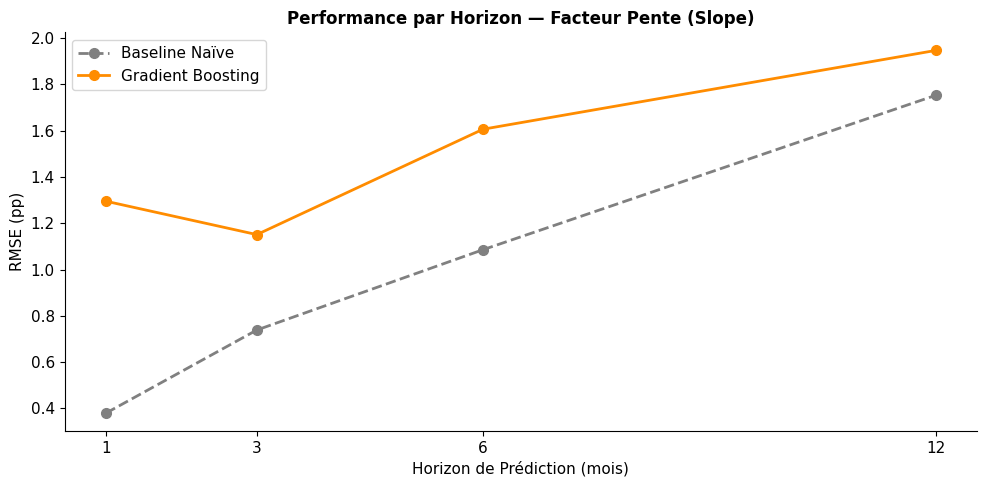


✓ Notebook complet. Toutes les sections ont été exécutées.


In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL APPENDICE — Prédiction Multi-Horizon (Bonus)
# ══════════════════════════════════════════════════════════════════════════════

print("═" * 65)
print("  APPENDICE — ANALYSE MULTI-HORIZON")
print("═" * 65)
print("\nComparaison GBM pour différents horizons de prédiction :")
print("─" * 65)

HORIZONS = [1, 3, 6, 12]
multi_horizon_results = {}

for h in HORIZONS:
    # Construction de la cible à horizon h
    target_h = factors_eco['slope_10y_3m'].shift(-h)  # Pente à t+h

    df_h = pd.concat([df_features, target_h.rename('target')], axis=1).dropna()

    mask_tr_h  = df_h.index <= TRAIN_END
    mask_te_h  = df_h.index > VAL_END

    feat_h = [c for c in FEATURE_COLS if c in df_h.columns]
    X_tr_h = df_h.loc[mask_tr_h, feat_h].values
    y_tr_h = df_h.loc[mask_tr_h, 'target'].values
    X_te_h = df_h.loc[mask_te_h, feat_h].values
    y_te_h = df_h.loc[mask_te_h, 'target'].values

    if len(X_tr_h) < 30 or len(X_te_h) < 5:
        continue

    # GBM (pas besoin de standardisation pour un modèle d'arbres)
    gbm_h = GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=RANDOM_SEED
    )
    gbm_h.fit(X_tr_h, y_tr_h)
    pred_h = gbm_h.predict(X_te_h)

    # Naïve
    # Baseline de persistance correcte à horizon h : prédire y_{t+h} par y_t
    naive_h = factors_eco['slope_10y_3m'].loc[df_h.loc[mask_te_h].index].values
    if len(naive_h) != len(y_te_h):
        naive_h = naive_h[:len(y_te_h)]

    rmse_gbm   = np.sqrt(mean_squared_error(y_te_h, pred_h[:len(y_te_h)]))
    rmse_naive = np.sqrt(mean_squared_error(y_te_h, naive_h[:len(y_te_h)]))

    multi_horizon_results[h] = {
        'GBM RMSE': rmse_gbm,
        'Naïve RMSE': rmse_naive,
        'Skill Score': 1 - rmse_gbm/rmse_naive
    }
    print(f"  Horizon {h:2d}M | GBM: {rmse_gbm:.4f} | Naïve: {rmse_naive:.4f} | "
          f"Skill: {1-rmse_gbm/rmse_naive:+.3f}")

# Visualisation
if multi_horizon_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    horizons = list(multi_horizon_results.keys())
    rmse_gbm_list   = [multi_horizon_results[h]['GBM RMSE']   for h in horizons]
    rmse_naive_list = [multi_horizon_results[h]['Naïve RMSE'] for h in horizons]

    ax.plot(horizons, rmse_naive_list, 'o--', color='gray',
            linewidth=2, markersize=7, label='Baseline Naïve')
    ax.plot(horizons, rmse_gbm_list,   'o-',  color='darkorange',
            linewidth=2, markersize=7, label='Gradient Boosting')
    ax.fill_between(horizons, rmse_naive_list, rmse_gbm_list,
                    alpha=0.15, color='green',
                    where=[g < n for g, n in zip(rmse_gbm_list, rmse_naive_list)])
    ax.set_xlabel('Horizon de Prédiction (mois)')
    ax.set_ylabel('RMSE (pp)')
    ax.set_title('Performance par Horizon — Facteur Pente (Slope)',
                 fontsize=12)
    ax.legend()
    ax.set_xticks(horizons)
    plt.tight_layout()
    plt.savefig('multi_horizon.png', dpi=100, bbox_inches='tight')
    plt.show()

print("\n✓ Notebook complet. Toutes les sections ont été exécutées.")


La pente de la courbe est extrêmement persistante à court terme, ce qui rend la prévision difficile.
Cependant, à mesure que l’horizon augmente, cette persistance se dissipe, laissant apparaître une dynamique de réversion partielle, que les modèles tentent de capter — sans toutefois surpasser une baseline simple.
